<div style='text-align: center'>
    <p style='font-size:50px; margin-bottom: 0px'>Statistics</p>
    <o style='font-size:20px;'>This notebook handles calculating stats for all variations and putting them into a table</p>
</div>

In [1]:
import cogsworth
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('../src')
import plotting, helpers, constants
from importlib import reload

%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [3]:
p = cogsworth.pop.load("/mnt/ceph/users/twagg/underworld/fiducial/fiducial_part0.h5")

cogsworth warning: file was saved with gala v1.11.1.dev61 but you are using v1.11.1.dev77


In [4]:
q = p[:20]
q.store_entire_orbits=True

cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].


In [5]:
q.perform_galactic_evolution()

Integrating orbits: 100%|██████████| 24/24 [00:00<00:00, 556.21it/s]


In [6]:
q.orbits

array([<Orbit cartesian, dim=3, shape=(463,)>,
       <Orbit cartesian, dim=3, shape=(770,)>,
       <Orbit cartesian, dim=3, shape=(583,)>,
       <Orbit cartesian, dim=3, shape=(6527,)>,
       <Orbit cartesian, dim=3, shape=(310,)>,
       <Orbit cartesian, dim=3, shape=(990,)>,
       <Orbit cartesian, dim=3, shape=(843,)>,
       <Orbit cartesian, dim=3, shape=(39,)>,
       <Orbit cartesian, dim=3, shape=(256,)>,
       <Orbit cartesian, dim=3, shape=(589,)>,
       <Orbit cartesian, dim=3, shape=(904,)>,
       <Orbit cartesian, dim=3, shape=(91,)>,
       <Orbit cartesian, dim=3, shape=(625,)>,
       <Orbit cartesian, dim=3, shape=(139,)>,
       <Orbit cartesian, dim=3, shape=(822,)>,
       <Orbit cartesian, dim=3, shape=(364,)>,
       <Orbit cartesian, dim=3, shape=(487,)>,
       <Orbit cartesian, dim=3, shape=(567,)>,
       <Orbit cartesian, dim=3, shape=(1417,)>,
       <Orbit cartesian, dim=3, shape=(4978,)>,
       <Orbit cartesian, dim=3, shape=(583,)>,
       <Orbi

In [7]:
import evolving_potential
evolving_mw_pot = evolving_potential.get_milky_way_potential(evolve_dm=True, evolve_disk=True)

In [8]:
q.galactic_potential = evolving_mw_pot

In [9]:
q.perform_galactic_evolution()

Integrating orbits: 100%|██████████| 24/24 [00:00<00:00, 565.35it/s]
cogsworth warning: 24 orbit(s) failed numerical integration, removing them. This can occur due to NaNs in stellar evolution or extreme orbits (e.g. passing directly through the galactic centre) that Gala cannot handle. Not saving information for these systems because `error_file_path` is set to `None`.


ValueError: You need to input a *nonnegative* number of binaries

In [120]:
reload(constants)
files = constants.SIMULATION_FILES
files = [f for f in files if "time-evolving" not in f]

main_labels = [
    r"$f_{\rm bin} = 1.0$",
    r"$f_{\rm bin} = 0.0$",
    "No BH kicks", "No fallback rescaling", "Hobbs+2005",
    "Fryer+2012 Rapid", r"Mandel\&Muller2020", "Maltsev+2025",
    r"$f_{\rm fb} = 0.0$", r"$f_{\rm fb} = 0.25$", r"$f_{\rm fb} = 0.75$", r"$f_{\rm fb} = 1.0$",
    r"$P({\rm pf}) = 0.0$", r"$P({\rm pf}) = 1.0$",
    # 'Time-evolving potential'
]
markers = ['o'] * len(main_labels)
initC_labels = [
    r"$\alpha_{\rm IMF} = -1.9$", r"$\alpha_{\rm IMF} = -2.7$",
    r"$\kappa = -1.0$", r"$\kappa = 1.0$",
    r"$q_{\rm min} = -1.0$",
    r"$\pi = 0.0$", r"$\pi = -1.0$",
    r"$P_{\rm orb, max} = 10^3\,{\rm days}$"
]
markers += ['^'] * len(initC_labels)
main_labels += initC_labels
mt_labels = [
    r"$\beta = 0.0$", r"$\beta = 0.5$", r"$\beta = 1.0$",
    r"$\alpha_{\rm CE} = 0.1$", r"$\alpha_{\rm CE} = 0.5$", r"$\alpha_{\rm CE} = 2.0$", r"$\alpha_{\rm CE} = 10.0$",
    r"$q_{\rm crit, B} = 0$", r"$q_{\rm crit, B} = \infty$",
]
markers += ['s'] * len(mt_labels)
labels = main_labels + mt_labels
mt_labels = [main_labels[0]] + mt_labels  # include the fiducial model in the MT section

In [ ]:
plot_labels = [
    "Fiducial",
    "Singles",
    "No BH kicks",
    "No fallback rescaling",
    "Hobbs+2005",
    "Fryer+2012 Rapid", r"Mandel & Muller 2020", "Maltsev+2025 (Default)",
    r"Maltsev+2025 ($f_{\rm fb} = 0.0$)", r"Maltsev+2025 ($f_{\rm fb} = 0.25$)", r"Maltsev+2025 ($f_{\rm fb} = 0.75$)", r"Maltsev+2025 ($f_{\rm fb} = 1.0$)",
    r"Maltsev+2025 ($P({\rm pf}) = 0.0$)", r"Maltsev+2025 ($P({\rm pf}) = 1.0$)",
    # 'Time-evolving potential',
    # initC
    r"$\alpha_{\rm IMF} = -1.9$", r"$\alpha_{\rm IMF} = -2.7$",
    r"$\kappa = -1.0$", r"$\kappa = 1.0$",
    r"$q_{\rm min} = -1.0$",
    r"$\pi = 0.0$", r"$\pi = -1.0$",
    r"$P_{\rm orb, max} = 10^3\,{\rm days}$",
    # mt
    r"$\beta = 0.0$", r"$\beta = 0.5$", r"$\beta = 1.0$",
    r"$\alpha_{\rm CE} = 0.1$", r"$\alpha_{\rm CE} = 0.5$", r"$\alpha_{\rm CE} = 2.0$", r"$\alpha_{\rm CE} = 10.0$",
    r"$q_{\rm crit, B} = 0$", r"$q_{\rm crit, B} = \infty$"
]

In [4]:
reload(helpers)
pops, data = helpers.load_postprocessed_pops(files, labels, [None] * len(files))

Loading post-processed data for $f_{\rm bin} = 1.0$ from fiducial
Loading post-processed data for $f_{\rm bin} = 0.0$ from singles
Loading post-processed data for No BH kicks from bhflag_0
Loading post-processed data for No fallback rescaling from bhflag_3
Loading post-processed data for Hobbs+2005 from kickflag_1
Loading post-processed data for Fryer+2012 Rapid from fryer_rapid
Loading post-processed data for Mandel\&Muller2020 from mandel_muller
Loading post-processed data for Maltsev+2025 from maltsev_fallback_0.5
Loading post-processed data for $f_{\rm fb} = 0.0$ from maltsev_fallback_0.0
Loading post-processed data for $f_{\rm fb} = 0.25$ from maltsev_fallback_0.25
Loading post-processed data for $f_{\rm fb} = 0.75$ from maltsev_fallback_0.75
Loading post-processed data for $f_{\rm fb} = 1.0$ from maltsev_fallback_1.0
Loading post-processed data for $P({\rm pf}) = 0.0$ from maltsev_pf_prob_0.0
Loading post-processed data for $P({\rm pf}) = 1.0$ from maltsev_pf_prob_1.0
Loading pos

In [5]:
for pop in pops:
    if "companion" not in data[pop.label]:
        for key in ["n_BH_star", "n_BH_wd", "n_BH_NS", "n_BH_BH", "n_NS_star", "n_NS_wd", "n_NS_NS"]:
            data[pop.label][key] = np.nan
        print("Skipping", pop.label)
        continue
    data[pop.label]["n_BH_star"] = np.sum((data[pop.label]["sep"]["BH"] > 0) & (data[pop.label]["companion"]["BH"] < 10))
    data[pop.label]["n_BH_wd"] = np.sum((data[pop.label]["sep"]["BH"] > 0) & (np.isin(data[pop.label]["companion"]["BH"], [10, 11, 12])))
    data[pop.label]["n_BH_NS"] = np.sum((data[pop.label]["sep"]["BH"] > 0) & (data[pop.label]["companion"]["BH"] == 13))
    data[pop.label]["n_BH_BH"] = np.sum((data[pop.label]["sep"]["BH"] > 0) & (data[pop.label]["primary"]["BH"]) & (data[pop.label]["companion"]["BH"] == 14))

    data[pop.label]["n_NS_star"] = np.sum((data[pop.label]["sep"]["NS"] > 0) & (data[pop.label]["companion"]["NS"] < 10))
    data[pop.label]["n_NS_wd"] = np.sum((data[pop.label]["sep"]["NS"] > 0) & (np.isin(data[pop.label]["companion"]["NS"], [10, 11, 12])))
    data[pop.label]["n_NS_NS"] = np.sum((data[pop.label]["sep"]["NS"] > 0) & (data[pop.label]["primary"]["NS"]) & (data[pop.label]["companion"]["NS"] == 13))

In [6]:
reload(plotting)

scale_heights = []
scale_height_errs = []

for label in labels:
    sh, sh_err, _, _ = plotting.estimate_scale_height(
        z=np.abs(data[label]["pos"]["BH"][:, 2],),
        bins=np.linspace(0, 3, 201),
        plot=False,
        xlim=(0, 3),
        n_components=2
    )
    scale_heights.append(sh * 1000)
    scale_height_errs.append(sh_err * 1000)

In [ ]:
import h5py as h5

In [ ]:
with h5.File("/mnt/ceph/users/twagg/underworld/postprocessed/subfiles/fiducial_part0.h5", "r") as f:
    print(f.attrs["mass_singles"])

1.0


In [ ]:
cogsworth.__version__

'3.8.2'

In [ ]:
for file in files:

    mass_binaries = 0

    for part in range(34):
        with h5.File(f"/mnt/ceph/users/twagg/underworld/{file}/{file}_part{part}.h5", "r") as f:
            maybe_mass_binaries = f["numeric_params"][8]

            if maybe_mass_binaries == 0.0:
                break
            else:
                mass_binaries += maybe_mass_binaries

    if mass_binaries != 0:
        print(f"{file}: mass_binaries = {mass_binaries}")

        with h5.File(f"/mnt/ceph/users/twagg/underworld/postprocessed/{file}.h5", "a") as g:
            g.attrs["mass_binaries"] = mass_binaries
    else:
        print(f"{file}: is fine")

fiducial: mass_binaries = 624770563.8532221
singles: mass_binaries = 624770563.8532221
bhflag_0: mass_binaries = 624770563.8532221
bhflag_3: mass_binaries = 624770563.8532221
kickflag_1: mass_binaries = 624770563.8532221
fryer_rapid: mass_binaries = 624770563.8532221
mandel_muller: mass_binaries = 624770563.8532221
maltsev_fallback_0.5: mass_binaries = 624770563.8532221
maltsev_fallback_0.0: mass_binaries = 624770563.8532221
maltsev_fallback_0.25: mass_binaries = 624770563.8532221
maltsev_fallback_0.75: mass_binaries = 624770563.8532221
maltsev_fallback_1.0: mass_binaries = 624770563.8532221
maltsev_pf_prob_0.0: mass_binaries = 624770563.8532221
maltsev_pf_prob_1.0: mass_binaries = 624770563.8532221
imf_1.9: is fine
imf_2.7: is fine
q_power_law_m1: is fine
q_power_law_p1: is fine
qmin_pre_ms: is fine
porb_slope_0: is fine
porb_slope_m1: is fine
porb_max_1000: is fine
beta_0.0: mass_binaries = 624770563.8532221
beta_0.5: mass_binaries = 624770563.8532221
beta_1.0: mass_binaries = 624770

In [20]:
stats = {
    "scale_up": [6e10 / data[label]["mass_binaries"] for label in labels],
    "n_BH": [data[label]["n_BH"] for label in labels],
    "m_BH": [sum(data[label]["mass"]["BH"]) for label in labels],
    "scale_height": scale_heights,
    "scale_height_err": scale_height_errs,
    r"$f_{\rm esc}$": [data[label]["escaped"]["BH"].sum() / len(data[label]["escaped"]["BH"])
                       for label in labels],
    r"$\langle m \rangle_{|z| < 1 \, {\rm kpc}}$": [data[label]["mass"]["BH"][(abs(data[label]["pos"]["BH"][:, 2]) < 1) & ~(data[label]["escaped"]["BH"])].mean() for label in labels],
    r"$\langle m \rangle_{|z| \ge 1 \, {\rm kpc}}$": [data[label]["mass"]["BH"][(abs(data[label]["pos"]["BH"][:, 2]) >= 1) & ~(data[label]["escaped"]["BH"])].mean() for label in labels],
    r"$f_{\rm bound}$": [(data[label]["sep"]["BH"] > 0).sum() / data[label]["n_BH"] for label in labels],
    r"$f_{\rm merger}$": [(data[label]["sep"]["BH"] == 0).sum() / data[label]["n_BH"] for label in labels],
    r"$f_{\rm unbound}$": [(data[label]["sep"]["BH"] < 0).sum() / data[label]["n_BH"] for label in labels],
    "n_BH_star": [data[label]["n_BH_star"] for label in labels],
    "n_BH_wd": [data[label]["n_BH_wd"] for label in labels],
    "n_BH_NS": [data[label]["n_BH_NS"] for label in labels],
    "n_BH_BH": [data[label]["n_BH_BH"] for label in labels],
    "n_NS_star": [data[label]["n_NS_star"] for label in labels],
    "n_NS_wd": [data[label]["n_NS_wd"] for label in labels],
    "n_NS_NS": [data[label]["n_NS_NS"] for label in labels],
}

df = pd.DataFrame(stats)
df.index = labels

# fix stats for singles because wide binaries make it funky
df.loc[r"$f_{\rm bin} = 0.0$", [r"$f_{\rm bound}$", r"$f_{\rm merger}$", r"$f_{\rm unbound}$", "n_BH_star", "n_BH_wd", "n_BH_NS", "n_BH_BH", "n_NS_star", "n_NS_wd", "n_NS_NS"]] = [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]

for col, norm in zip(
    ["n_BH", "m_BH", "n_BH_star", "n_BH_wd", "n_BH_NS", "n_BH_BH", "n_NS_star", "n_NS_wd", "n_NS_NS"],
    [1e8, 1e9, 1e4, 1e5, 1e5, 1e6, 1e4, 1e5, 1e4]
):
    df[col] *= df["scale_up"] / norm
del df["scale_up"]

latex_header = [r"$N_{\rm BH} / 10^8$", r"$M_{\rm BH} / 10^9 M_\odot$", r"$h_z$ (pc)", r"$\sigma_{h_z}$ (pc)"]
df.rename(columns=dict(zip(df.columns, latex_header)), inplace=True)
df.rename(columns={
    "n_BH_star": r"$N_{\rm BH\text{-}star} / 10^4$",
    "n_BH_wd": r"$N_{\rm BH\text{-}WD} / 10^5$",
    "n_BH_NS": r"$N_{\rm BH\text{-}NS} / 10^5$",
    "n_BH_BH": r"$N_{\rm BH\text{-}BH} / 10^6$",
    "n_NS_star": r"$N_{\rm NS\text{-}star} / 10^4$",
    "n_NS_wd": r"$N_{\rm NS\text{-}WD} / 10^5$",
    "n_NS_NS": r"$N_{\rm NS\text{-}NS} / 10^4$",
}, inplace=True)

df.round(2)

,$N_{\rm BH} / 10^8$,$M_{\rm BH} / 10^9 M_\odot$,$h_z$ (pc),$\sigma_{h_z}$ (pc),$f_{\rm esc}$,"$\langle m \rangle_{|z| < 1 \, {\rm kpc}}$","$\langle m \rangle_{|z| \ge 1 \, {\rm kpc}}$",$f_{\rm bound}$,$f_{\rm merger}$,$f_{\rm unbound}$,$N_{\rm BH\text{-}star} / 10^4$,$N_{\rm BH\text{-}WD} / 10^5$,$N_{\rm BH\text{-}NS} / 10^5$,$N_{\rm BH\text{-}BH} / 10^6$,$N_{\rm NS\text{-}star} / 10^4$,$N_{\rm NS\text{-}WD} / 10^5$,$N_{\rm NS\text{-}NS} / 10^4$
$f_{\rm bin} = 1.0$,1.78,1.63,544.33,14.22,0.03,10.01,7.67,0.05,0.65,0.30,16.68,11.21,1.27,3.59,15.39,4.01,1.80
$f_{\rm bin} = 0.0$,1.36,1.13,650.05,14.58,0.04,9.19,7.26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
No BH kicks,1.66,1.49,413.11,20.56,0.00,8.82,10.38,0.18,0.70,0.12,71.75,53.10,2.79,11.57,15.56,4.06,1.10
No fallback rescaling,1.68,1.50,609.97,22.24,0.16,8.17,9.37,0.00,0.69,0.31,1.81,1.84,0.16,0.02,15.19,4.04,1.10
Hobbs+2005,1.68,1.50,575.95,16.00,0.03,10.21,7.38,0.02,0.69,0.29,14.79,9.87,0.52,1.26,8.67,1.86,0.20
Fryer+2012 Rapid,1.28,1.48,461.83,15.46,0.01,11.91,10.43,0.06,0.70,0.24,37.46,24.15,2.56,2.51,14.11,3.72,0.97
Mandel\&Muller2020,2.11,1.86,385.09,18.03,0.00,8.91,8.12,0.13,0.71,0.15,97.46,62.56,0.93,10.55,11.06,2.71,0.26
Maltsev+2025,0.35,0.45,456.67,25.64,0.01,13.23,10.92,0.06,0.70,0.24,14.65,10.50,1.79,0.42,14.02,3.87,1.17
$f_{\rm fb} = 0.0$,0.28,0.41,436.03,29.02,0.00,14.21,16.85,0.08,0.70,0.22,14.32,10.41,1.87,0.41,13.27,3.78,1.12
$f_{\rm fb} = 0.25$,0.34,0.43,448.27,26.28,0.02,13.28,9.63,0.06,0.70,0.24,14.34,10.41,1.79,0.42,13.40,3.77,0.93


# Main summary table

In [12]:
first_label_to_section = {
    r"$f_{\rm bin} = 1.0$": "Fiducial", "No BH kicks": "Supernova natal kicks",
    "Fryer+2012 Rapid": "Remnant mass prescriptions",
    r"$f_{\rm fb} = 0.0$": "Maltsev+2025 fallback mass fraction",
    r"$P({\rm pf}) = 0.0$": "Maltsev+2025 partial fallback probability",
    "Time-evolving potential": "Galactic gravitational potential",
    r"$\alpha_{\rm IMF} = -1.9$": "Initial mass function",
    r"$\kappa = -1.0$": "Initial mass ratio distribution",
    r"$\pi = 0.0$": "Initial orbital period distribution"
}

cols = [col for col in df.columns if col != r"$\sigma_{h_z}$ (pc)"]
latex_table = r"""\begin{tabular}{lccccccc}
\toprule
"""
latex_table += "Model & " + " & ".join(cols[:-9]) + r" \\" + "\n"
latex_table += r"\midrule" + "\n"

in_maltsev_subsection = False

for i, row in df.loc[main_labels].iterrows():
    if i in first_label_to_section:

        if first_label_to_section[i].startswith("Maltsev+2025"):
            in_maltsev_subsection = True
            first_label_to_section[i] = r"\quad " + first_label_to_section[i]
        else:
            in_maltsev_subsection = False
            # add a small bit of vertical space before the section header
            latex_table += r"\addlinespace[0.5em]" + "\n"

        header_type = "bf" if not in_maltsev_subsection else "it"
        latex_table += r"\multicolumn{8}{l}{" + r"\text" + header_type + "{" + first_label_to_section[i] + r"}} \\" + "\n"

    vals = row.values

    bound_perc = fr"${vals[7] * 100:1.0f}\%$" if not np.isnan(vals[7]) else "-"

    latex_table += r"\quad" + (r"\quad " if in_maltsev_subsection else " ") + i + f' & ${vals[0]:.2f}$ & ${vals[1]:.2f}$ & ${vals[2]:.0f} \pm {vals[3]:.0f}$ & {vals[4] * 100:1.1f}\% & ${vals[5]:.2f}$ & ${vals[6]:.2f}$ & {bound_perc} \\\\' + "\n"
latex_table += r"\bottomrule" + "\n"
latex_table += r"\end{tabular}"

print(latex_table)

\begin{tabular}{lccccccc}
\toprule
Model & $N_{\rm BH} / 10^8$ & $M_{\rm BH} / 10^9 M_\odot$ & $h_z$ (pc) & $f_{\rm esc}$ & $\langle m \rangle_{|z| < 1 \, {\rm kpc}}$ & $\langle m \rangle_{|z| \ge 1 \, {\rm kpc}}$ & $f_{\rm bound}$ \\
\midrule
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Fiducial}} \\
\quad $f_{\rm bin} = 1.0$ & $1.78$ & $1.63$ & $544 \pm 14$ & 2.9\% & $10.01$ & $7.67$ & $5\%$ \\
\quad $f_{\rm bin} = 0.0$ & $1.36$ & $1.13$ & $650 \pm 15$ & 3.8\% & $9.19$ & $7.26$ & - \\
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Supernova natal kicks}} \\
\quad No BH kicks & $1.66$ & $1.49$ & $413 \pm 21$ & 0.0\% & $8.82$ & $10.38$ & $18\%$ \\
\quad No fallback rescaling & $1.68$ & $1.50$ & $610 \pm 22$ & 15.9\% & $8.17$ & $9.37$ & $0\%$ \\
\quad Hobbs+2005 & $1.68$ & $1.50$ & $576 \pm 16$ & 3.0\% & $10.21$ & $7.38$ & $2\%$ \\
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Remnant mass prescriptions}} \\
\quad Fryer+2012 Rapid & $1.28$ & $1.48$ & $462 \pm 15$ & 0.8\% & $11.91$

In [32]:
first_label_to_section = {
    # r"$f_{\rm bin} = 1.0$": "Fiducial",
    "No BH kicks": "Supernova natal kicks",
    "Fryer+2012 Rapid": "Remnant mass prescriptions",
    r"$f_{\rm fb} = 0.0$": "Maltsev+2025 fallback mass fraction",
    r"$P({\rm pf}) = 0.0$": "Maltsev+2025 partial fallback probability",
    "Time-evolving potential": "Galactic gravitational potential",
    r"$\alpha_{\rm IMF} = -1.9$": "Initial mass function",
    r"$\kappa = -1.0$": "Initial mass ratio distribution",
    r"$\pi = 0.0$": "Initial orbital period distribution",
    r"$\beta = 0.0$": "Mass transfer efficiency",
    r"$\alpha_{\rm CE} = 0.1$": "Common-envelope efficiency",
    r"$q_{\rm crit, B} = 0$": "Mass transfer stability",
}

cols = [col for col in df.columns if col != r"$\sigma_{h_z}$ (pc)"]
cols = cols[-7:-3]
latex_table = r"\begin{tabular}{l" + "c" * len(cols) + r"""}
\toprule
"""
latex_table += "Model & " + " & ".join(cols) + r" \\" + "\n"
latex_table += r"\midrule" + "\n"

in_maltsev_subsection = False

for i, row in df.iterrows():
    if i == r"$f_{\rm bin} = 0.0$":
        continue
    if i in first_label_to_section:
        if first_label_to_section[i].startswith("Maltsev+2025"):
            in_maltsev_subsection = True
            first_label_to_section[i] = r"\quad " + first_label_to_section[i]
        else:
            in_maltsev_subsection = False
            # add a small bit of vertical space before the section header
            latex_table += r"\addlinespace[0.5em]" + "\n"

        header_type = "bf" if not in_maltsev_subsection else "it"
        latex_table += r"\multicolumn{" + str(len(cols)) + "}{l}{" + r"\text" + header_type + "{" + first_label_to_section[i] + r"}} \\" + "\n"

    vals = row[cols].values

    vals_str = [f"${val:.1f}$" for val in vals]

    model_name = r"\quad" + (r"\quad " if in_maltsev_subsection else " ") + i
    if i == r"$f_{\rm bin} = 1.0$":
        model_name = r"\textbf{Fiducial}"

    latex_table += model_name + f' & {" & ".join(vals_str)} \\\\' + "\n"
latex_table += r"\bottomrule" + "\n"
latex_table += r"\end{tabular}"

print(latex_table)

\begin{tabular}{lcccc}
\toprule
Model & $N_{\rm BH\text{-}star} / 10^4$ & $N_{\rm BH\text{-}WD} / 10^5$ & $N_{\rm BH\text{-}NS} / 10^5$ & $N_{\rm BH\text{-}BH} / 10^6$ \\
\midrule
\textbf{Fiducial} & $16.7$ & $11.2$ & $1.3$ & $3.6$ \\
\addlinespace[0.5em]
\multicolumn{4}{l}{\textbf{Supernova natal kicks}} \\
\quad No BH kicks & $71.7$ & $53.1$ & $2.8$ & $11.6$ \\
\quad No fallback rescaling & $1.8$ & $1.8$ & $0.2$ & $0.0$ \\
\quad Hobbs+2005 & $14.8$ & $9.9$ & $0.5$ & $1.3$ \\
\addlinespace[0.5em]
\multicolumn{4}{l}{\textbf{Remnant mass prescriptions}} \\
\quad Fryer+2012 Rapid & $37.5$ & $24.1$ & $2.6$ & $2.5$ \\
\quad Mandel\&Muller2020 & $97.5$ & $62.6$ & $0.9$ & $10.5$ \\
\quad Maltsev+2025 & $14.7$ & $10.5$ & $1.8$ & $0.4$ \\
\multicolumn{4}{l}{\textit{\quad Maltsev+2025 fallback mass fraction}} \\
\quad\quad $f_{\rm fb} = 0.0$ & $14.3$ & $10.4$ & $1.9$ & $0.4$ \\
\quad\quad $f_{\rm fb} = 0.25$ & $14.3$ & $10.4$ & $1.8$ & $0.4$ \\
\quad\quad $f_{\rm fb} = 0.75$ & $14.6$ & $10.6$ &

# Appendix MT summary plot

In [9]:
first_label_to_section = {
    r"$f_{\rm bin} = 1.0$": "Fiducial",
    r"$\beta = 0.0$": "Mass transfer efficiency",
    r"$\alpha_{\rm CE} = 0.1$": "Common-envelope efficiency",
    r"$q_{\rm crit, B} = 0$": "Mass transfer stability",
}

cols = [col for col in df.columns if col != r"$\sigma_{h_z}$ (pc)"]
latex_table = r"""\begin{tabular}{lccccccc}
\toprule
"""
latex_table += "Model & " + " & ".join(cols[:-2]) + r" \\" + "\n"
latex_table += r"\midrule" + "\n"

for i, row in df.loc[mt_labels].iterrows():
    if i in first_label_to_section:
        # add a small bit of vertical space before the section header
        latex_table += r"\addlinespace[0.5em]" + "\n"
        latex_table += r"\multicolumn{8}{l}{" + r"\textbf{" + first_label_to_section[i] + r"}} \\" + "\n"
    vals = row.values
    latex_table += r"\quad " + i + f' & ${vals[0]:.2f}$ & ${vals[1]:.2f}$ & ${vals[2]:.0f} \pm {vals[3]:.0f}$ & {vals[4] * 100:1.1f}\% & ${vals[5]:.2f}$ & ${vals[6]:.2f}$ & ${vals[7] * 100:1.0f}\%$ \\\\' + "\n"
latex_table += r"\bottomrule" + "\n"
latex_table += r"\end{tabular}"

print(latex_table)

\begin{tabular}{lccccccc}
\toprule
Model & $N_{\rm BH} / 10^8$ & $M_{\rm BH} / 10^9 M_\odot$ & $h_z$ (pc) & $f_{\rm esc}$ & $\langle m \rangle_{|z| < 1 \, {\rm kpc}}$ & $\langle m \rangle_{|z| \ge 1 \, {\rm kpc}}$ & $f_{\rm bound}$ \\
\midrule
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Fiducial}} \\
\quad $f_{\rm bin} = 1.0$ & $1.87$ & $1.72$ & $549 \pm 14$ & 2.9\% & $10.06$ & $7.68$ & $5\%$ \\
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Mass transfer efficiency}} \\
\quad $\beta = 0.0$ & $1.89$ & $1.91$ & $517 \pm 16$ & 2.8\% & $11.19$ & $7.96$ & $6\%$ \\
\quad $\beta = 0.5$ & $1.87$ & $1.71$ & $547 \pm 16$ & 2.9\% & $10.03$ & $7.67$ & $5\%$ \\
\quad $\beta = 1.0$ & $1.87$ & $1.71$ & $548 \pm 15$ & 2.9\% & $10.03$ & $7.67$ & $5\%$ \\
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Common-envelope efficiency}} \\
\quad $\alpha_{\rm CE} = 0.1$ & $1.94$ & $1.83$ & $546 \pm 16$ & 3.1\% & $10.27$ & $7.98$ & $4\%$ \\
\quad $\alpha_{\rm CE} = 0.5$ & $1.91$ & $1.77$ & $545 \pm 16$ & 

# Summary plot

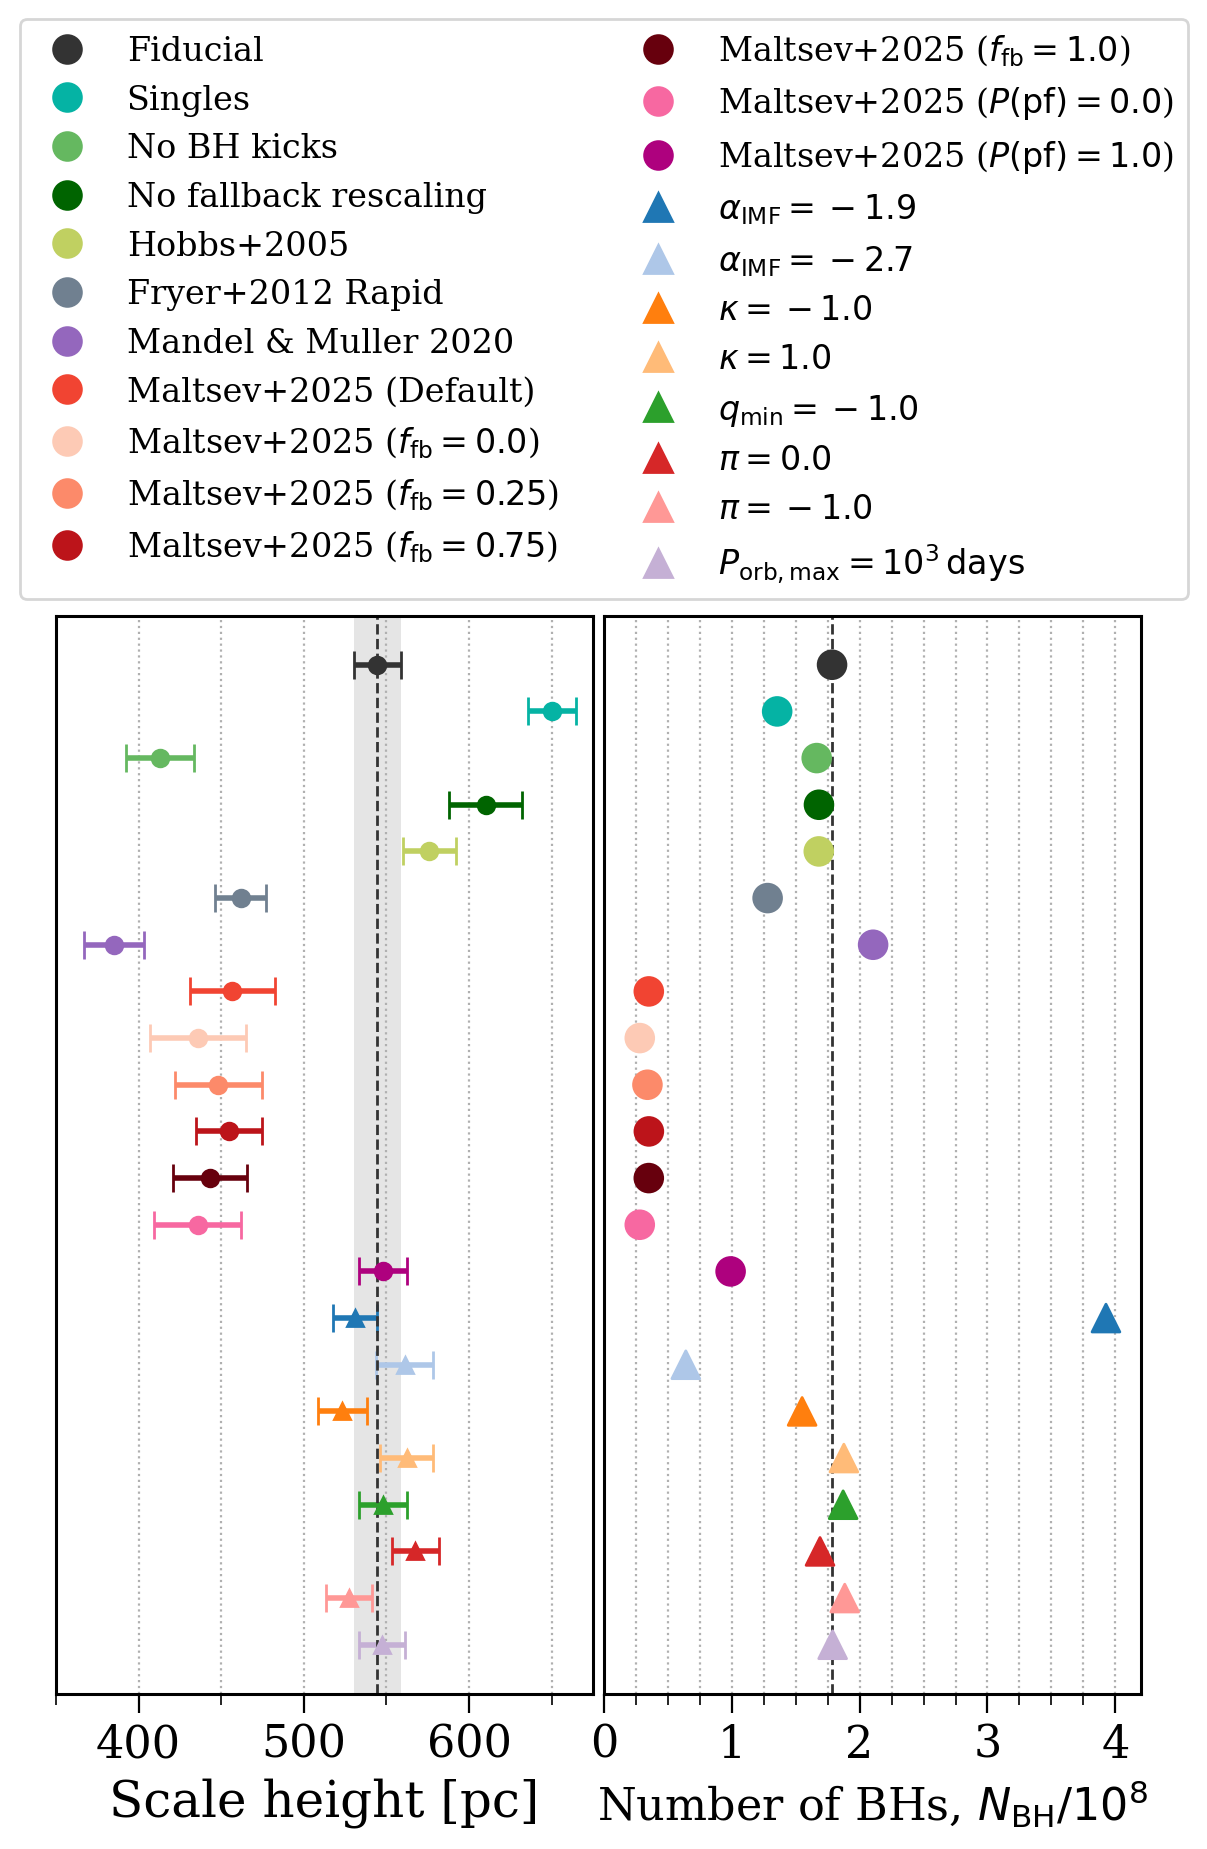

In [129]:
reload(constants)

fig, axes = plt.subplots(1, 2, figsize=(7, 7), sharey=True)

fig.subplots_adjust(wspace=0.02)

yticklabels = []

# make a scatter plot of the scale heights
ii = 0
for i, row in df.iterrows():
    if i == r"$\beta = 0.0$":
        break
    axes[0].errorbar(x=row["$h_z$ (pc)"], xerr=row["$\\sigma_{h_z}$ (pc)"], y=plot_labels[ii], color=constants.SIMULATION_COLOURS[ii], marker=markers[ii], markersize=6, capsize=5, lw=2)
    yticklabels.append(plot_labels[ii])
    ii += 1

# create a legend with the labels
handles = [plt.Line2D([0], [0], color=constants.SIMULATION_COLOURS[i], marker=markers[i], linestyle='', markersize=10) for i in range(len(main_labels))]
axes[1].legend(handles, yticklabels, loc="lower center", fontsize=12, ncol=2, bbox_to_anchor=(0.0, 1.0))

axes[0].set(
    yticks=[]
)
axes[0].set_xlabel("Scale height [pc]", fontsize=18)

axes[0].axvline(df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"], color="#333", lw=1, ls="--")
axes[0].axvspan(df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"] - df.loc[r"$f_{\rm bin} = 1.0$", "$\\sigma_{h_z}$ (pc)"], df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"] + df.loc[r"$f_{\rm bin} = 1.0$", "$\\sigma_{h_z}$ (pc)"], color="black", alpha=0.1, lw=0)
axes[0].invert_yaxis()
# axes[0].xaxis.set_major_locator(plt.MultipleLocator(100))
axes[0].xaxis.set_minor_locator(plt.MultipleLocator(50))


plot_df = df.loc[main_labels]
ms = np.array([markers[i] for i in range(len(main_labels))])
ls = np.array([plot_labels[i] for i in range(len(main_labels))])
cs = np.array([constants.SIMULATION_COLOURS[i] for i in range(len(main_labels))])
for m in ['o', '^']:
    mask = ms == m
    axes[1].scatter(plot_df["$N_{\\rm BH} / 10^8$"][mask], ls[mask], color=cs[mask], zorder=10, marker=m, s=100)
axes[1].set_xlabel(r"Number of BHs, $N_{\rm BH} / 10^8$", fontsize=16)
axes[1].xaxis.set_major_locator(plt.MultipleLocator(1))
axes[1].xaxis.set_minor_locator(plt.MultipleLocator(.25))
axes[1].axvline(plot_df["$N_{\\rm BH} / 10^8$"].values[0], color="#333", ls="--", zorder=-1, lw=1)

axes[0].set_xlim(350, 675)
axes[1].set_xlim(0, 4.2)



axes[0].grid(True, which='both', axis='x', ls=':', zorder=-100)
axes[1].grid(True, which='both', axis='x', ls=':', zorder=-100)

for ax in axes:
    ax.tick_params(which='both', axis='x', labelsize=16)

plt.savefig("../plots/bh_summary_stats.pdf", format='pdf', bbox_inches='tight')

plt.show()

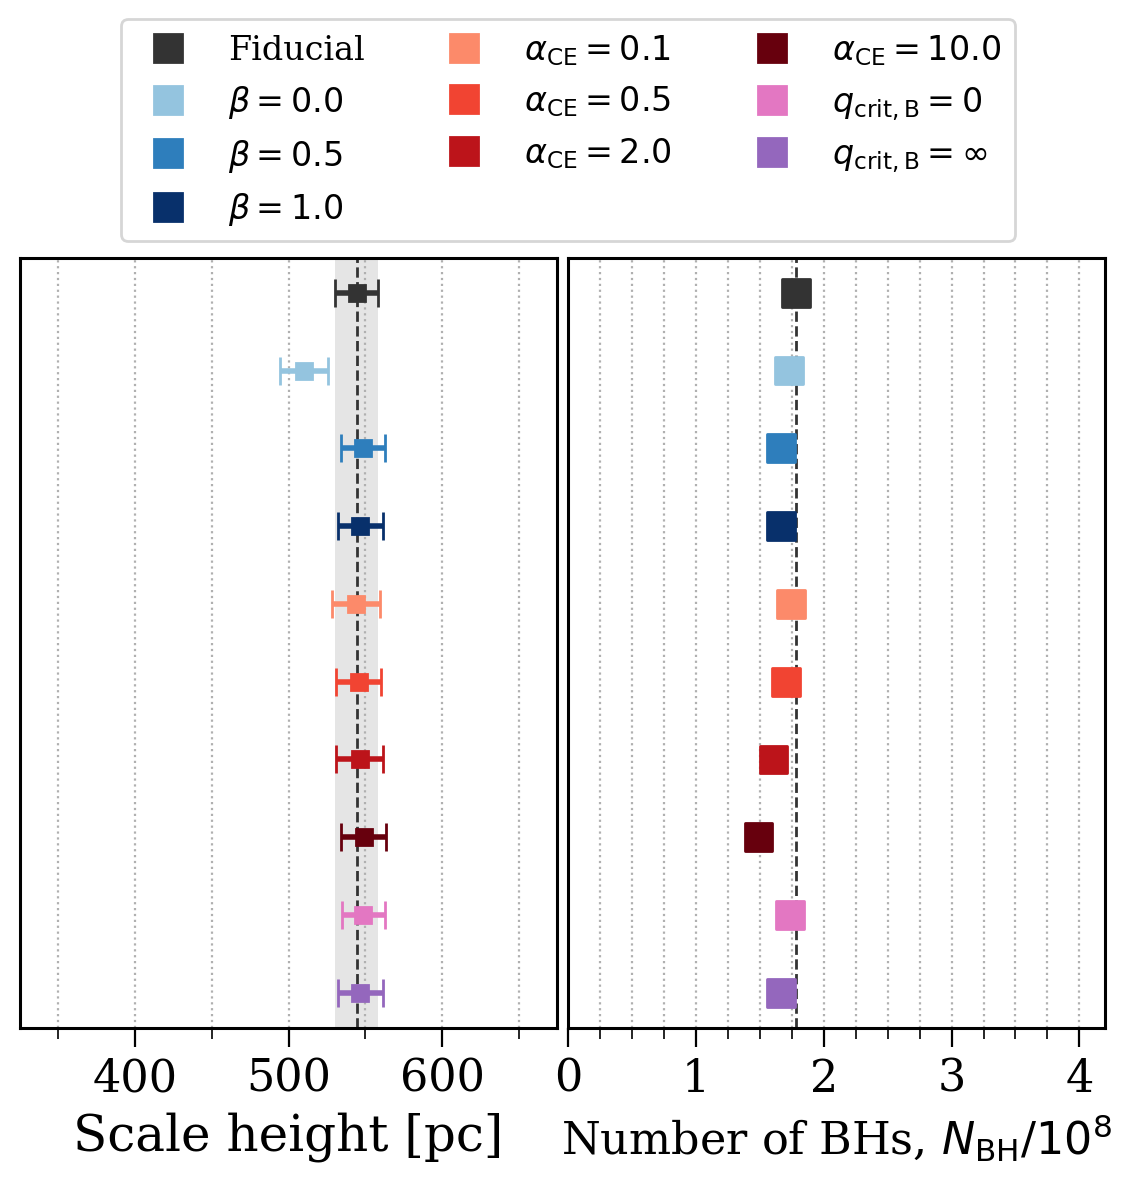

In [127]:
reload(constants)

fig, axes = plt.subplots(1, 2, figsize=(7, 5), sharey=True)

fig.subplots_adjust(wspace=0.02)

yticklabels = []

plot_df = df.loc[mt_labels]
mt_labels_inds = [labels.index(label) for label in mt_labels]

# make a scatter plot of the scale heights
ii = 0
for i, row in plot_df.iterrows():
    axes[0].errorbar(x=row["$h_z$ (pc)"], xerr=row["$\\sigma_{h_z}$ (pc)"], y=plot_labels[mt_labels_inds[ii]], color=constants.SIMULATION_COLOURS[mt_labels_inds[ii]], marker='s', markersize=6, capsize=5, lw=2)
    yticklabels.append(plot_labels[mt_labels_inds[ii]])
    ii += 1

# create a legend with the labels
handles = [plt.Line2D([0], [0], color=constants.SIMULATION_COLOURS[i], marker='s', linestyle='', markersize=10) for i in mt_labels_inds]
axes[1].legend(handles, yticklabels, loc="lower center", fontsize=12, ncol=3, bbox_to_anchor=(0.0, 1.0))

axes[0].set(
    yticks=[]
)
axes[0].set_xlabel("Scale height [pc]", fontsize=18)

axes[0].axvline(df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"], color="#333", lw=1, ls="--")
axes[0].axvspan(df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"] - df.loc[r"$f_{\rm bin} = 1.0$", "$\\sigma_{h_z}$ (pc)"], df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"] + df.loc[r"$f_{\rm bin} = 1.0$", "$\\sigma_{h_z}$ (pc)"], color="black", alpha=0.1, lw=0)
axes[0].invert_yaxis()
# axes[0].xaxis.set_major_locator(plt.MultipleLocator(100))
axes[0].xaxis.set_minor_locator(plt.MultipleLocator(50))



axes[1].scatter(plot_df["$N_{\\rm BH} / 10^8$"], [plot_labels[i] for i in mt_labels_inds],
                color=[constants.SIMULATION_COLOURS[i] for i in mt_labels_inds],
                marker='s',
                zorder=10,
                s=100)
axes[1].set_xlabel(r"Number of BHs, $N_{\rm BH} / 10^8$", fontsize=16)
axes[1].set_xlim(1.5, 2.0)
axes[1].xaxis.set_major_locator(plt.MultipleLocator(1))
axes[1].xaxis.set_minor_locator(plt.MultipleLocator(.25))
axes[1].axvline(plot_df["$N_{\\rm BH} / 10^8$"].values[0], color="#333", ls="--", zorder=-1, lw=1)


axes[0].grid(True, which='both', axis='x', ls=':', zorder=-100)
axes[1].grid(True, which='both', axis='x', ls=':', zorder=-100)

axes[0].set_xlim(325, 675)
axes[1].set_xlim(0, 4.2)

for ax in axes:
    ax.tick_params(which='both', axis='x', labelsize=16)

plt.savefig("../plots/bh_summary_stats_mt.pdf", format='pdf', bbox_inches='tight')

plt.show()

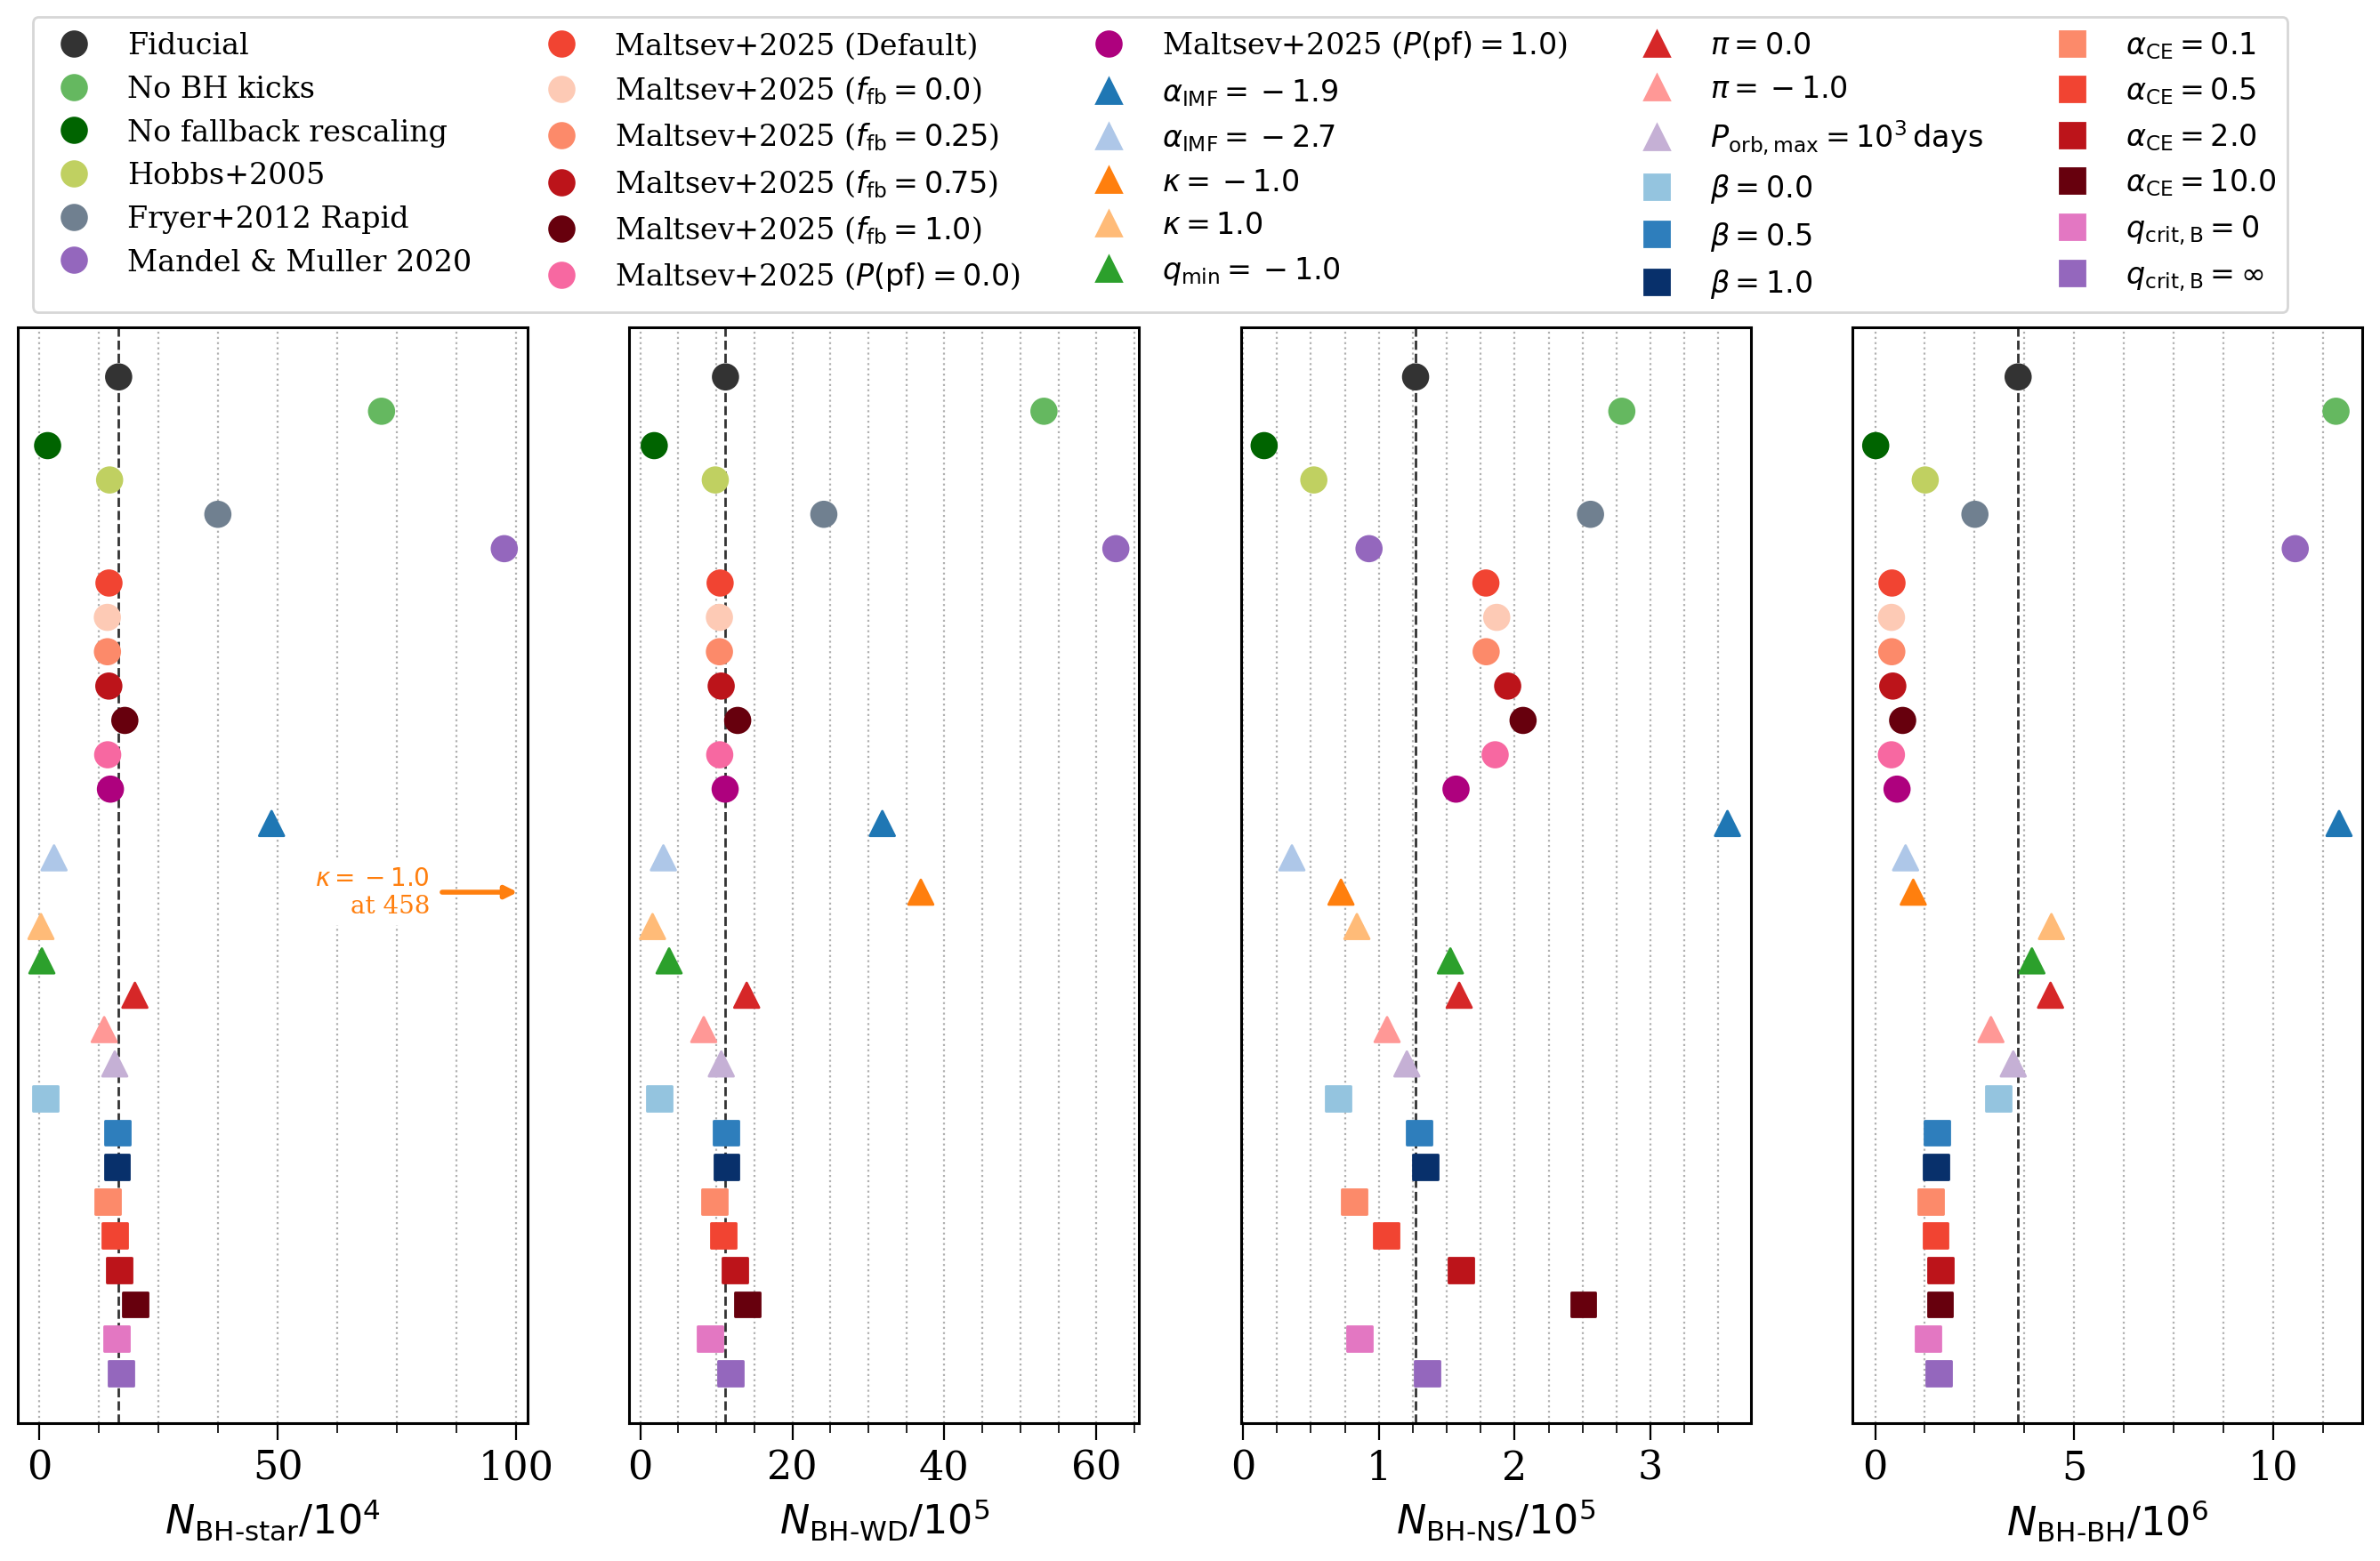

In [125]:
reload(constants)

fig, axes = plt.subplots(1, 4, figsize=(17, 8), sharey=True)

# main labels without the 2nd entry
main_labels_no_singles = [label for label in main_labels if label != r"$f_{\rm bin} = 0.0$"]
main_labels_no_singles += [label for label in mt_labels if label != r"$f_{\rm bin} = 1.0$"]
labels_inds = [labels.index(label) for label in main_labels_no_singles]

# # create a legend with the labels
handles = [plt.Line2D([0], [0], color=constants.SIMULATION_COLOURS[i], marker=markers[i], linestyle='', markersize=10) for i in labels_inds]
axes[0].legend(handles, np.array(plot_labels)[labels_inds], loc="lower left", fontsize=12, ncol=5, bbox_to_anchor=(0.0, 1.0))

for ax in axes:
    ax.tick_params(which='both', axis='x', labelsize=16)

# axes[0].set(
#     yticks=[]
# )

# axes[0].axvline(df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"], color="#333", lw=1, ls="--")
# axes[0].axvspan(df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"] - df.loc[r"$f_{\rm bin} = 1.0$", "$\\sigma_{h_z}$ (pc)"], df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"] + df.loc[r"$f_{\rm bin} = 1.0$", "$\\sigma_{h_z}$ (pc)"], color="black", alpha=0.1, lw=0)
# axes[0].invert_yaxis()

axes_x_lims = []

for col, ax in zip(
    [r"$N_{\rm BH\text{-}star} / 10^4$", r"$N_{\rm BH\text{-}WD} / 10^5$", r"$N_{\rm BH\text{-}NS} / 10^5$", r"$N_{\rm BH\text{-}BH} / 10^6$"],
    axes
):
    plot_df = df.loc[main_labels_no_singles]

    vs = plot_df[col].values.copy()
    actual_ls = plot_df.index.values
    ls = np.array([plot_labels[i] for i in labels_inds])
    cs = np.array([constants.SIMULATION_COLOURS[i] for i in labels_inds])
    ms = np.array([markers[i] for i in labels_inds])

    # avoid extreme outliers
    outliers = vs > vs[0] * 20
    vs[outliers] = np.nan
    # ax.scatter(vs[0], ls[0], color=cs[0], zorder=10, s=100, marker='o')

    for m in ['o', '^', 's']:
        mask = ms == m
        ax.scatter(vs[mask], ls[mask], color=cs[mask], marker=m, zorder=10, s=100)

    # but make sure we can see they would have been there with an arrow to the right
    if outliers.any():
        for i in np.where(outliers)[0]:
            ax.annotate(ls[i] + f"\nat {plot_df[col].values[i]:.0f}" , xy=(ax.get_xlim()[1] * 0.99, ls[i]), xytext=(ax.get_xlim()[1] * 0.8, ls[i]),
                        arrowprops=dict(arrowstyle="-|>", color=cs[i], lw=2), va='center', ha='right', color=cs[i], fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec='none'))

    ax.set_xlabel(col, fontsize=16)
    ax.axvline(plot_df[col].values[0], color="#333", ls="--", zorder=-1, lw=1)
    ax.xaxis.set_minor_locator(plt.MultipleLocator((ax.get_xticks()[1] - ax.get_xticks()[0]) / 4))

    axes_x_lims.append(ax.get_xlim())

    print()

# plot_df = df.loc[main_labels]
# axes[1].scatter(plot_df["$N_{\\rm BH} / 10^8$"], [plot_labels[i] for i in range(len(main_labels))],
#                 color=[constants.SIMULATION_COLOURS[i] for i in range(len(main_labels))], zorder=10,
#                 s=100)
# axes[1].set_xlabel(r"Number of BHs, $N_{\rm BH} / 10^8$", fontsize=16)
# axes[1].xaxis.set_major_locator(plt.MultipleLocator(1))
# axes[1].xaxis.set_minor_locator(plt.MultipleLocator(.1))
# axes[1].axvline(plot_df["$N_{\\rm BH} / 10^8$"].values[0], color="#333", ls="--", zorder=-1, lw=1)

# axes[0].set_xlim(325, 1375)
# axes[1].set_xlim(0, 2.5)
axes[0].invert_yaxis()
axes[0].set_yticks([])

for ax in axes:
    ax.grid(True, which='both', axis='x', ls=':', zorder=-100)

plt.savefig("../plots/bh_binary_summary_stats.pdf", format='pdf', bbox_inches='tight')

plt.show()

In [31]:
list(data.keys())

['$f_{\\rm bin} = 1.0$',
 '$f_{\\rm bin} = 0.0$',
 'No BH kicks',
 'No fallback rescaling',
 'Hobbs+2005',
 'Fryer+2012 Rapid',
 'Mandel\\&Muller2020',
 'Maltsev+2025',
 '$f_{\\rm fb} = 0.0$',
 '$f_{\\rm fb} = 0.25$',
 '$f_{\\rm fb} = 0.75$',
 '$f_{\\rm fb} = 1.0$',
 '$P({\\rm pf}) = 0.0$',
 '$P({\\rm pf}) = 1.0$',
 '$\\alpha_{\\rm IMF} = -1.9$',
 '$\\alpha_{\\rm IMF} = -2.7$',
 '$\\kappa = -1.0$',
 '$\\kappa = 1.0$',
 '$q_{\\rm min} = -1.0$',
 '$\\pi = 0.0$',
 '$\\pi = -1.0$',
 '$P_{\\rm orb, max} = 10^3\\,{\\rm days}$',
 '$\\beta = 0.0$',
 '$\\beta = 0.5$',
 '$\\beta = 1.0$',
 '$\\alpha_{\\rm CE} = 0.1$',
 '$\\alpha_{\\rm CE} = 0.5$',
 '$\\alpha_{\\rm CE} = 2.0$',
 '$\\alpha_{\\rm CE} = 10.0$',
 '$q_{\\rm crit, B} = 0$',
 '$q_{\\rm crit, B} = \\infty$']

In [45]:
data['$f_{\\rm bin} = 0.0$']

{'mass_binaries': np.float64(624770563.8532221),
 'mass_singles': np.float64(34.0),
 'bin_nums': {'NS': array([     0,      2,      7, ..., 318199, 318206, 318209],
        shape=(4634320,)),
  'BH': array([     5,     31,     35, ..., 318070, 318180, 318214],
        shape=(1411353,)),
  'CO': array([     0,      2,      7, ..., 318070, 318180, 318214],
        shape=(6045673,))},
 'companion': {'NS': array([13, 11,  0, ..., 14, 13, 14], shape=(4634320,)),
  'BH': array([13, 13, 14, ..., 14, 14, 14], shape=(1411353,)),
  'CO': array([13, 11,  0, ..., 14, 14, 14], shape=(6045673,))},
 'escaped': {'NS': array([False, False, False, ..., False, False, False], shape=(4634320,)),
  'BH': array([False, False, False, ..., False, False, False], shape=(1411353,)),
  'CO': array([False, False, False, ..., False, False, False], shape=(6045673,))},
 'init_z': {'NS': array([ 0.00140626, -0.04909625,  0.63617398, ...,  0.20379841,
         -0.24234363,  0.33602419], shape=(4634320,)),
  'BH': array(

$f_{\rm bin} = 1.0$ 1737


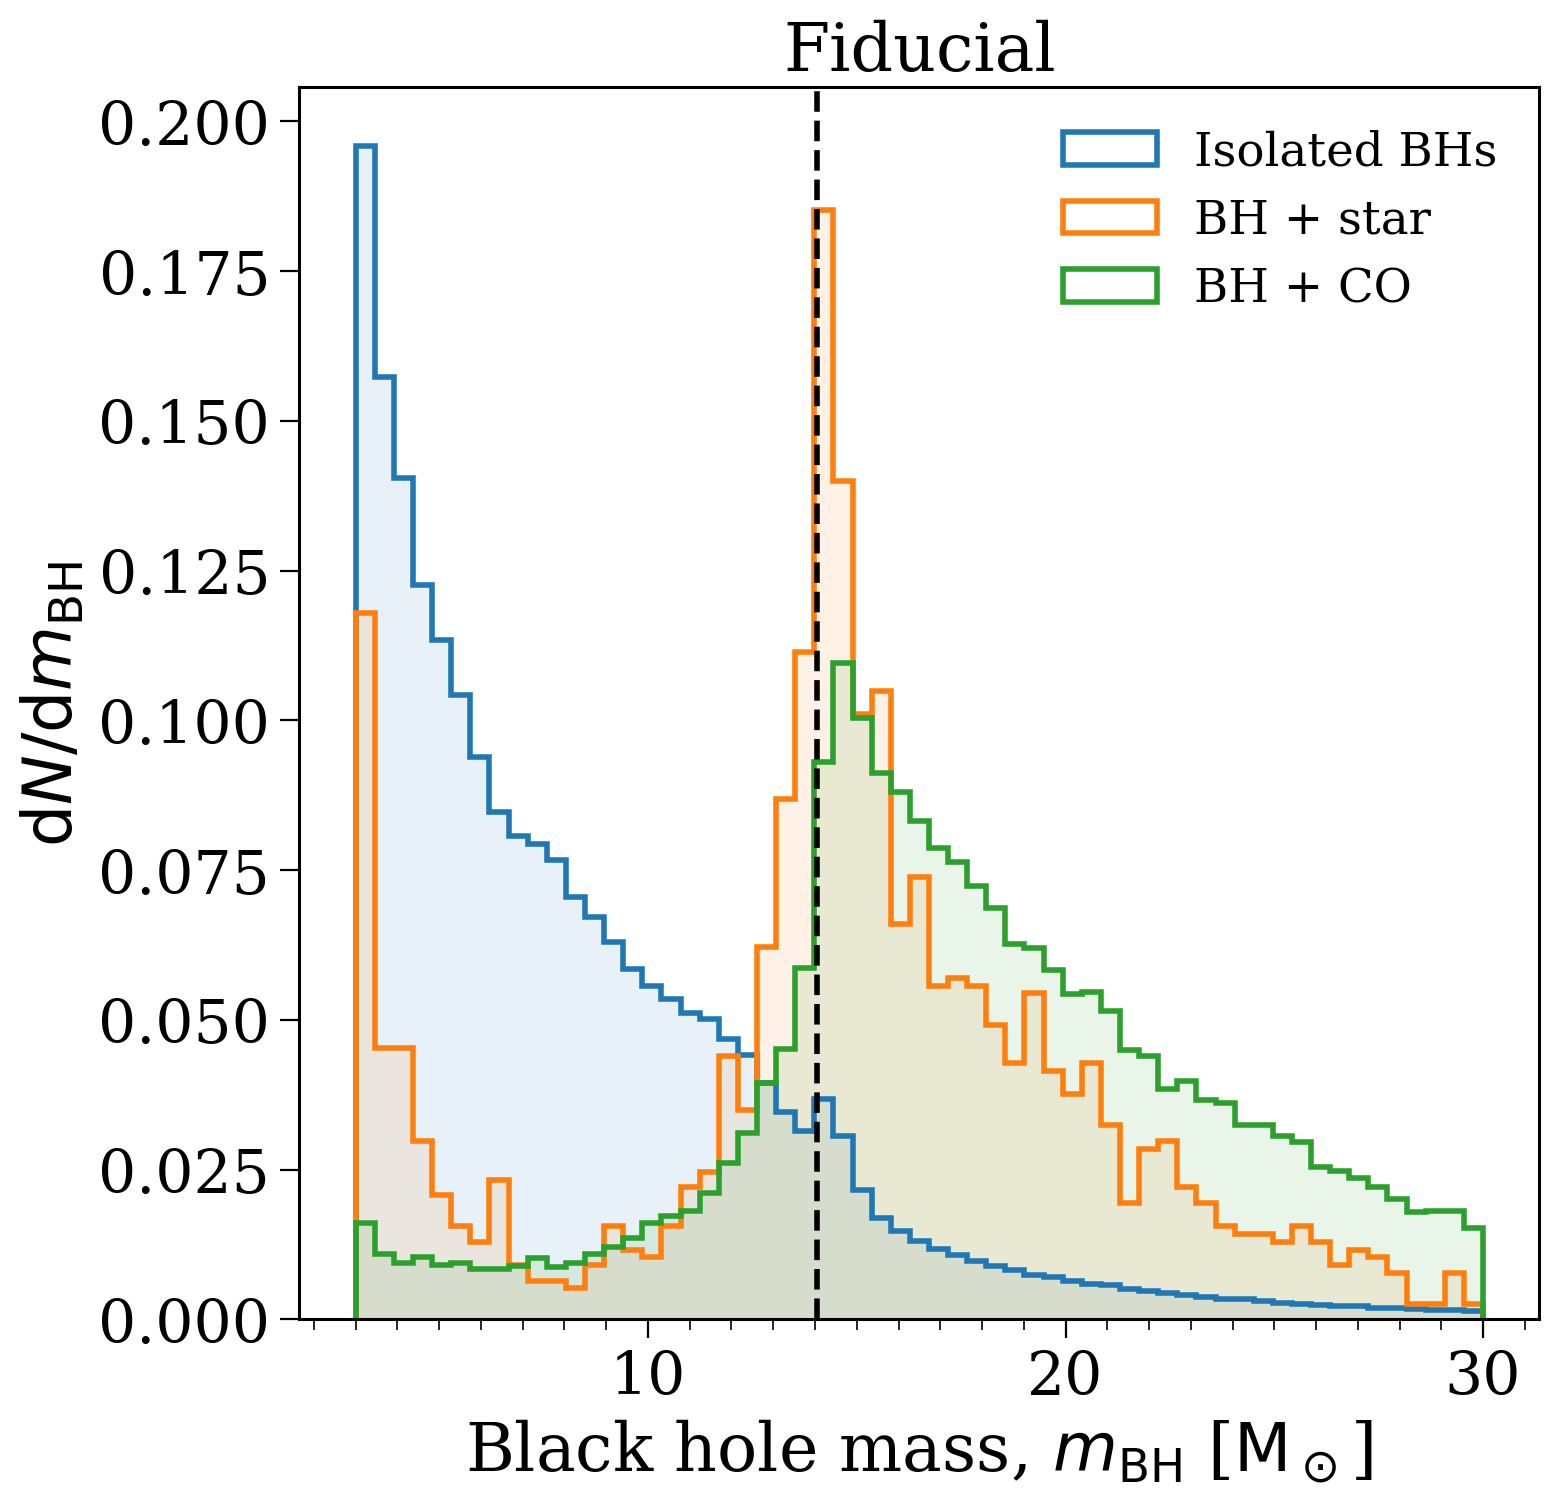

No BH kicks 7471


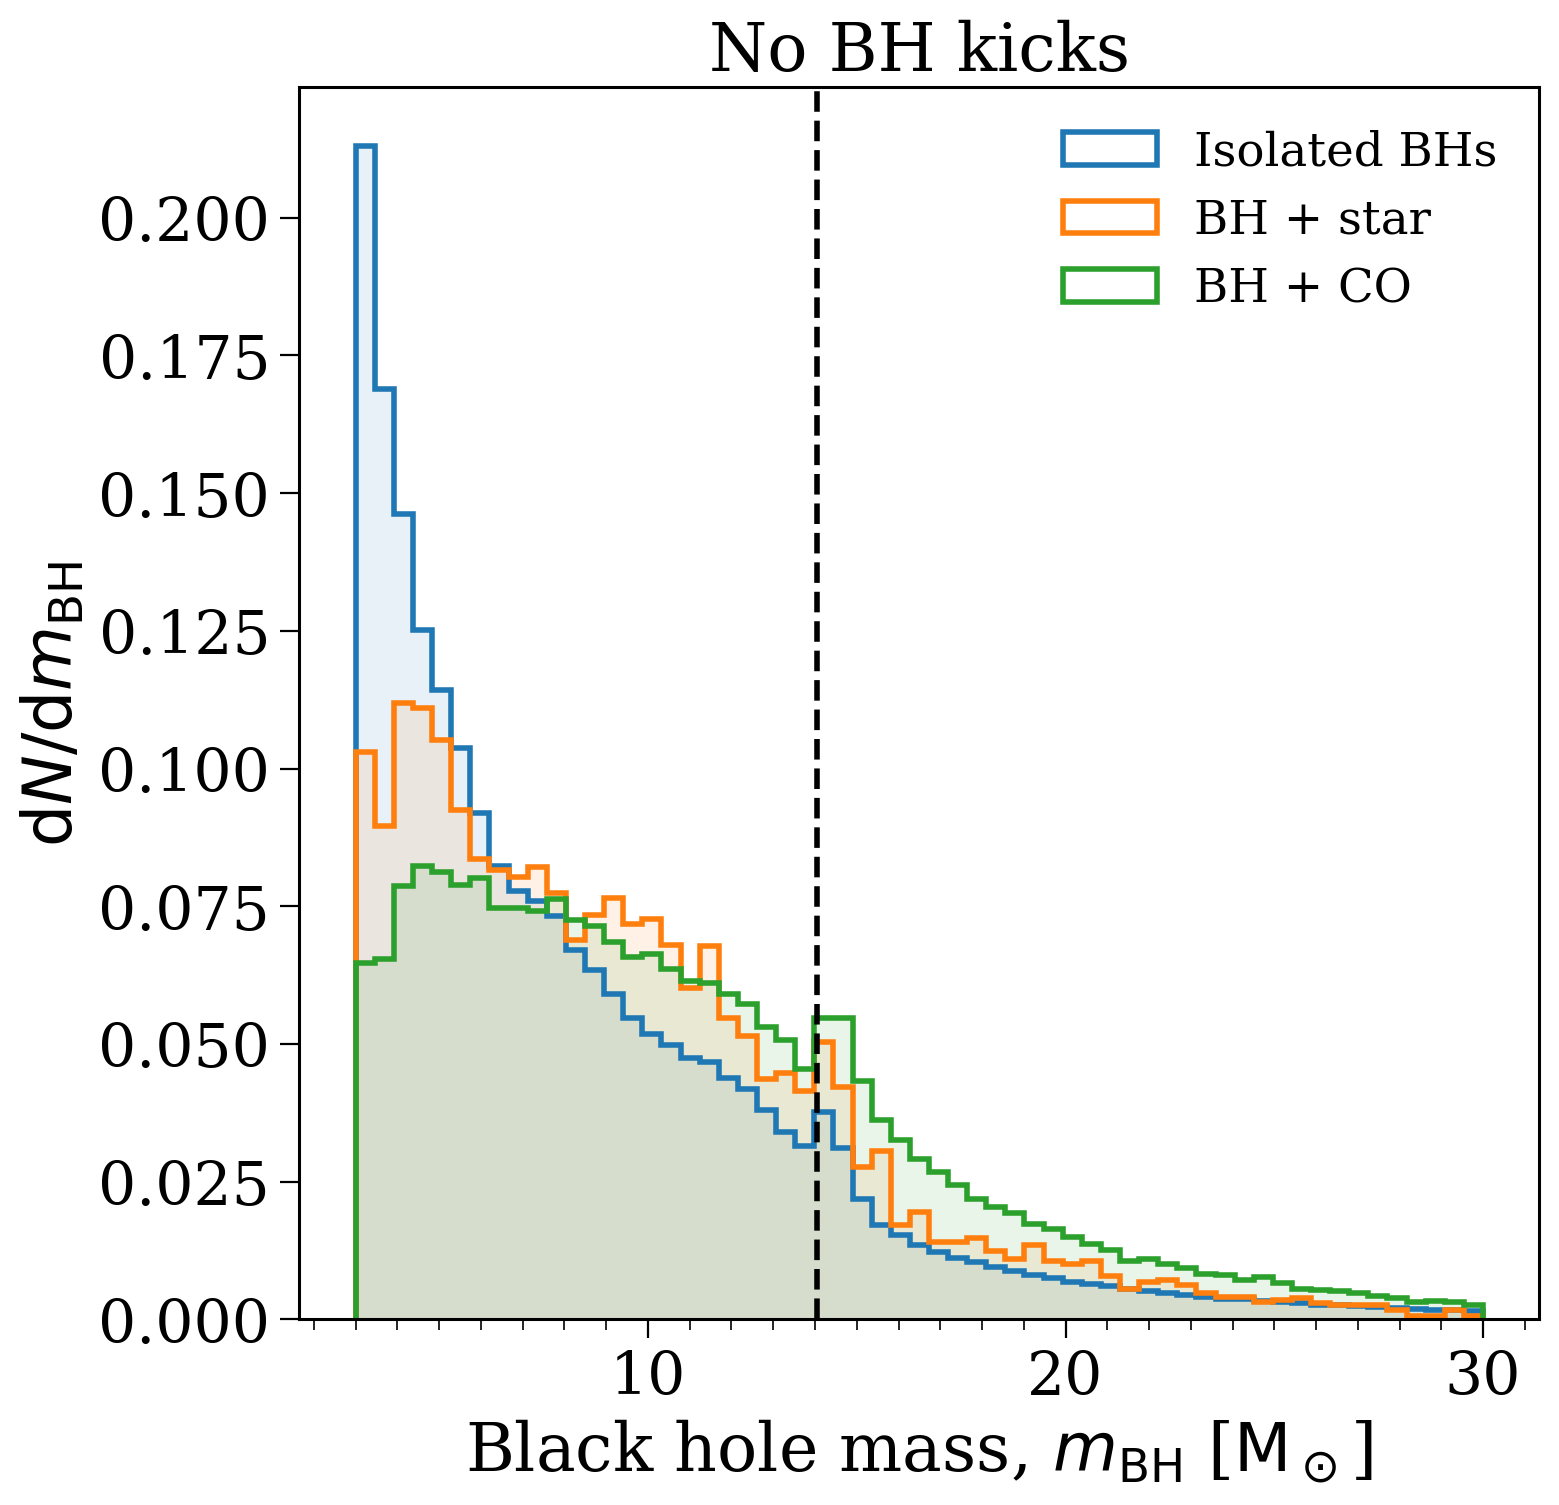

No fallback rescaling 188


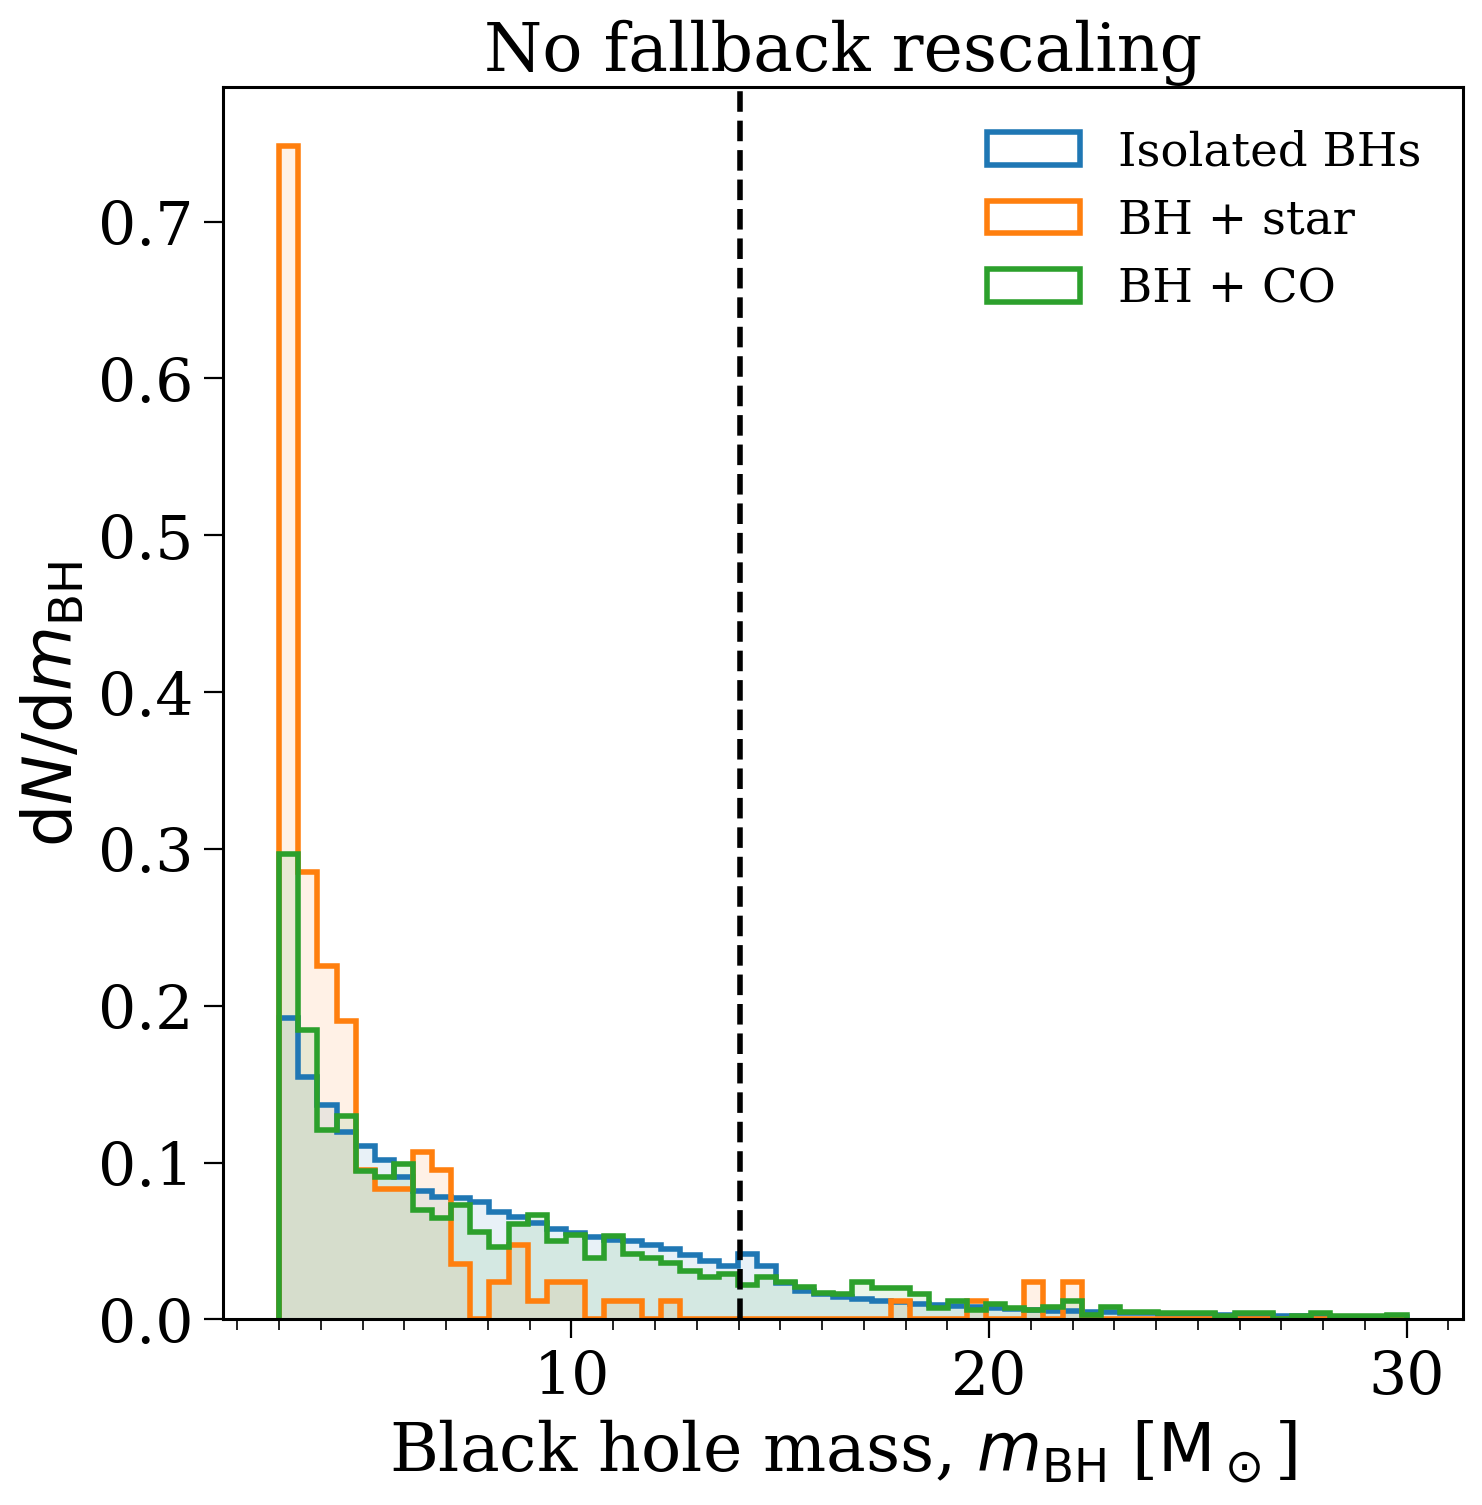

Hobbs+2005 1540


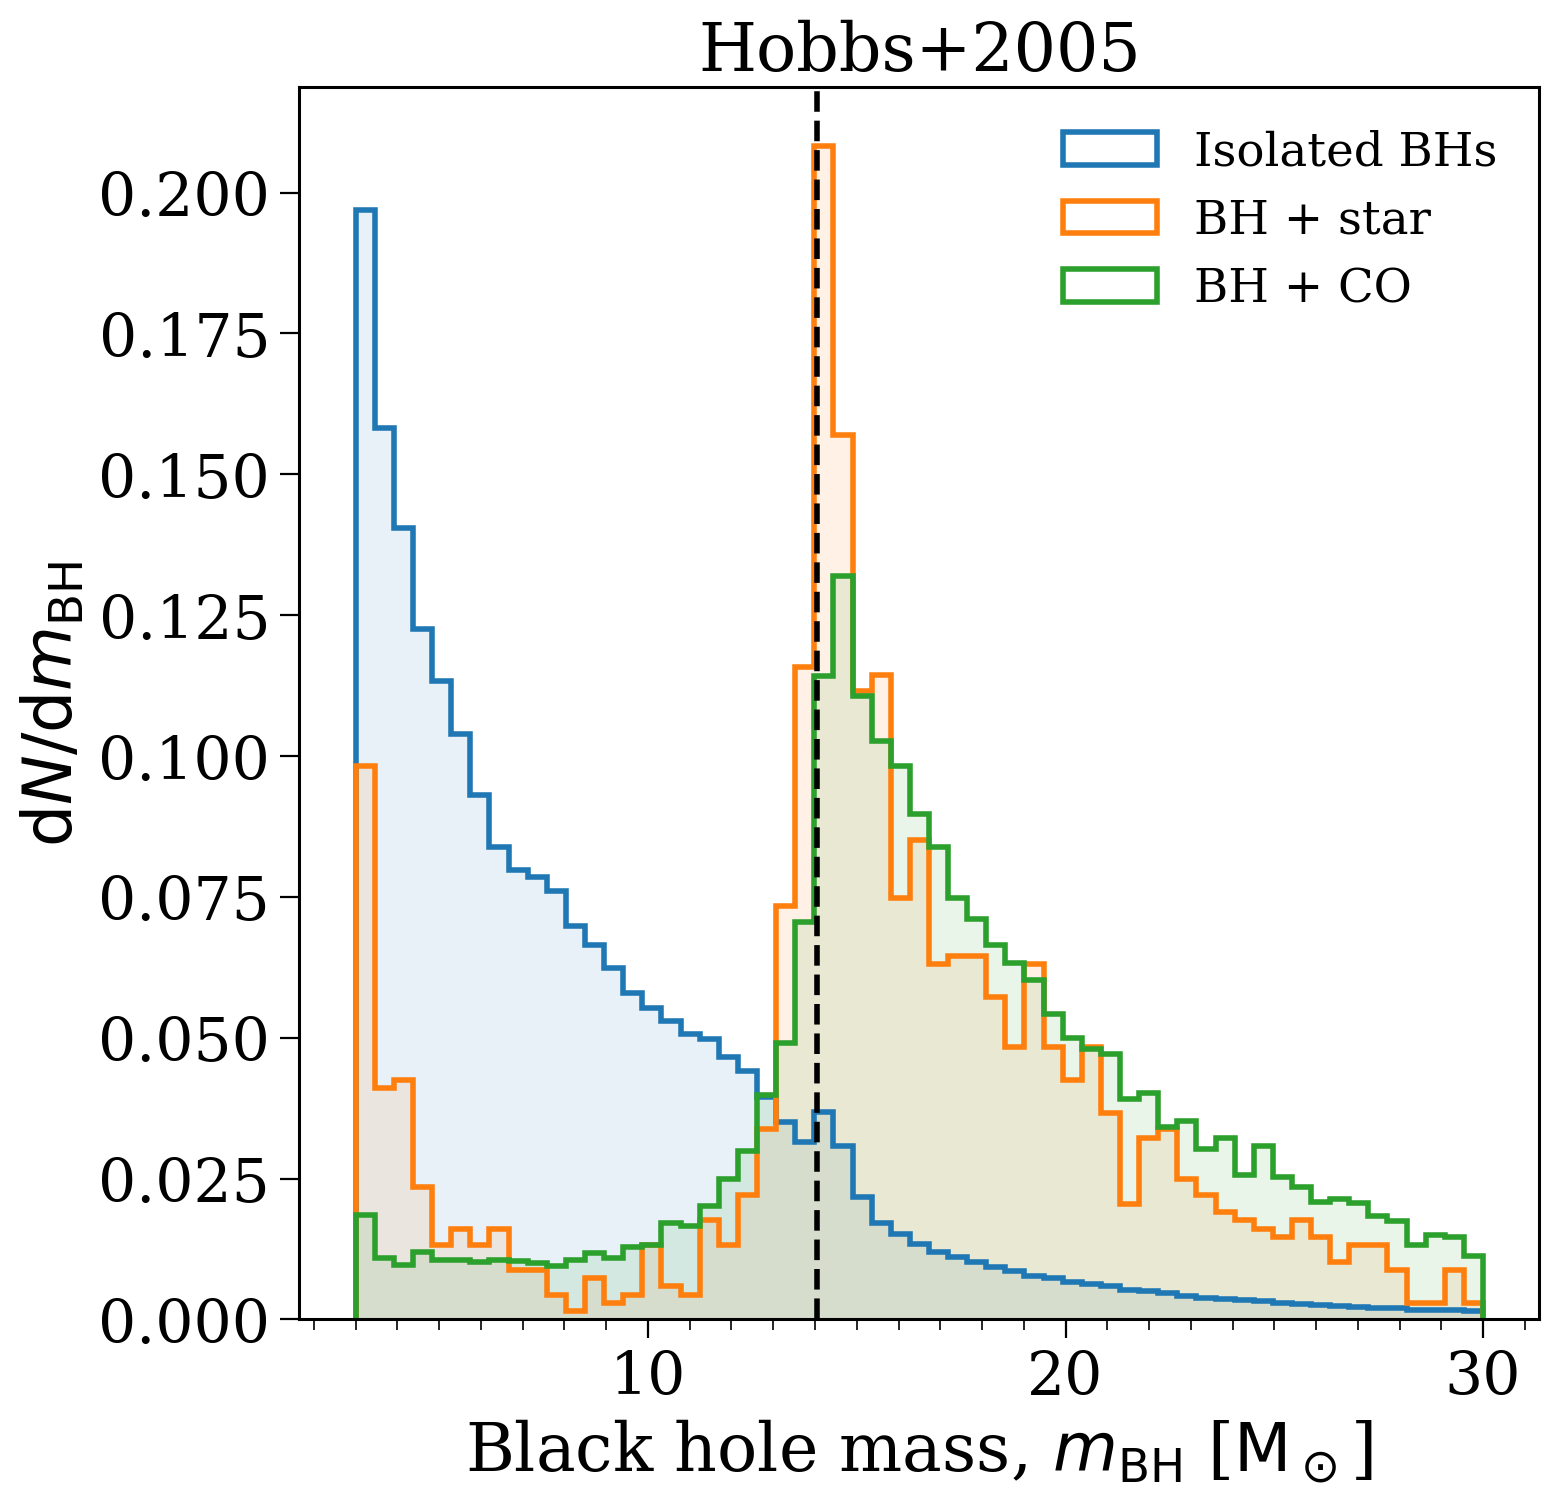

Fryer+2012 Rapid 3901


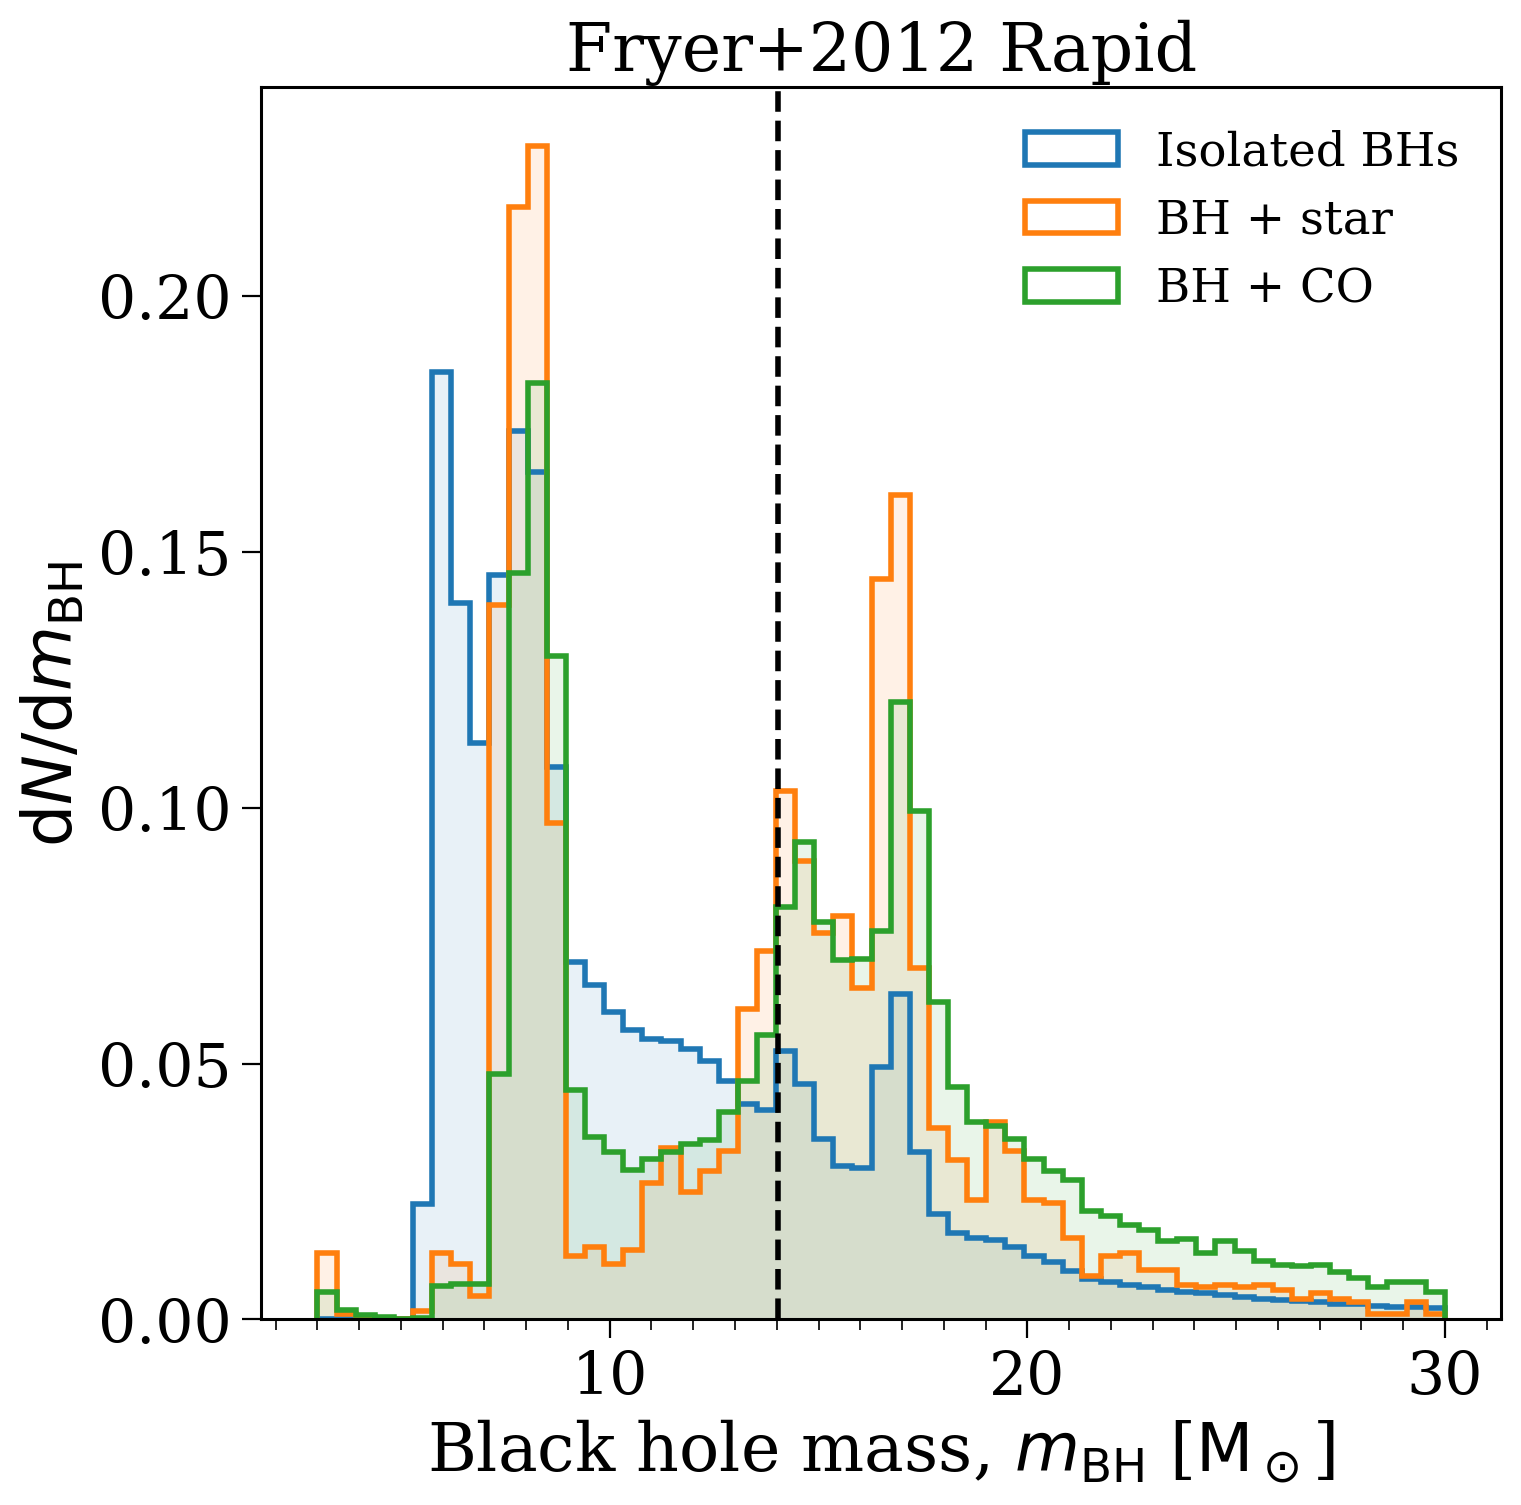

Mandel\&Muller2020 10148


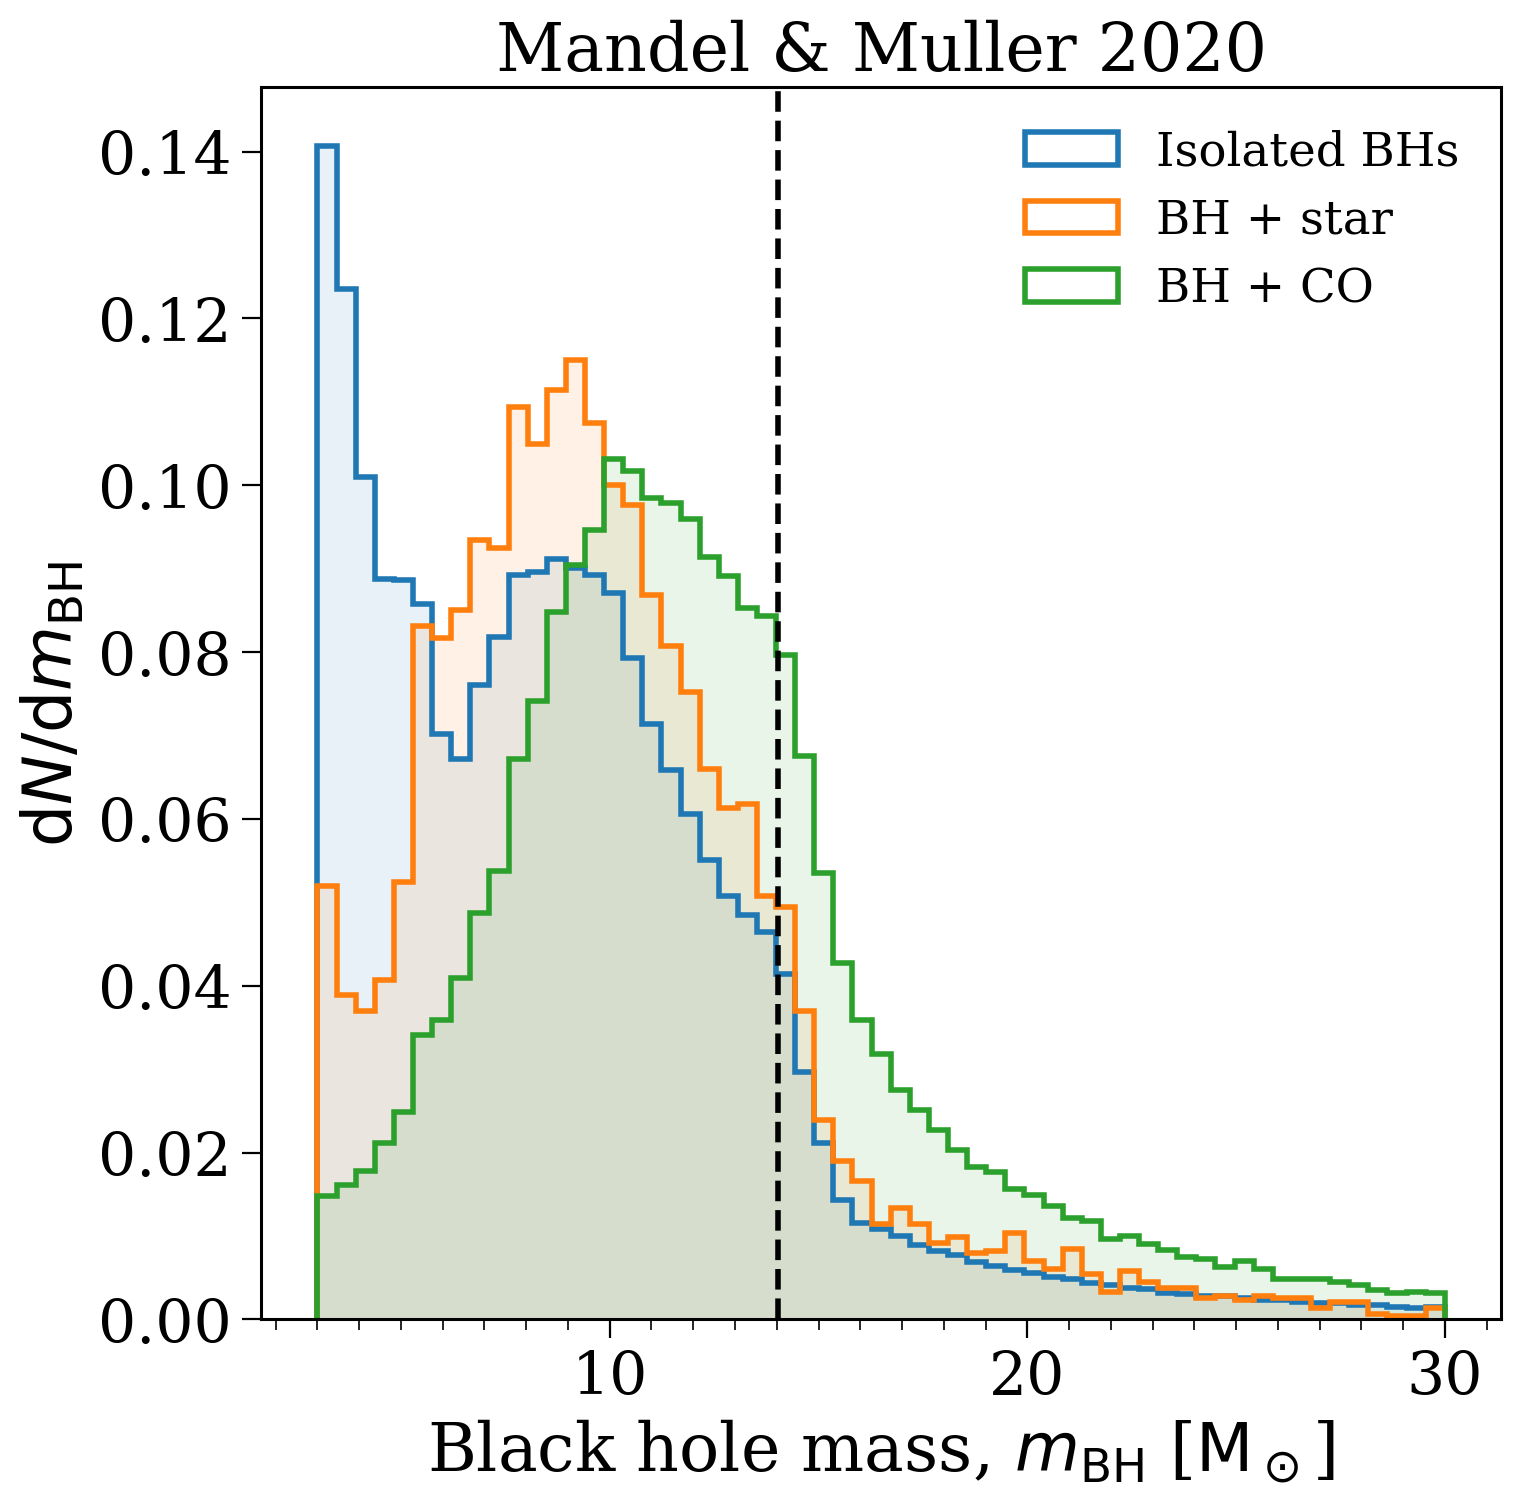

Maltsev+2025 1526


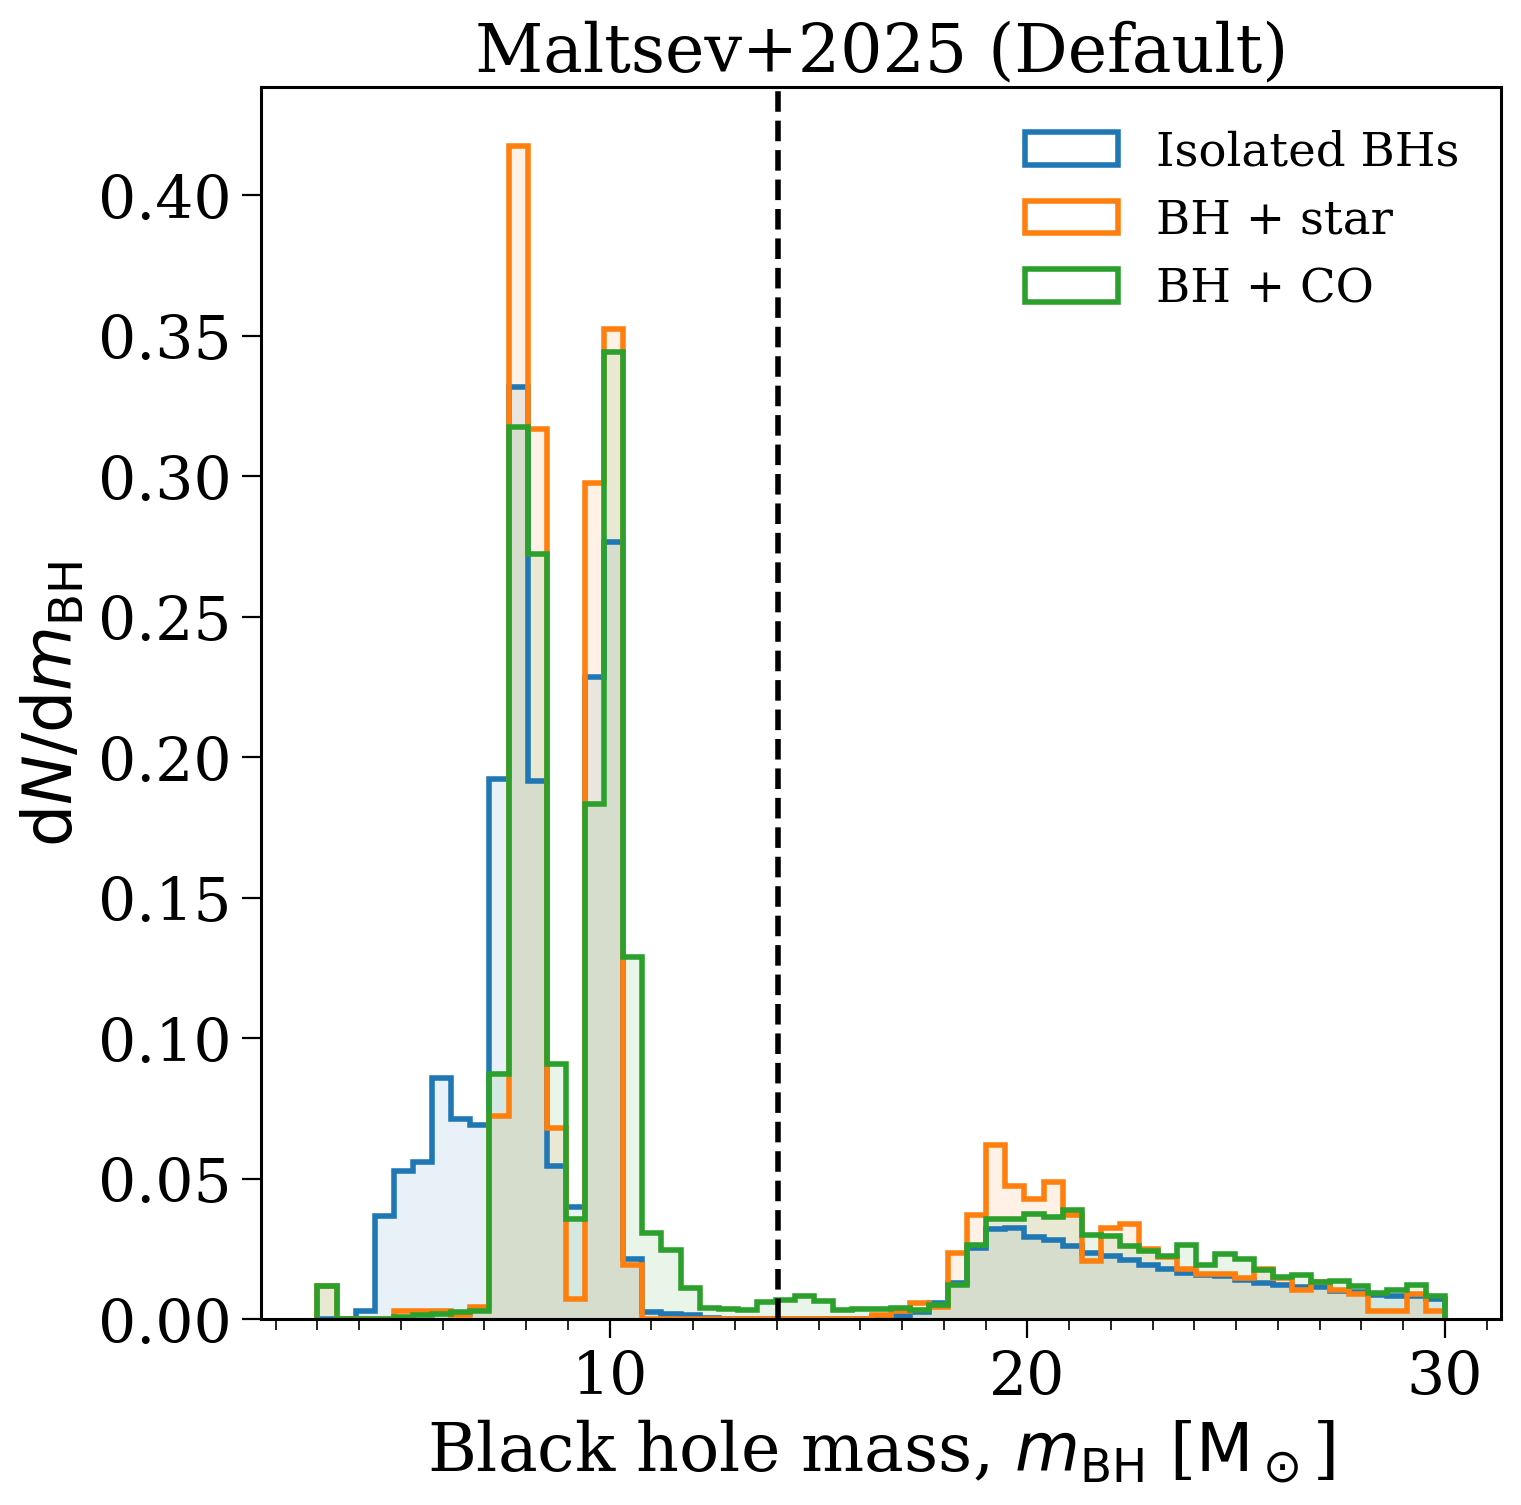

$f_{\rm fb} = 0.0$ 1491


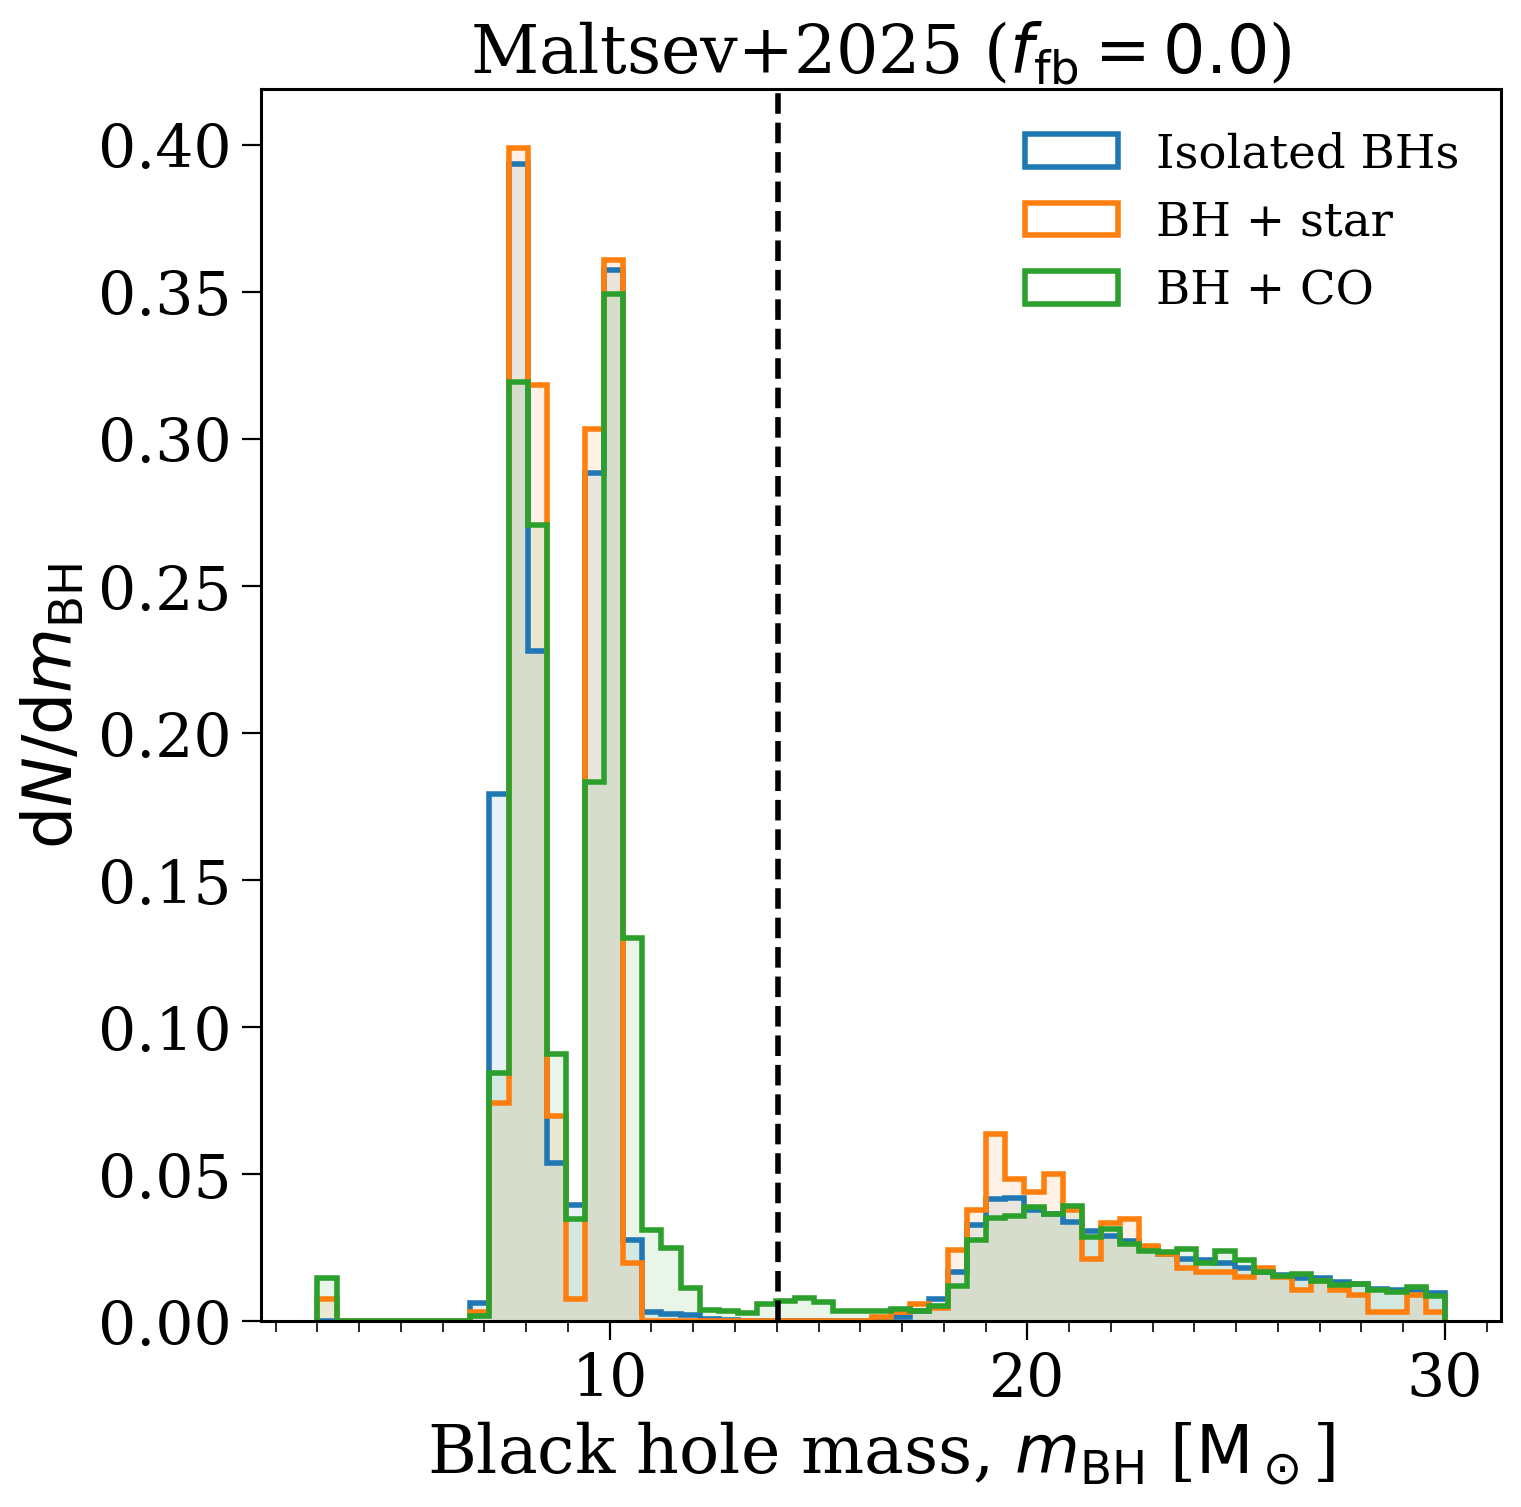

$f_{\rm fb} = 0.25$ 1493


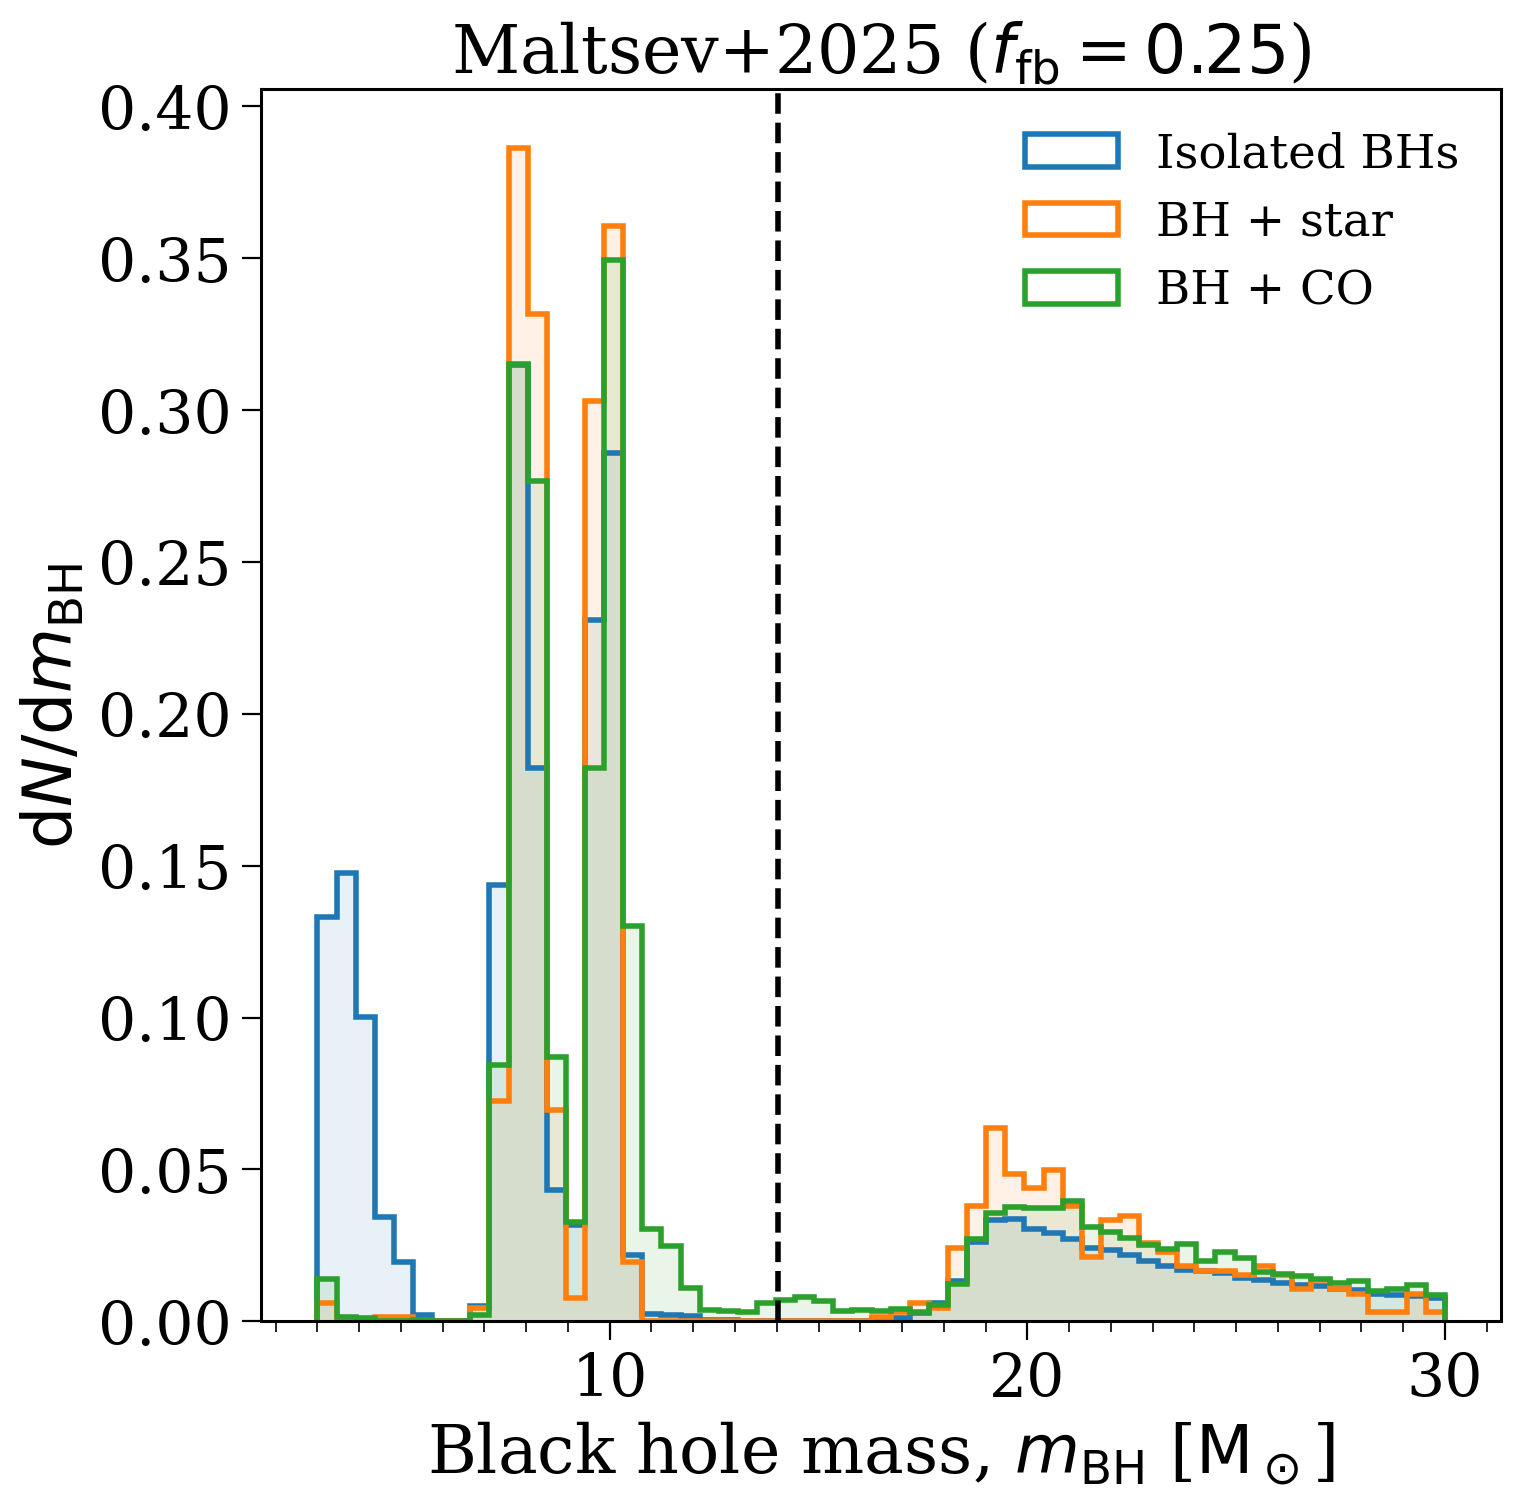

$f_{\rm fb} = 0.75$ 1523


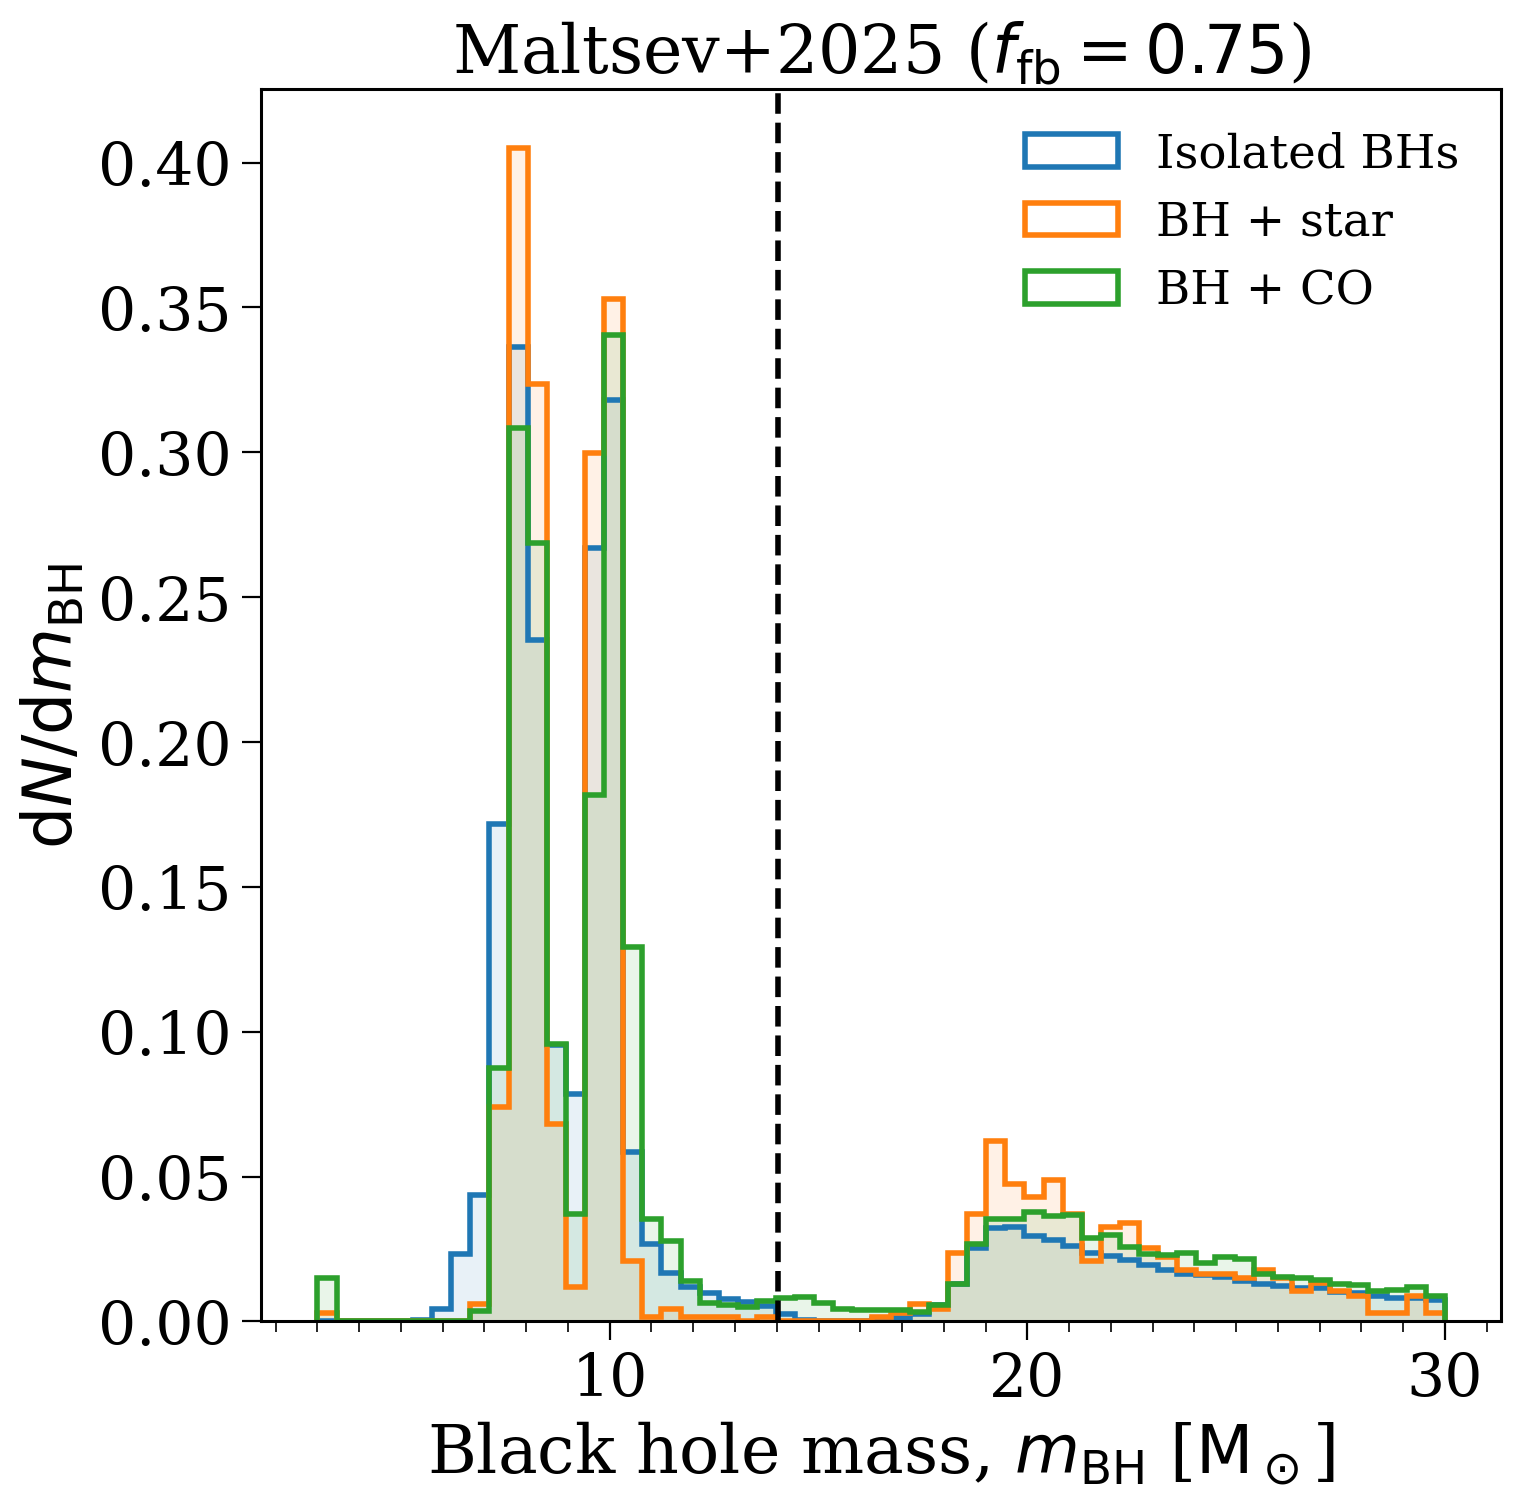

$f_{\rm fb} = 1.0$ 1872


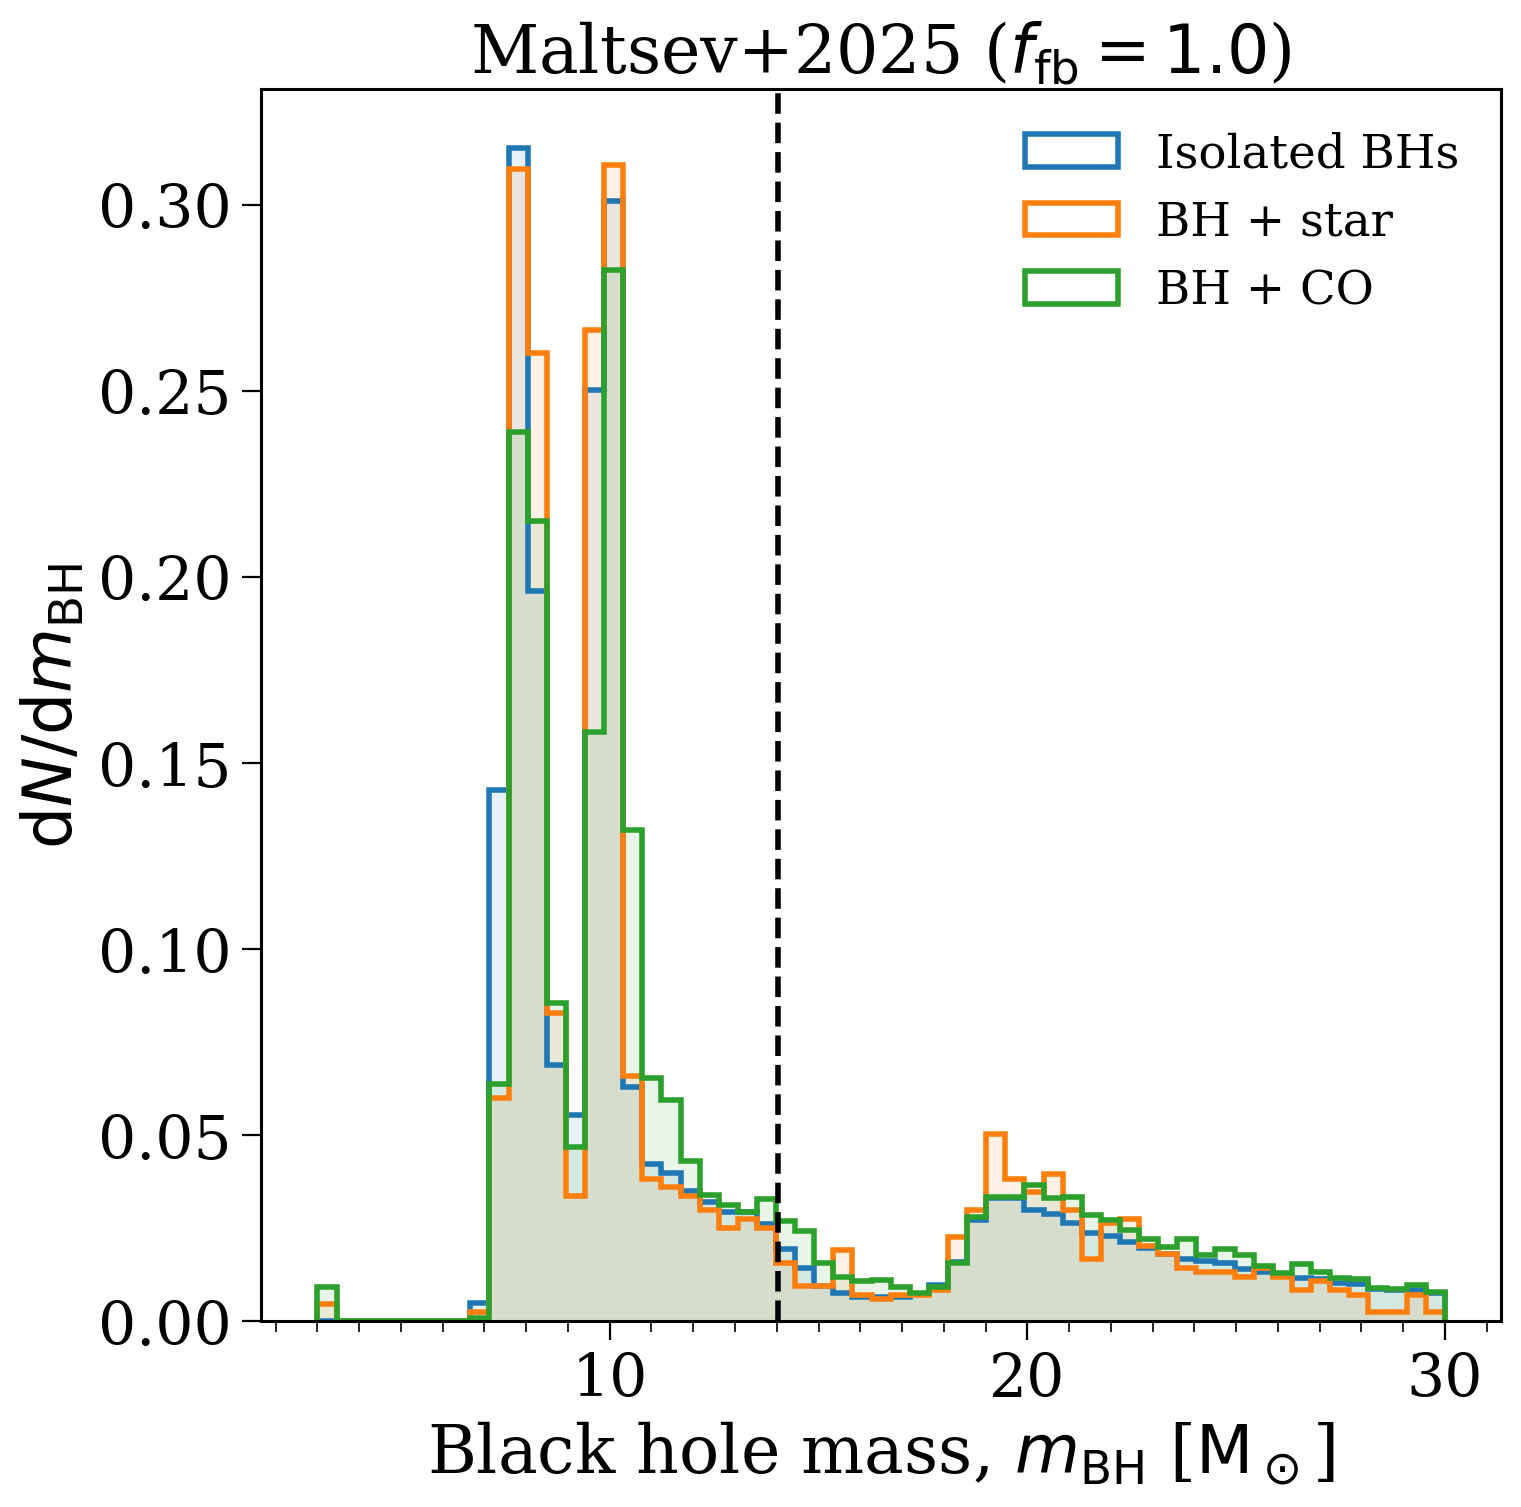

$P({\rm pf}) = 0.0$ 1498


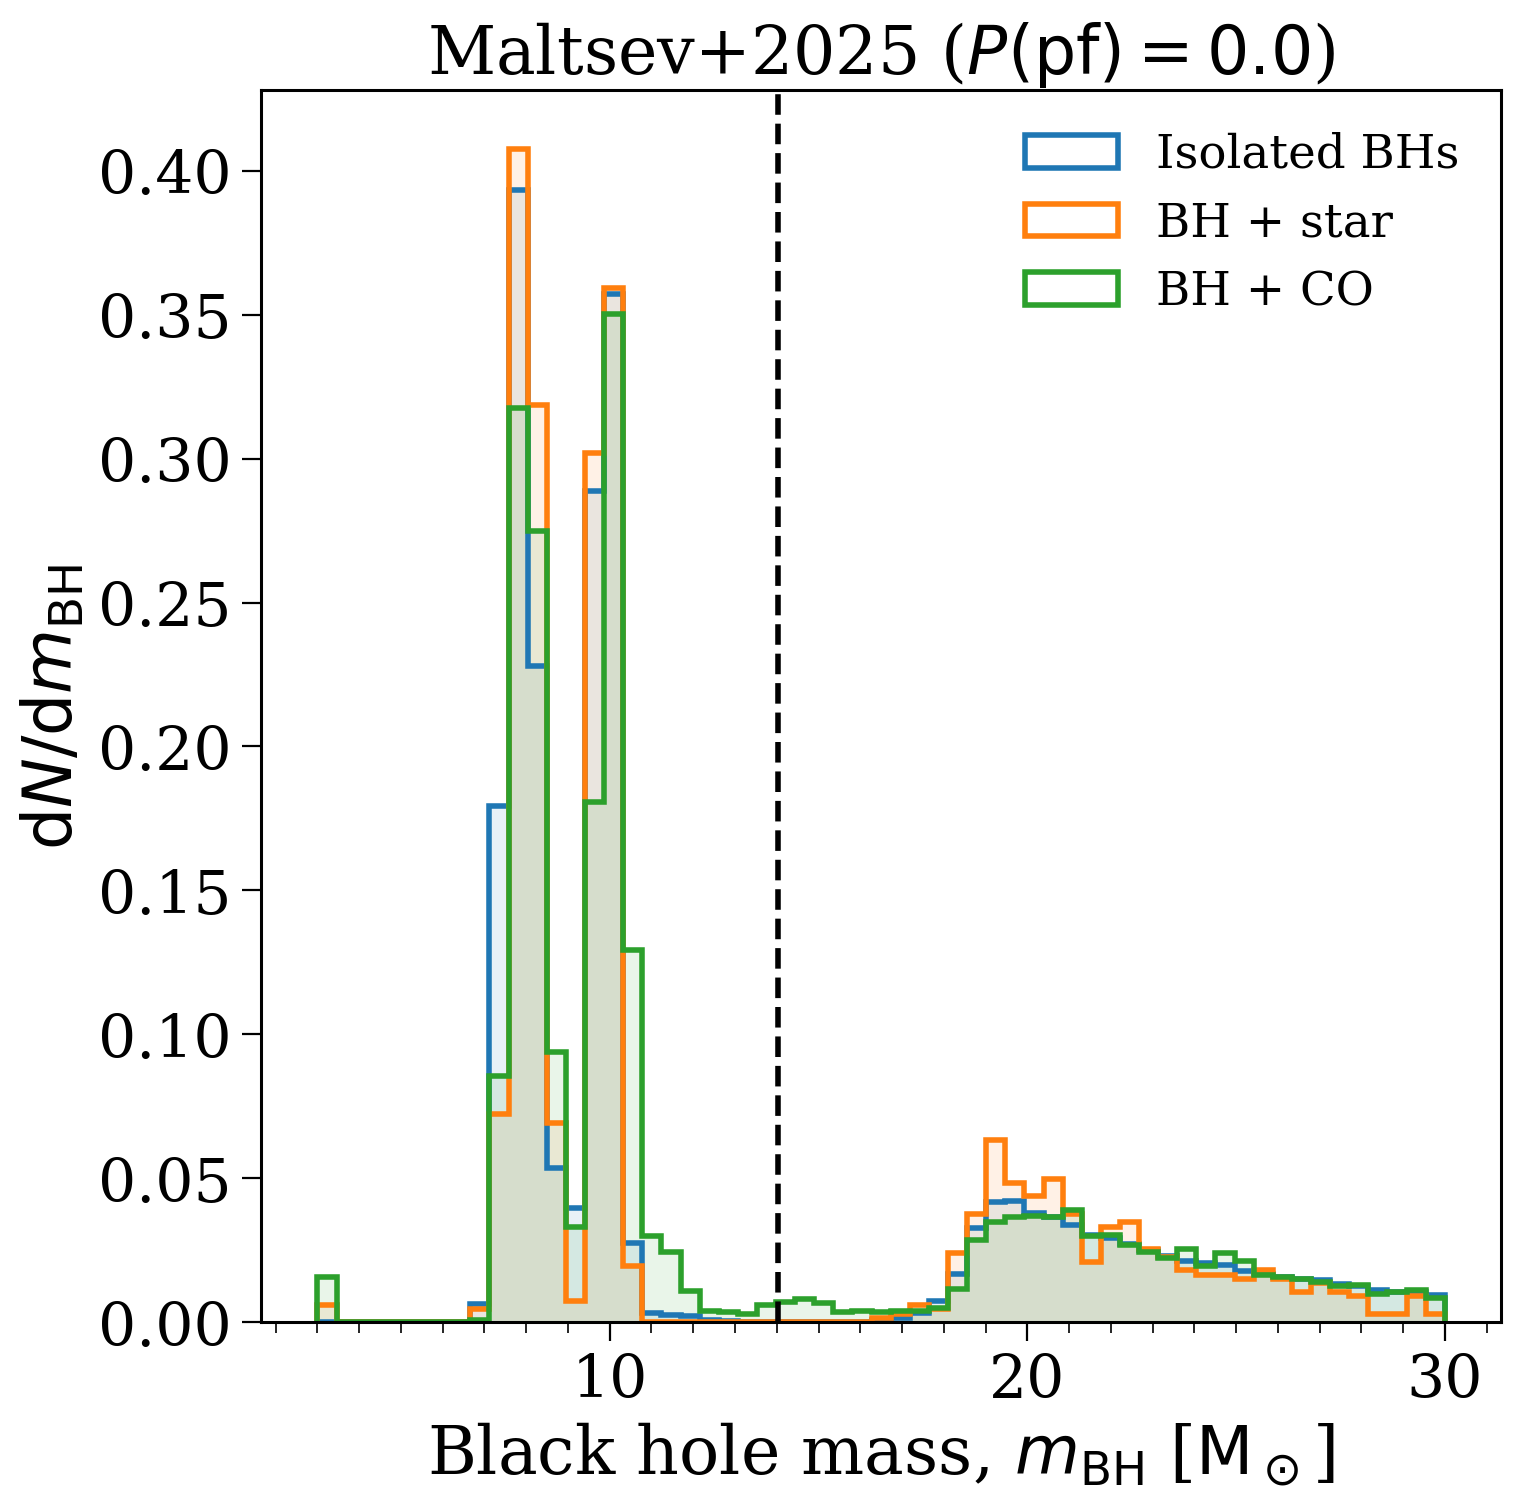

$P({\rm pf}) = 1.0$ 1558


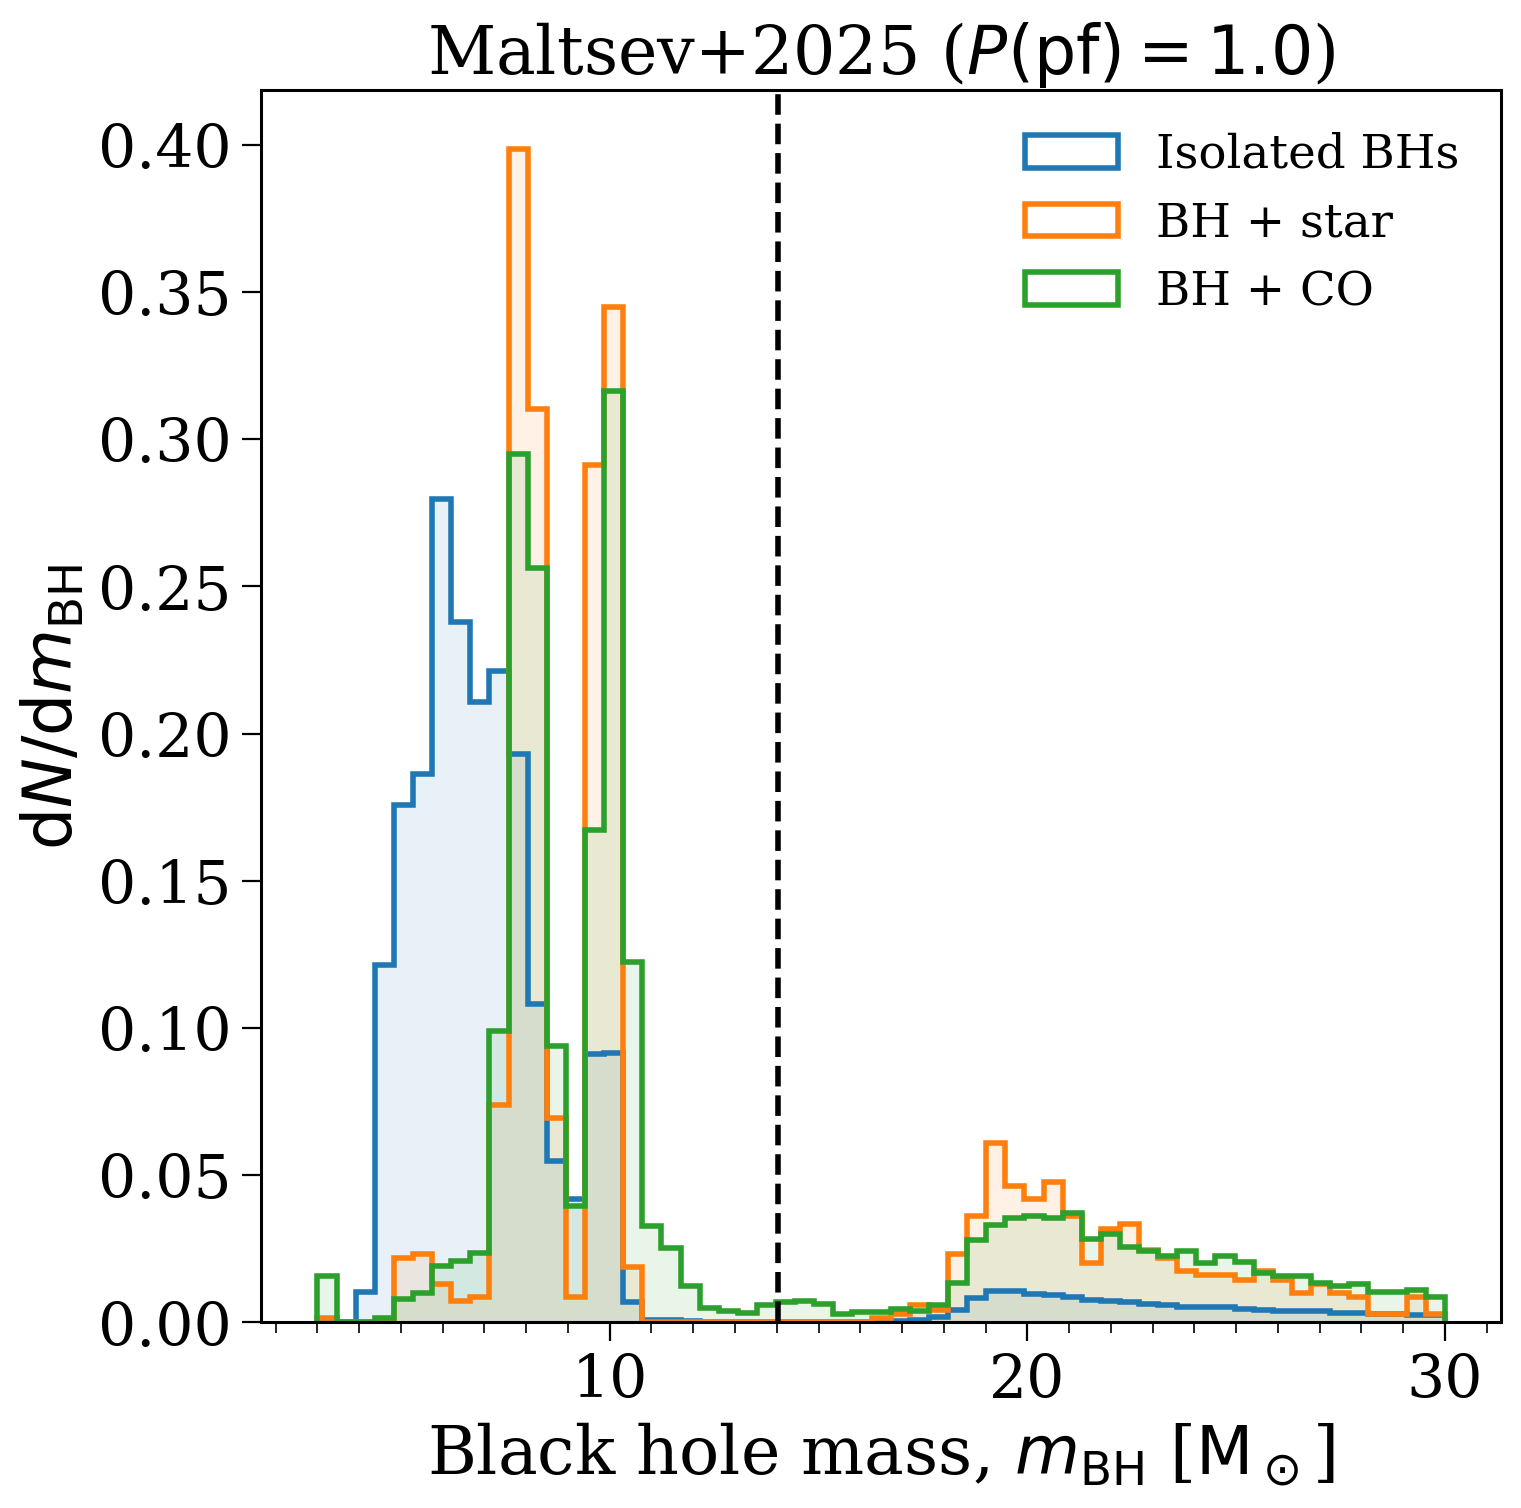

$\alpha_{\rm IMF} = -1.9$ 8833


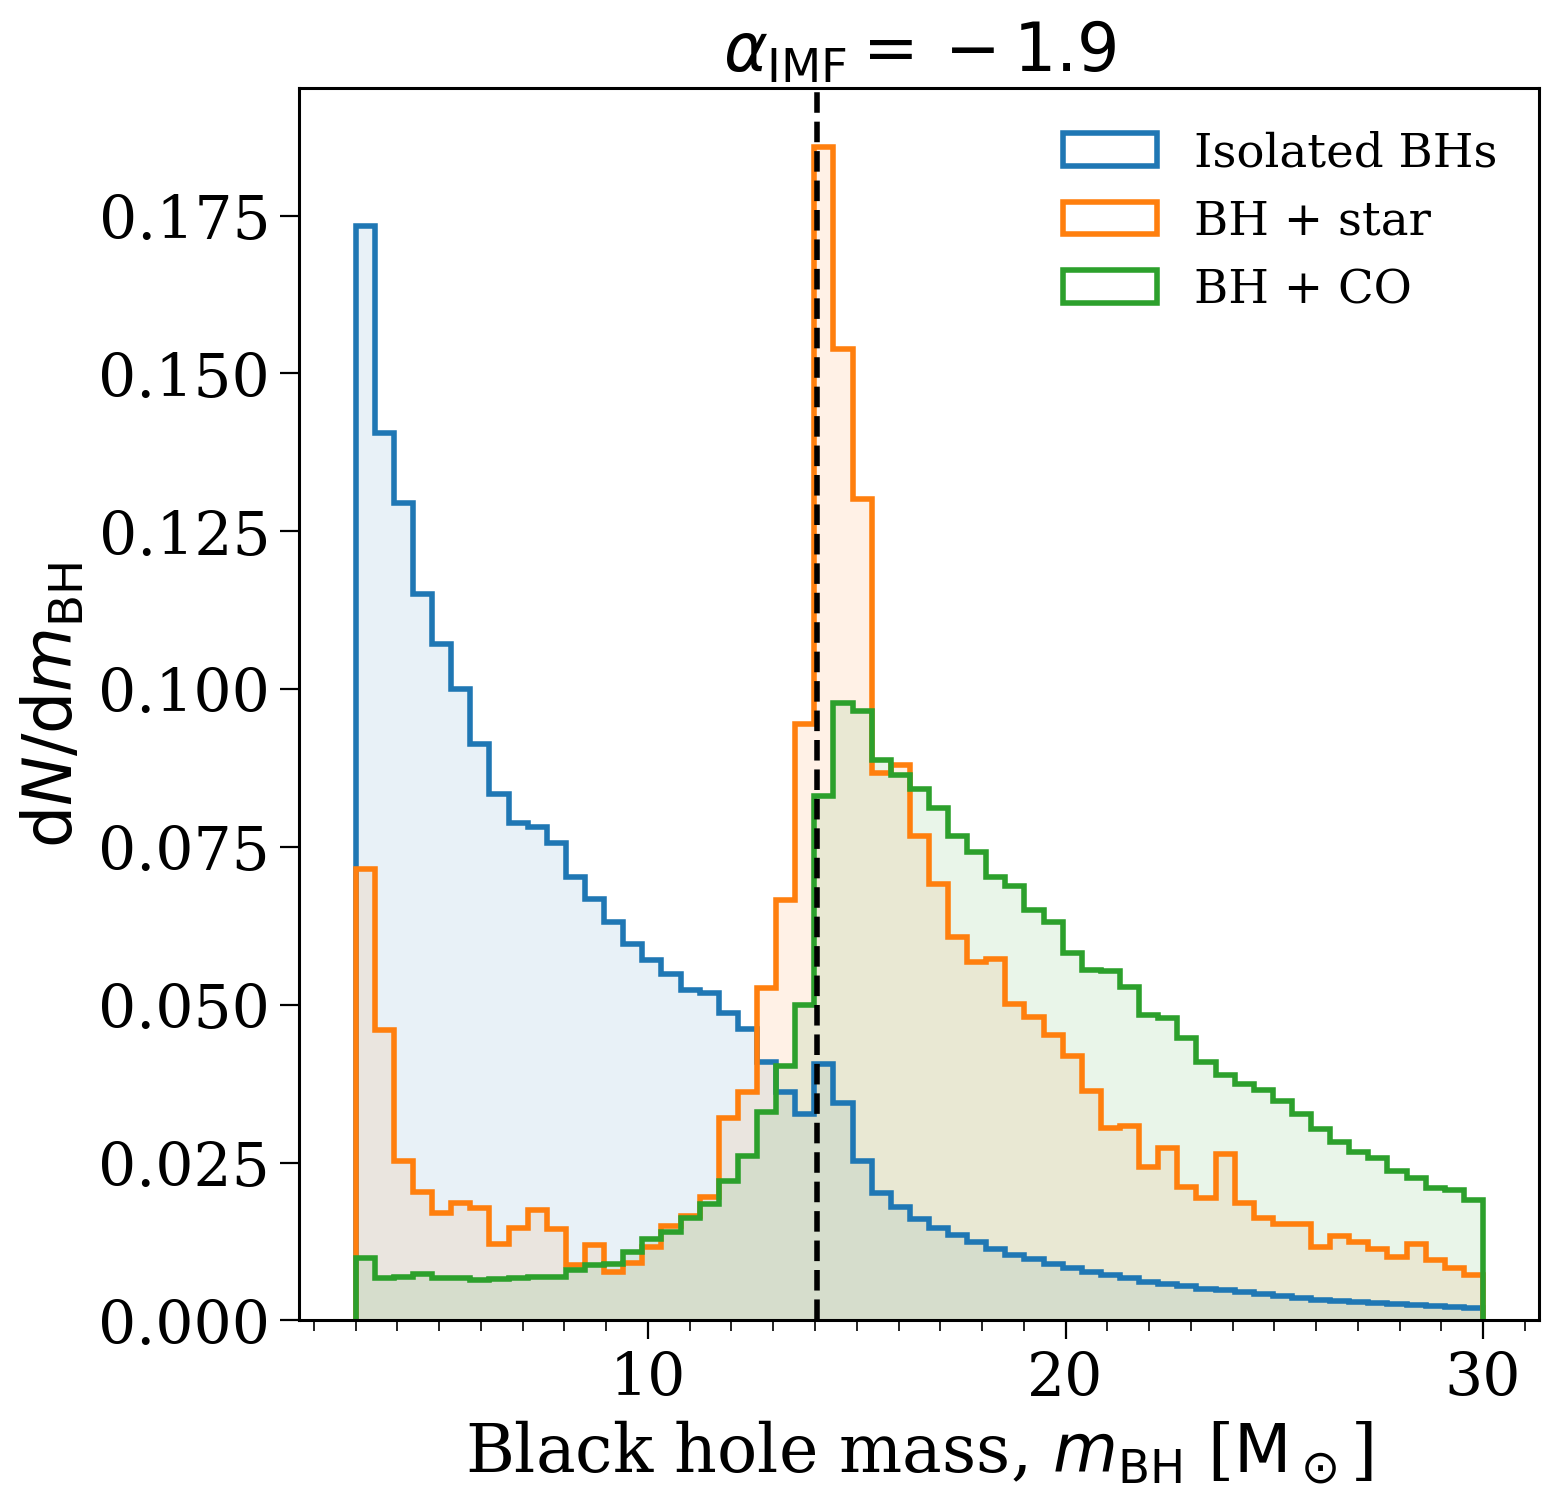

$\alpha_{\rm IMF} = -2.7$ 252


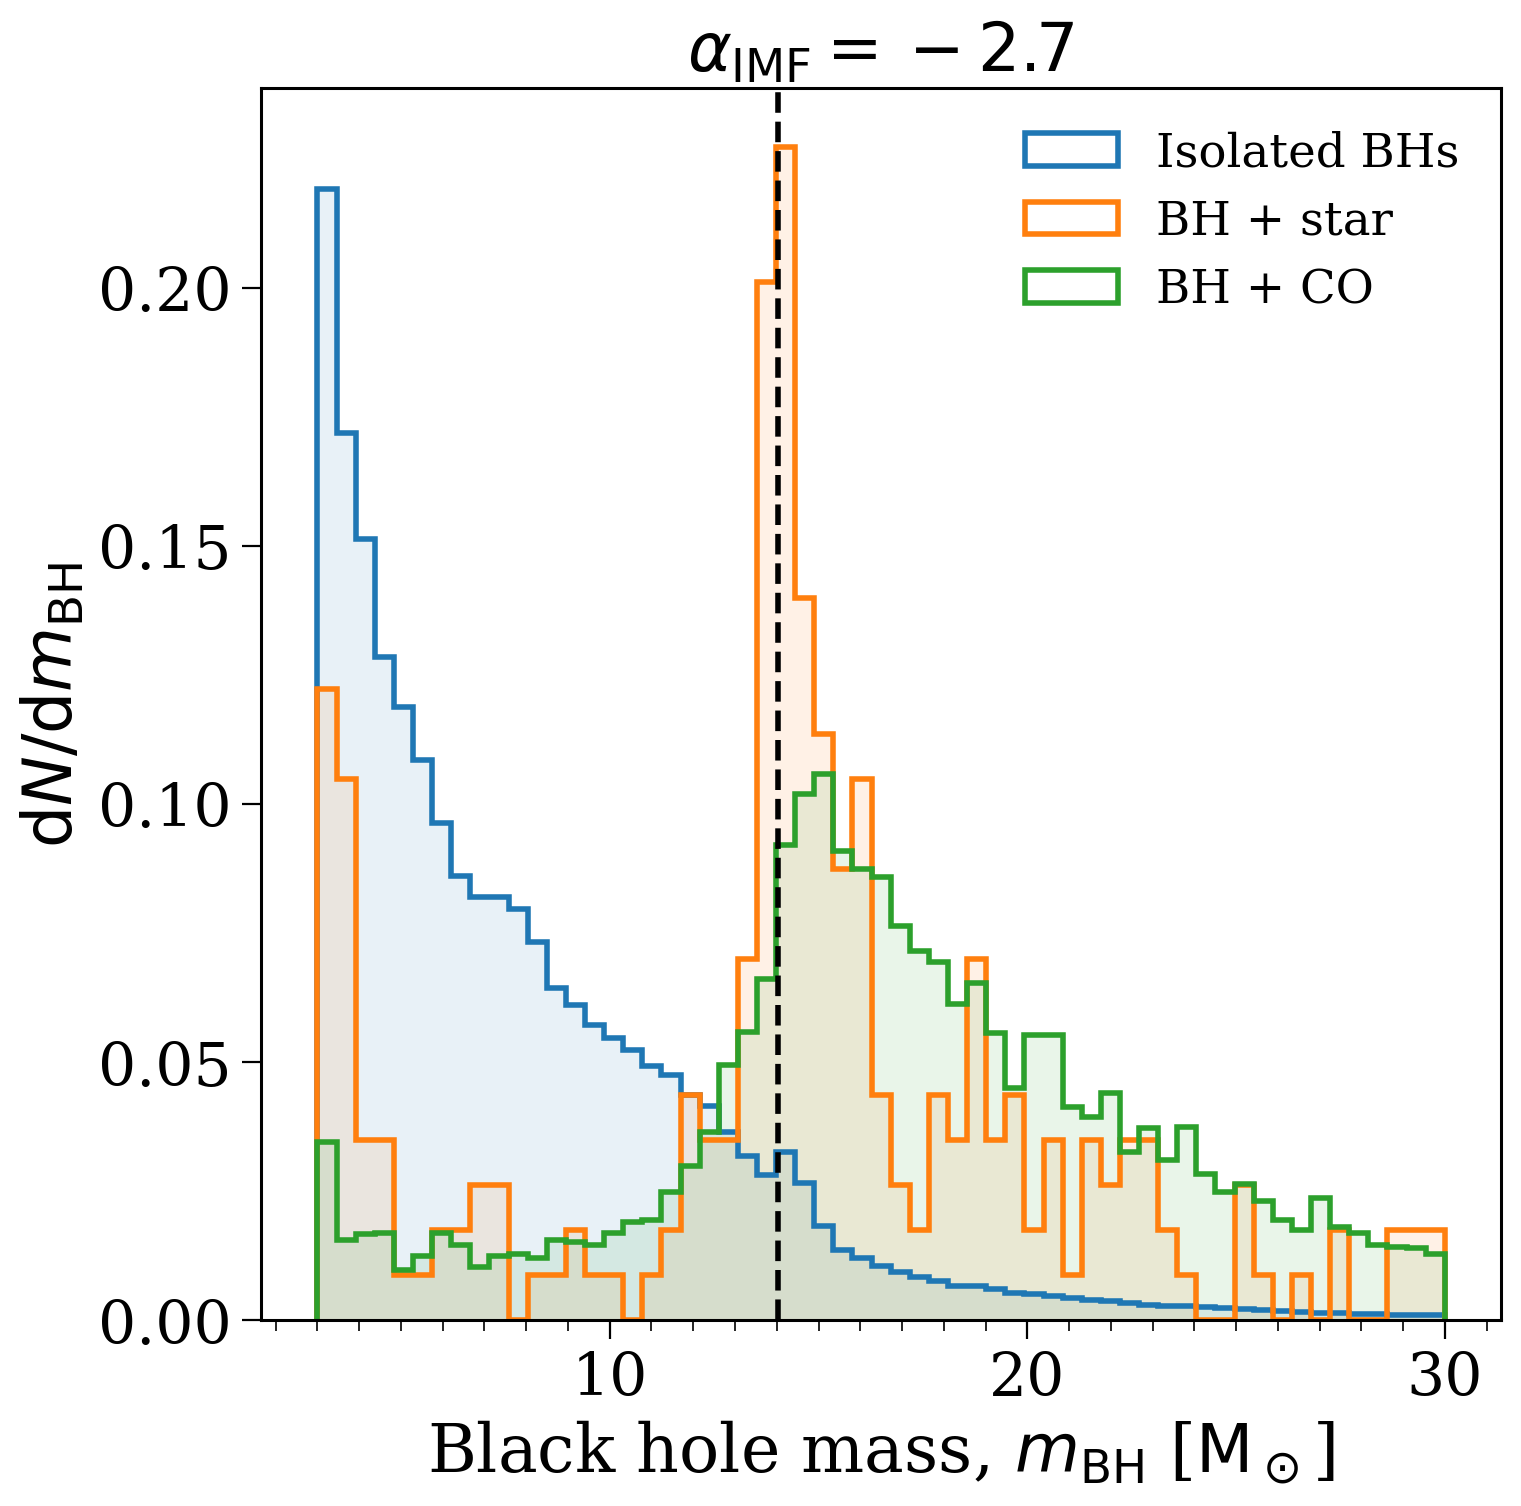

$\kappa = -1.0$ 41738


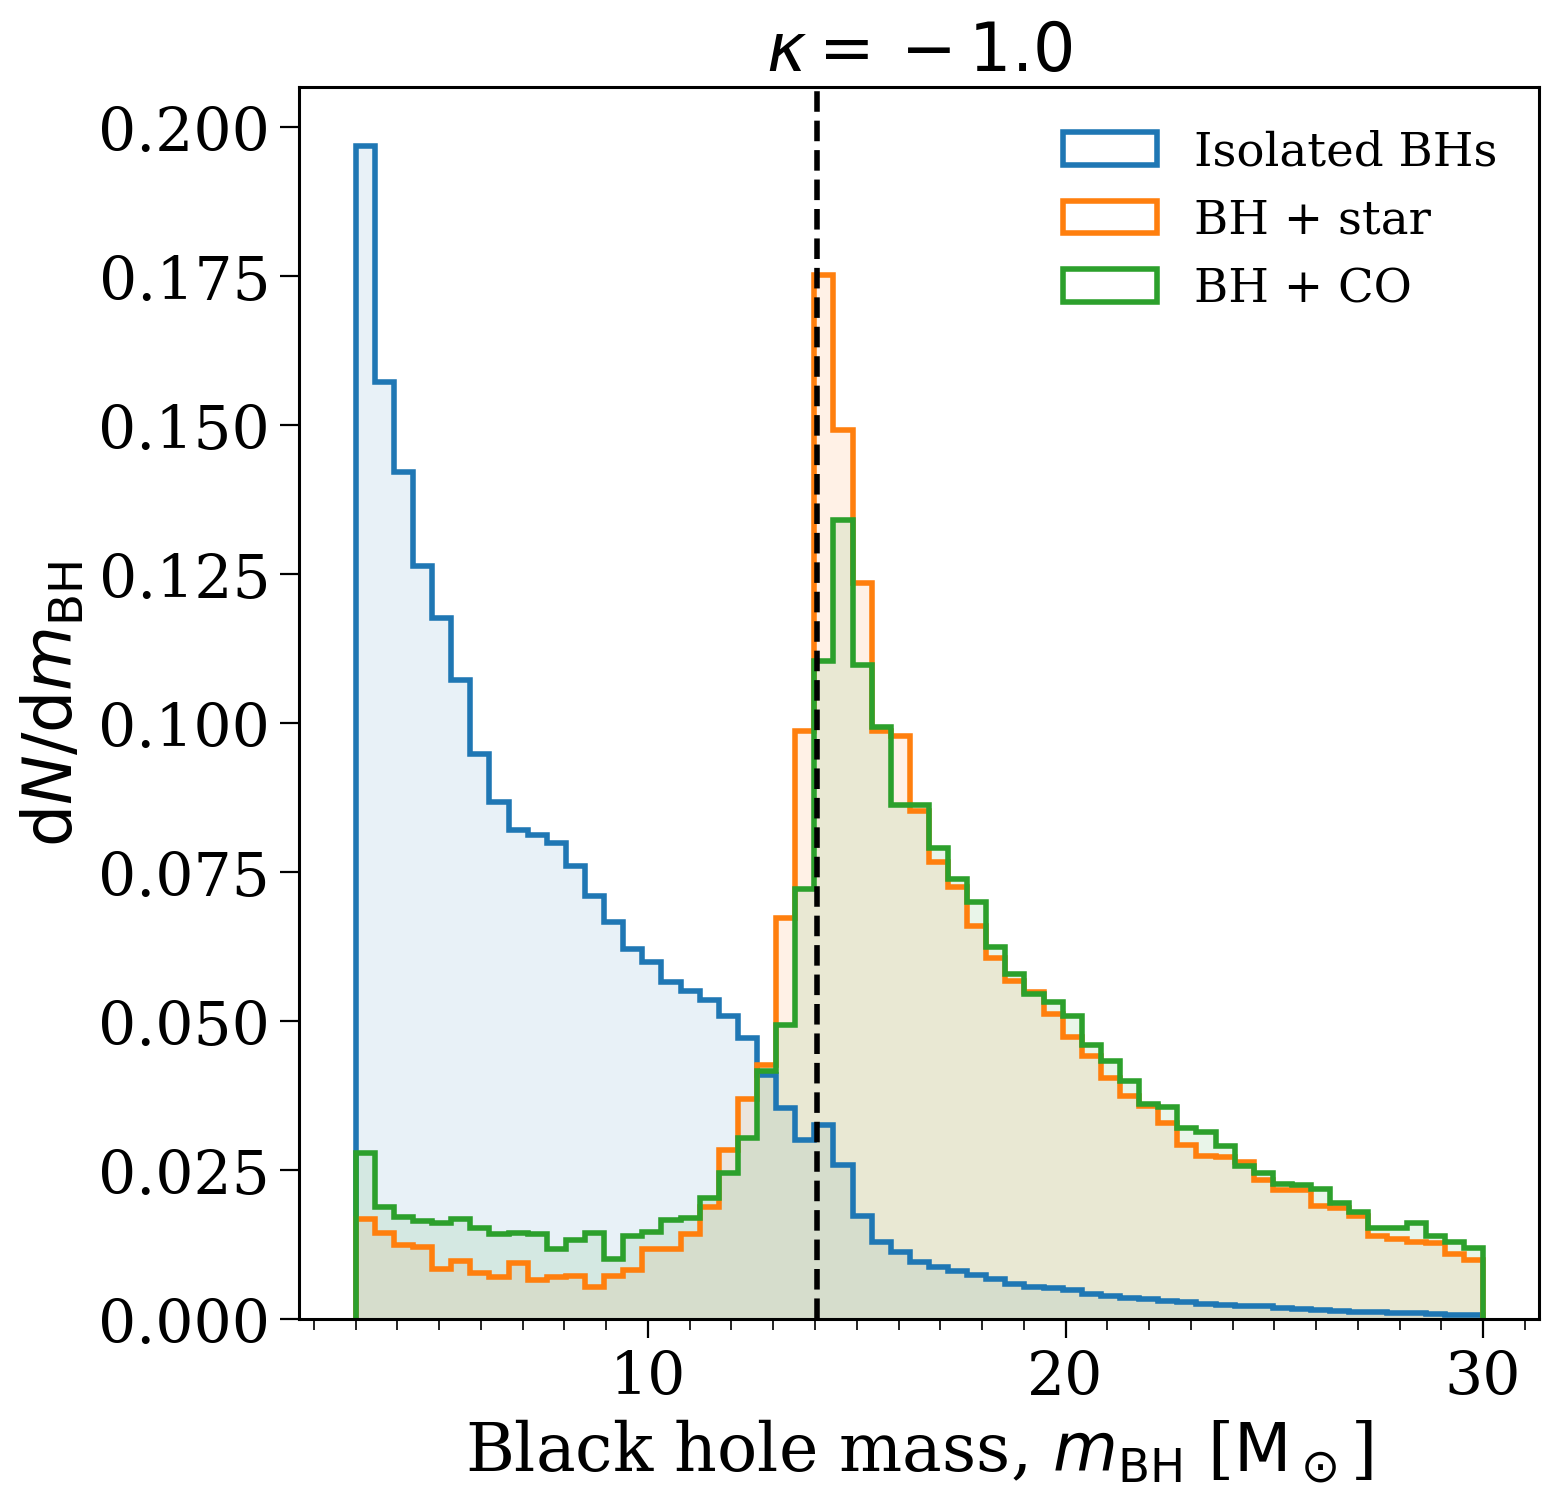

$\kappa = 1.0$ 46


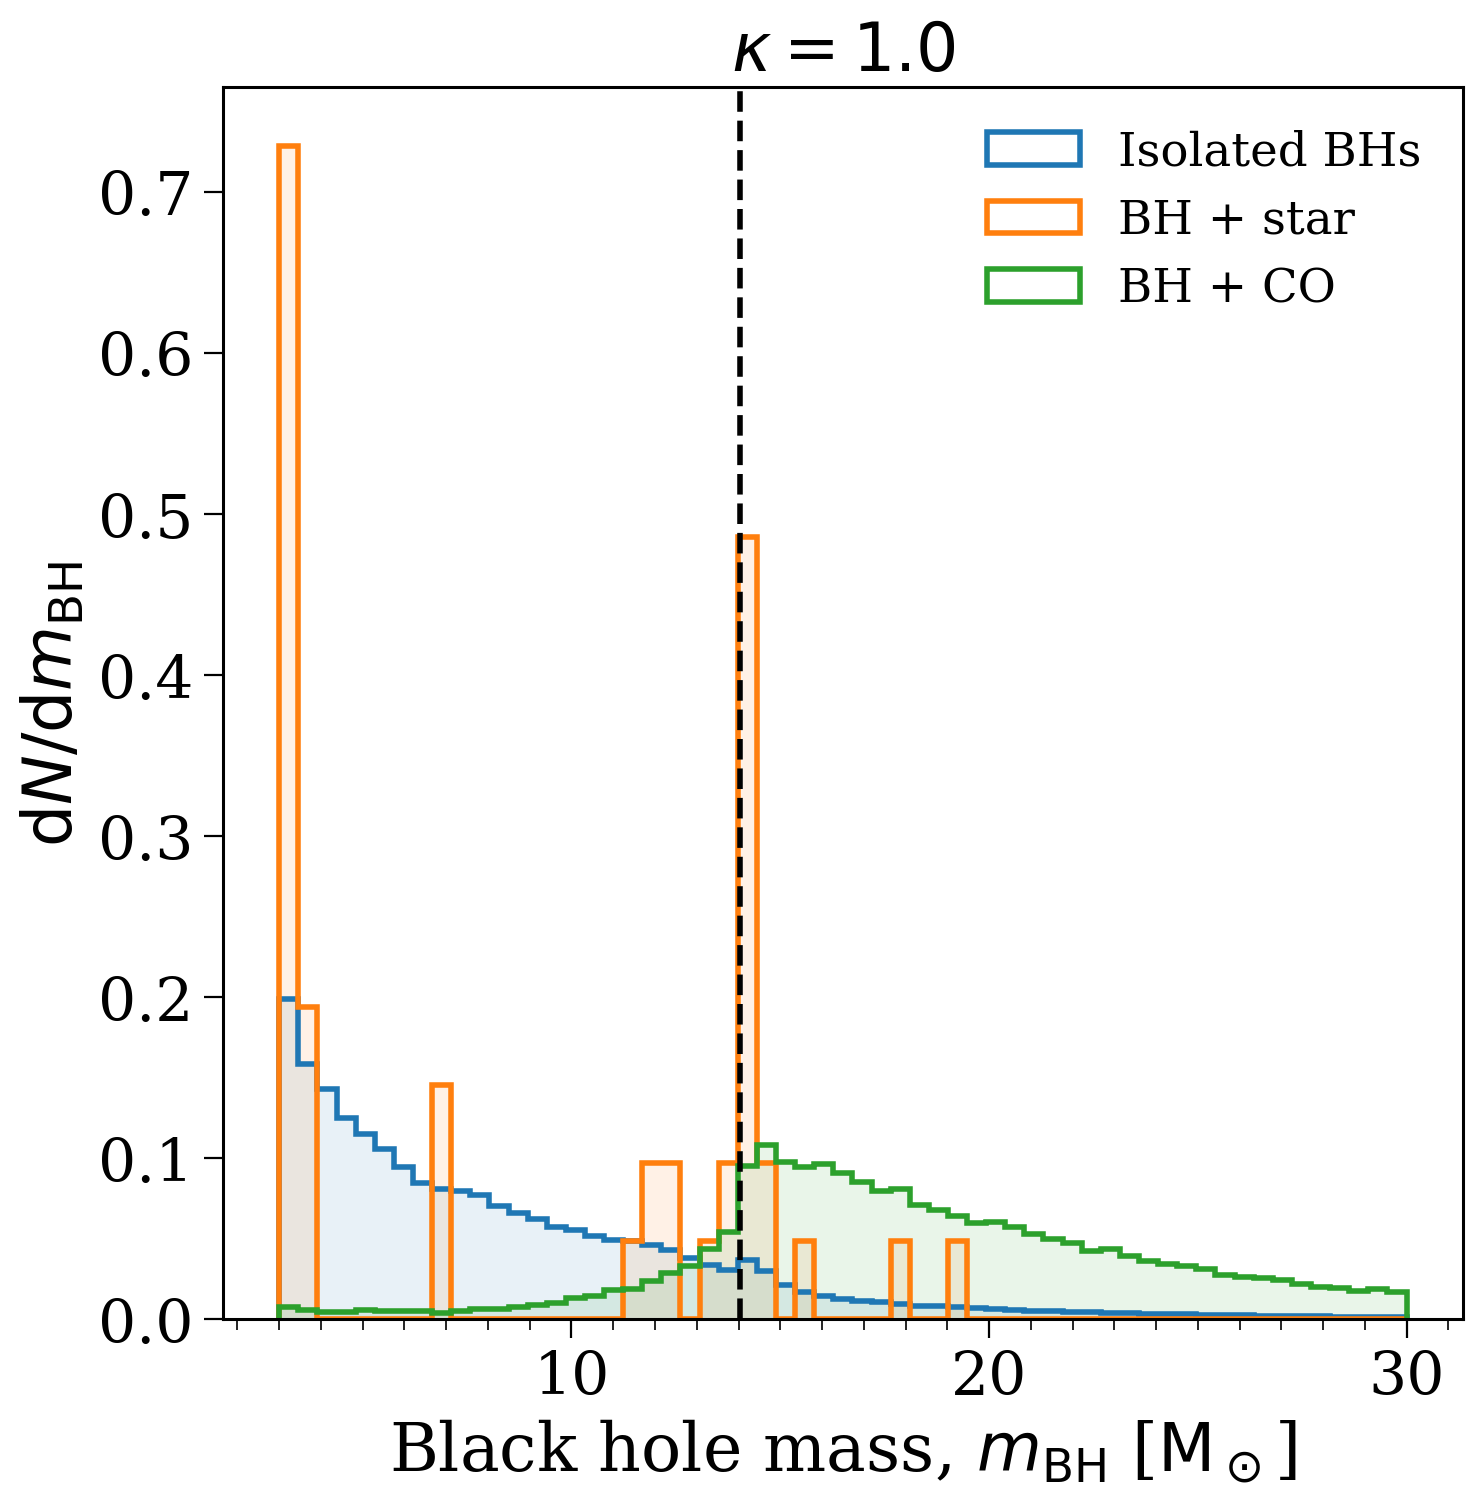

$q_{\rm min} = -1.0$ 123


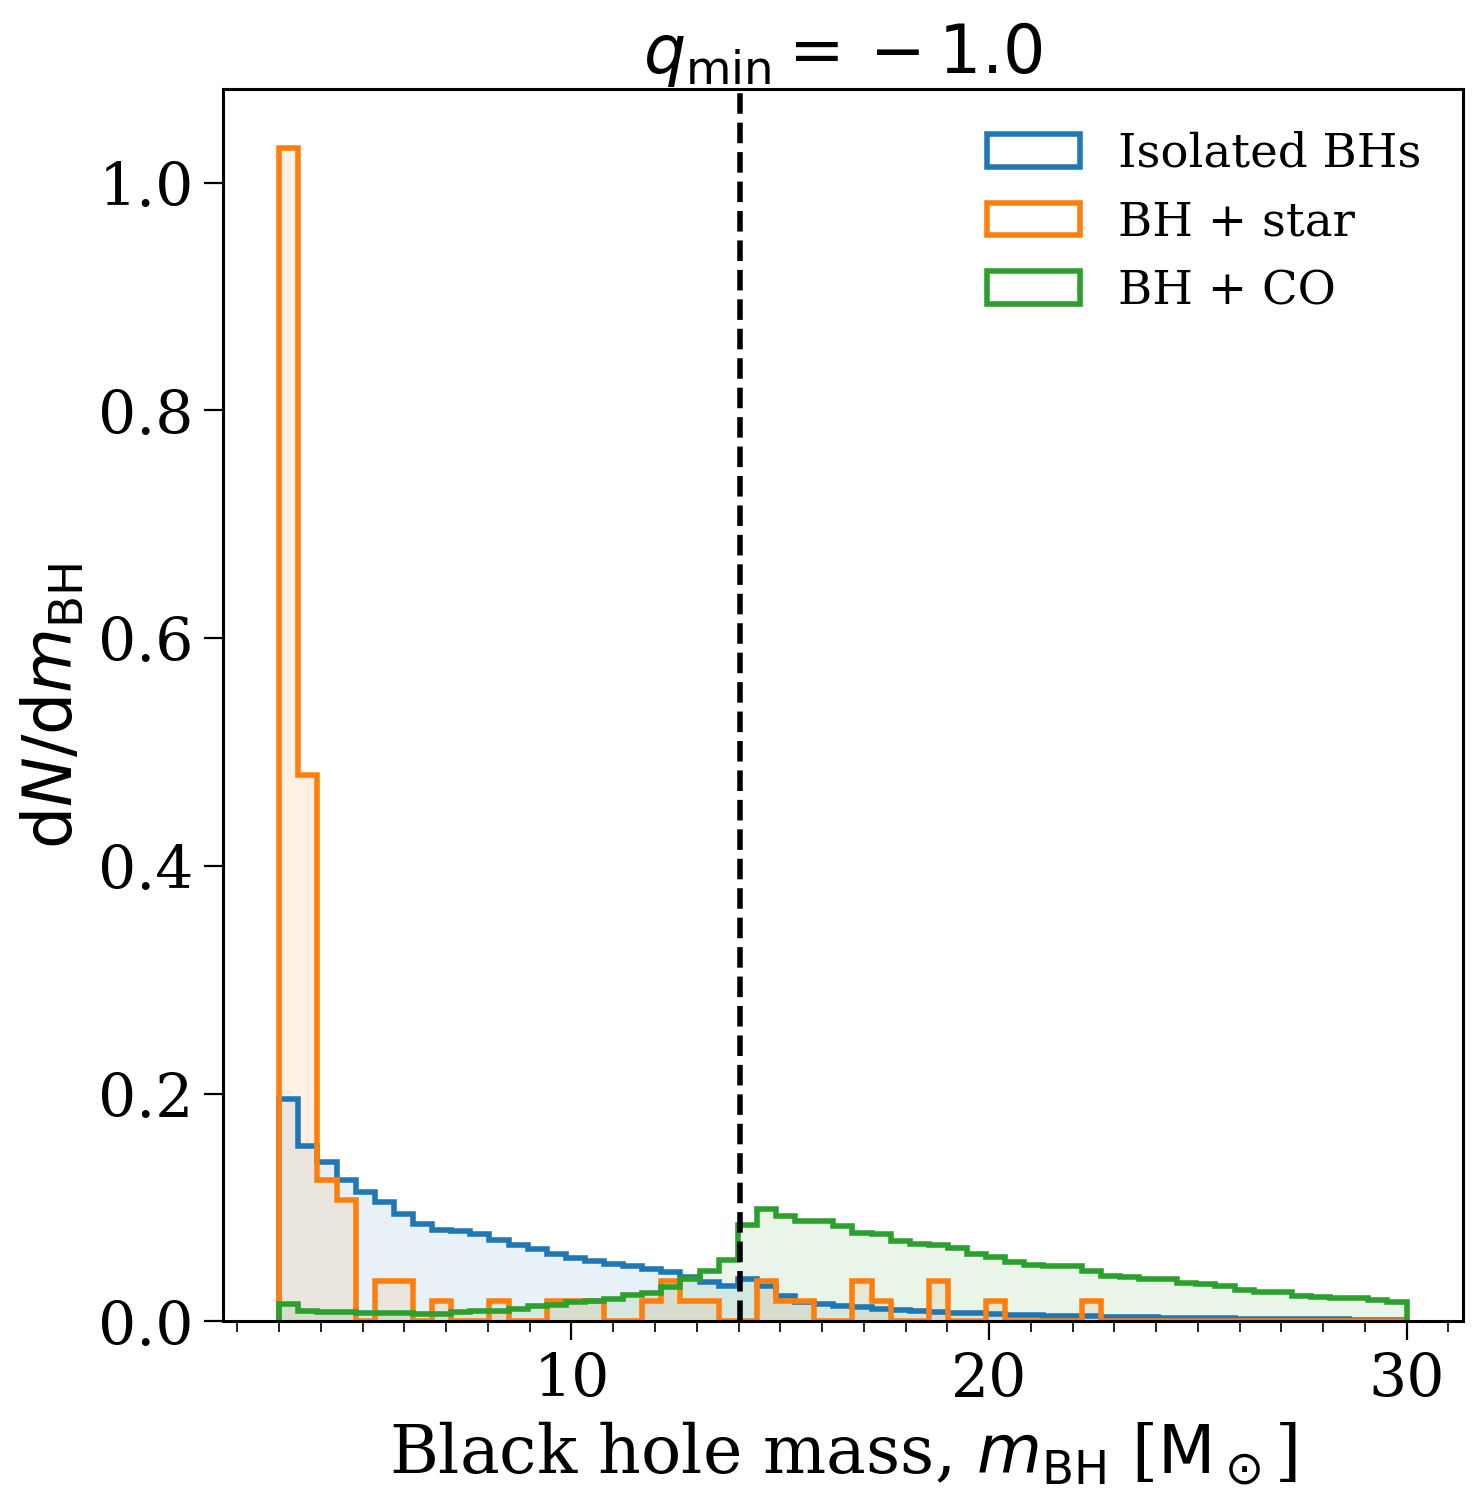

$\pi = 0.0$ 2091


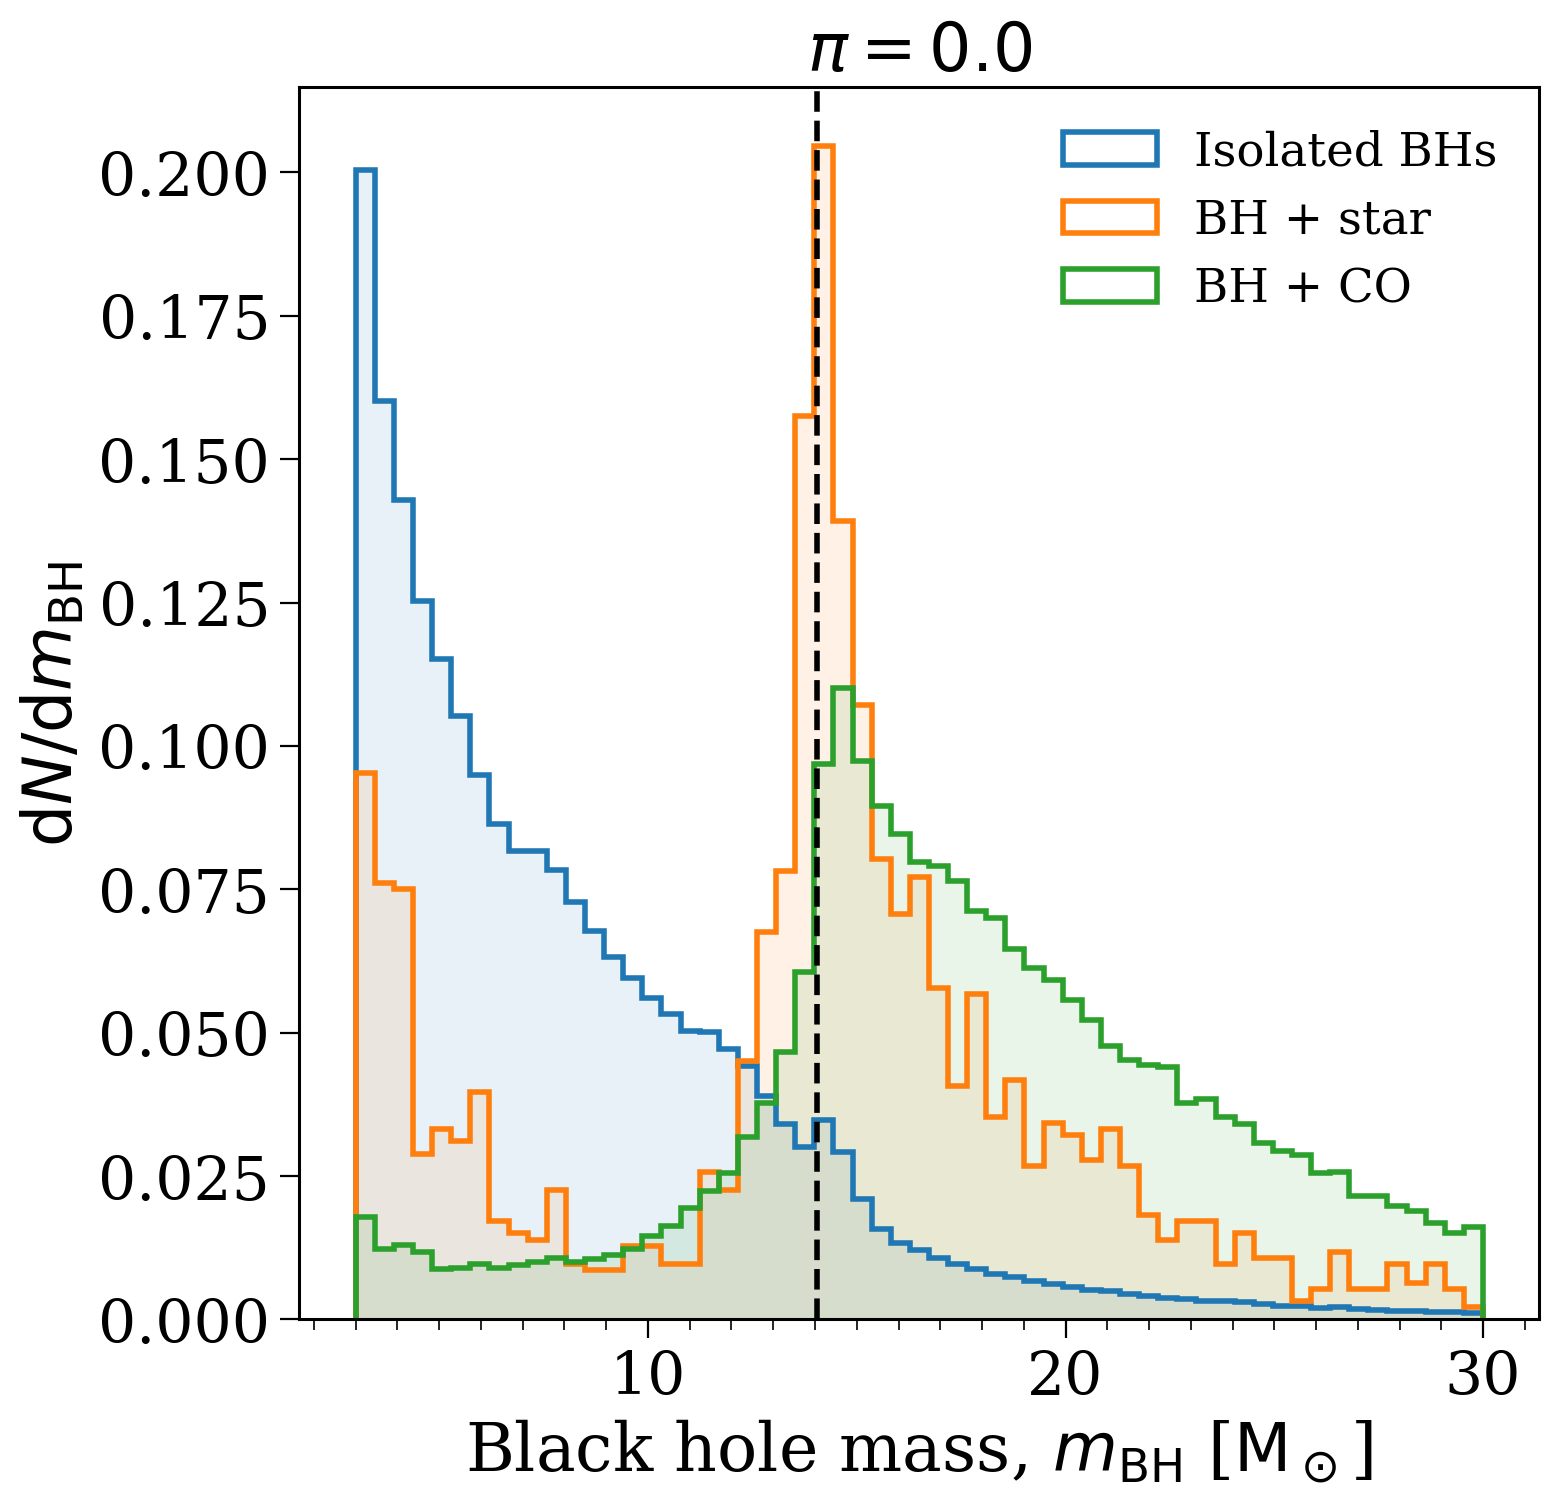

$\pi = -1.0$ 1421


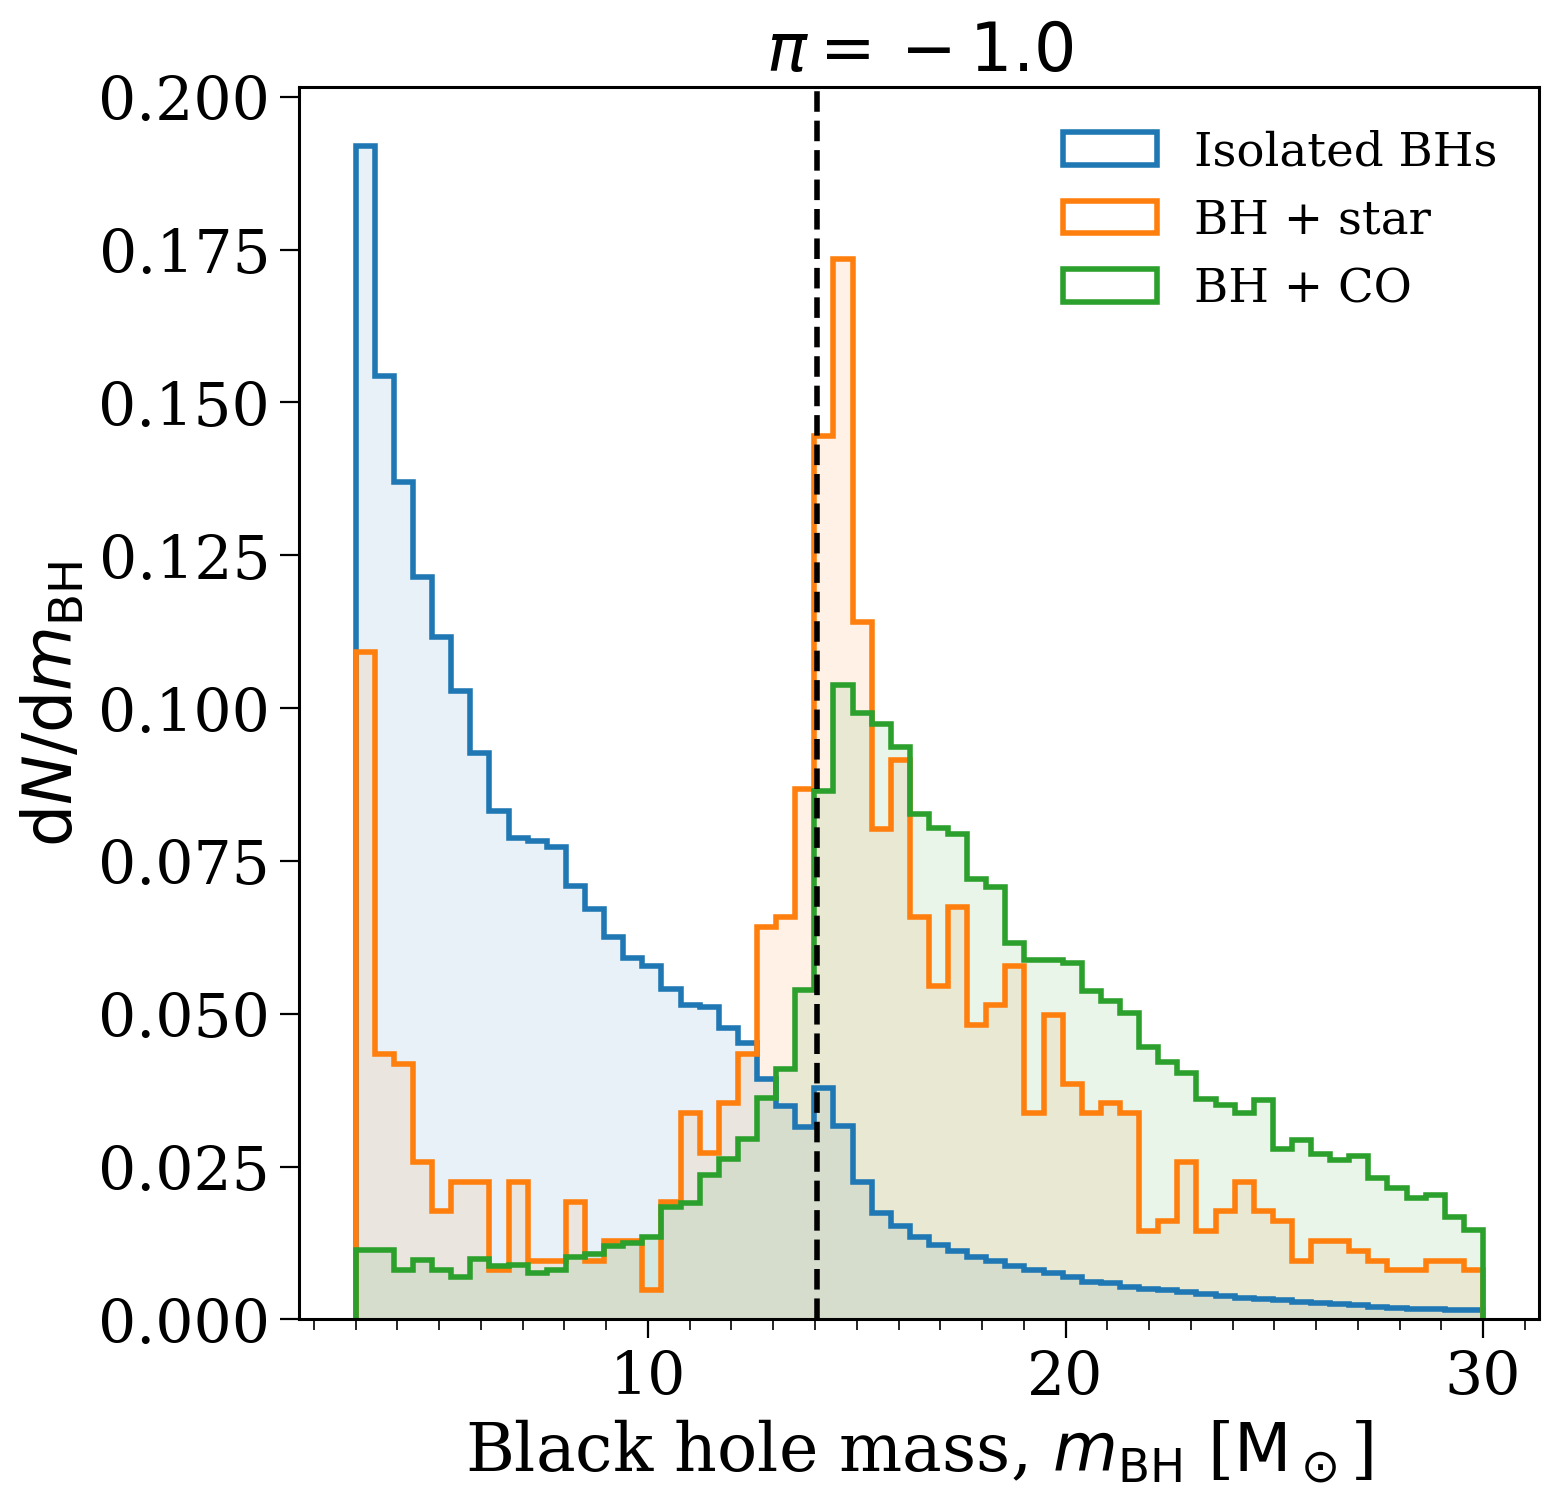

$P_{\rm orb, max} = 10^3\,{\rm days}$ 1654


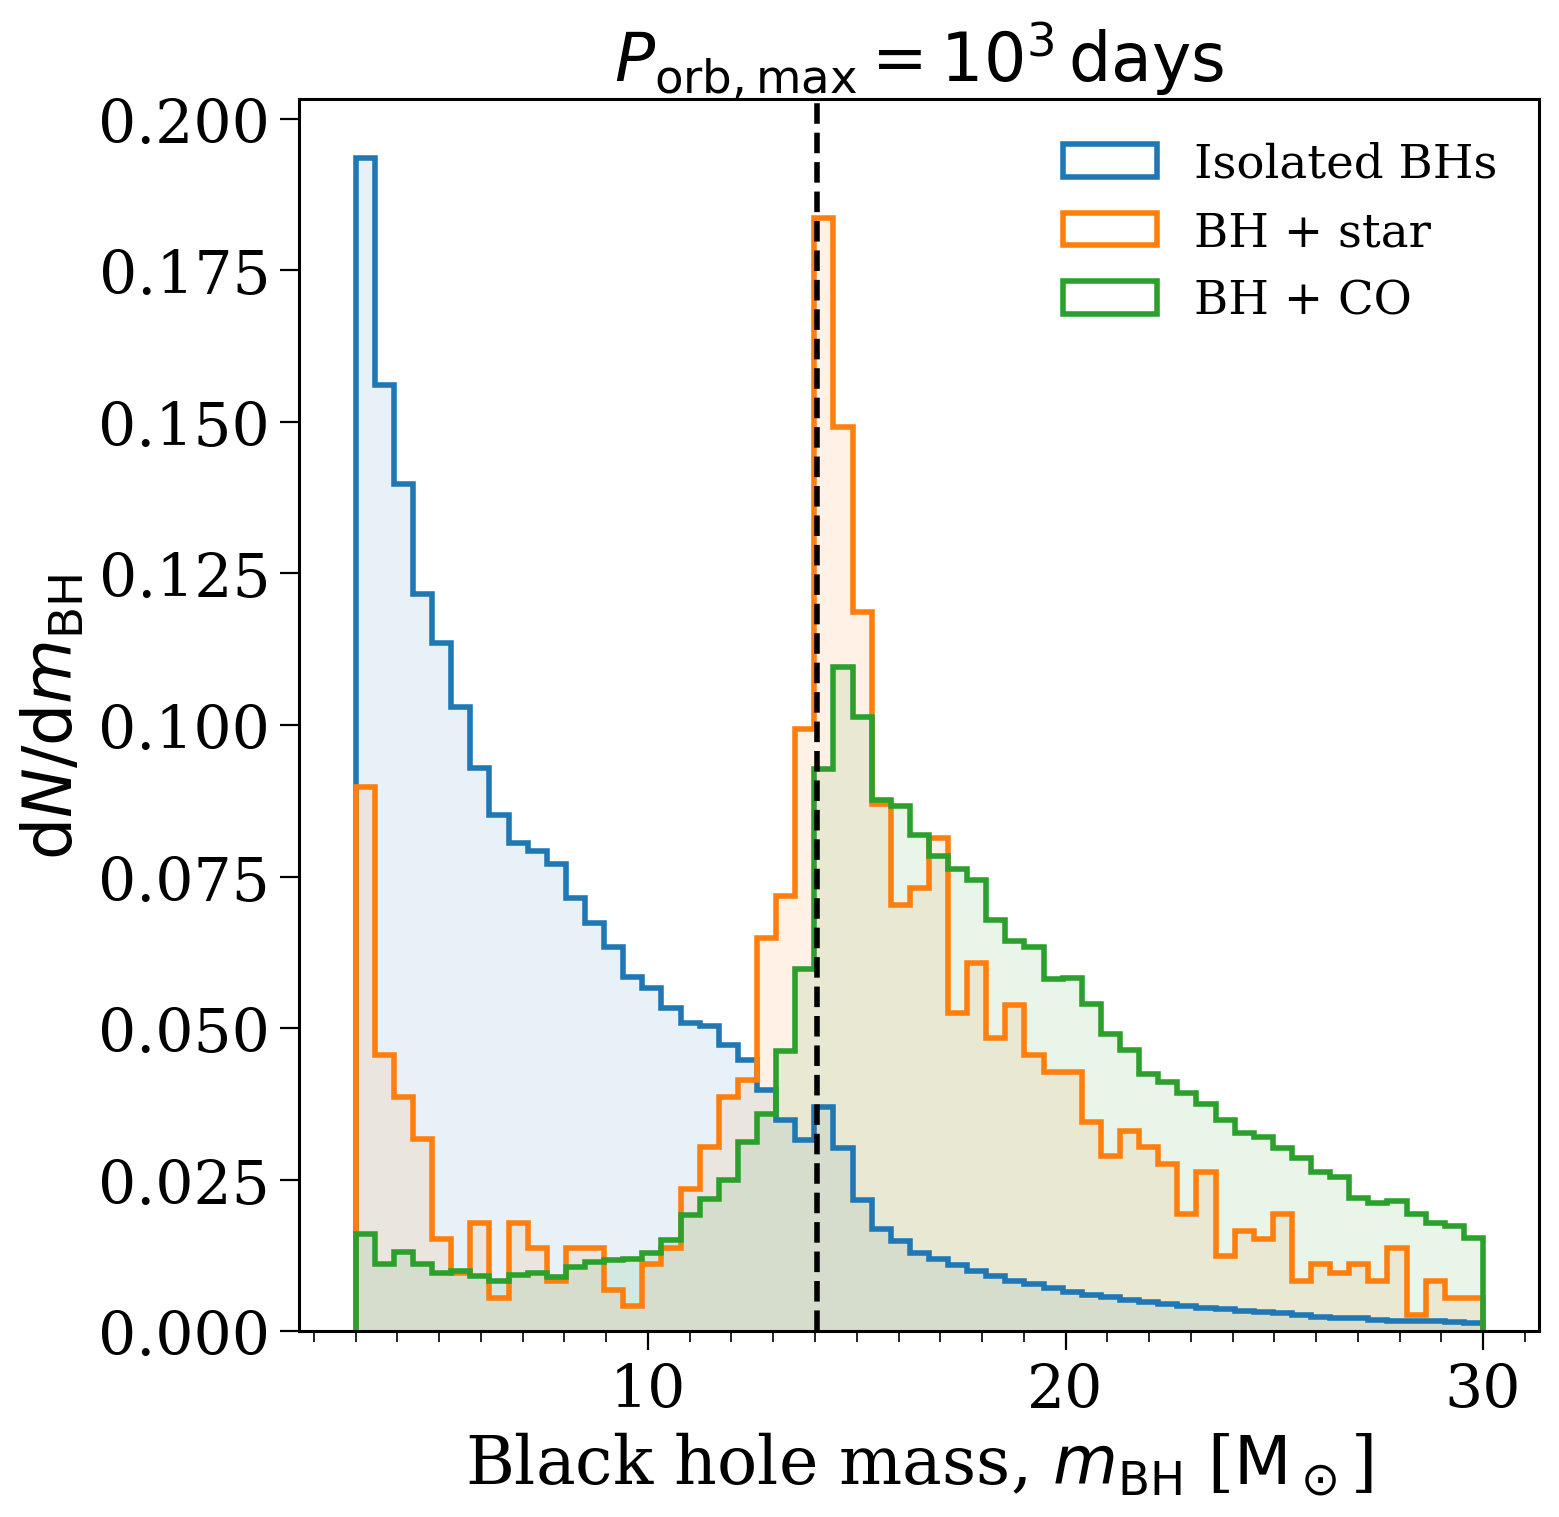

$\beta = 0.0$ 133


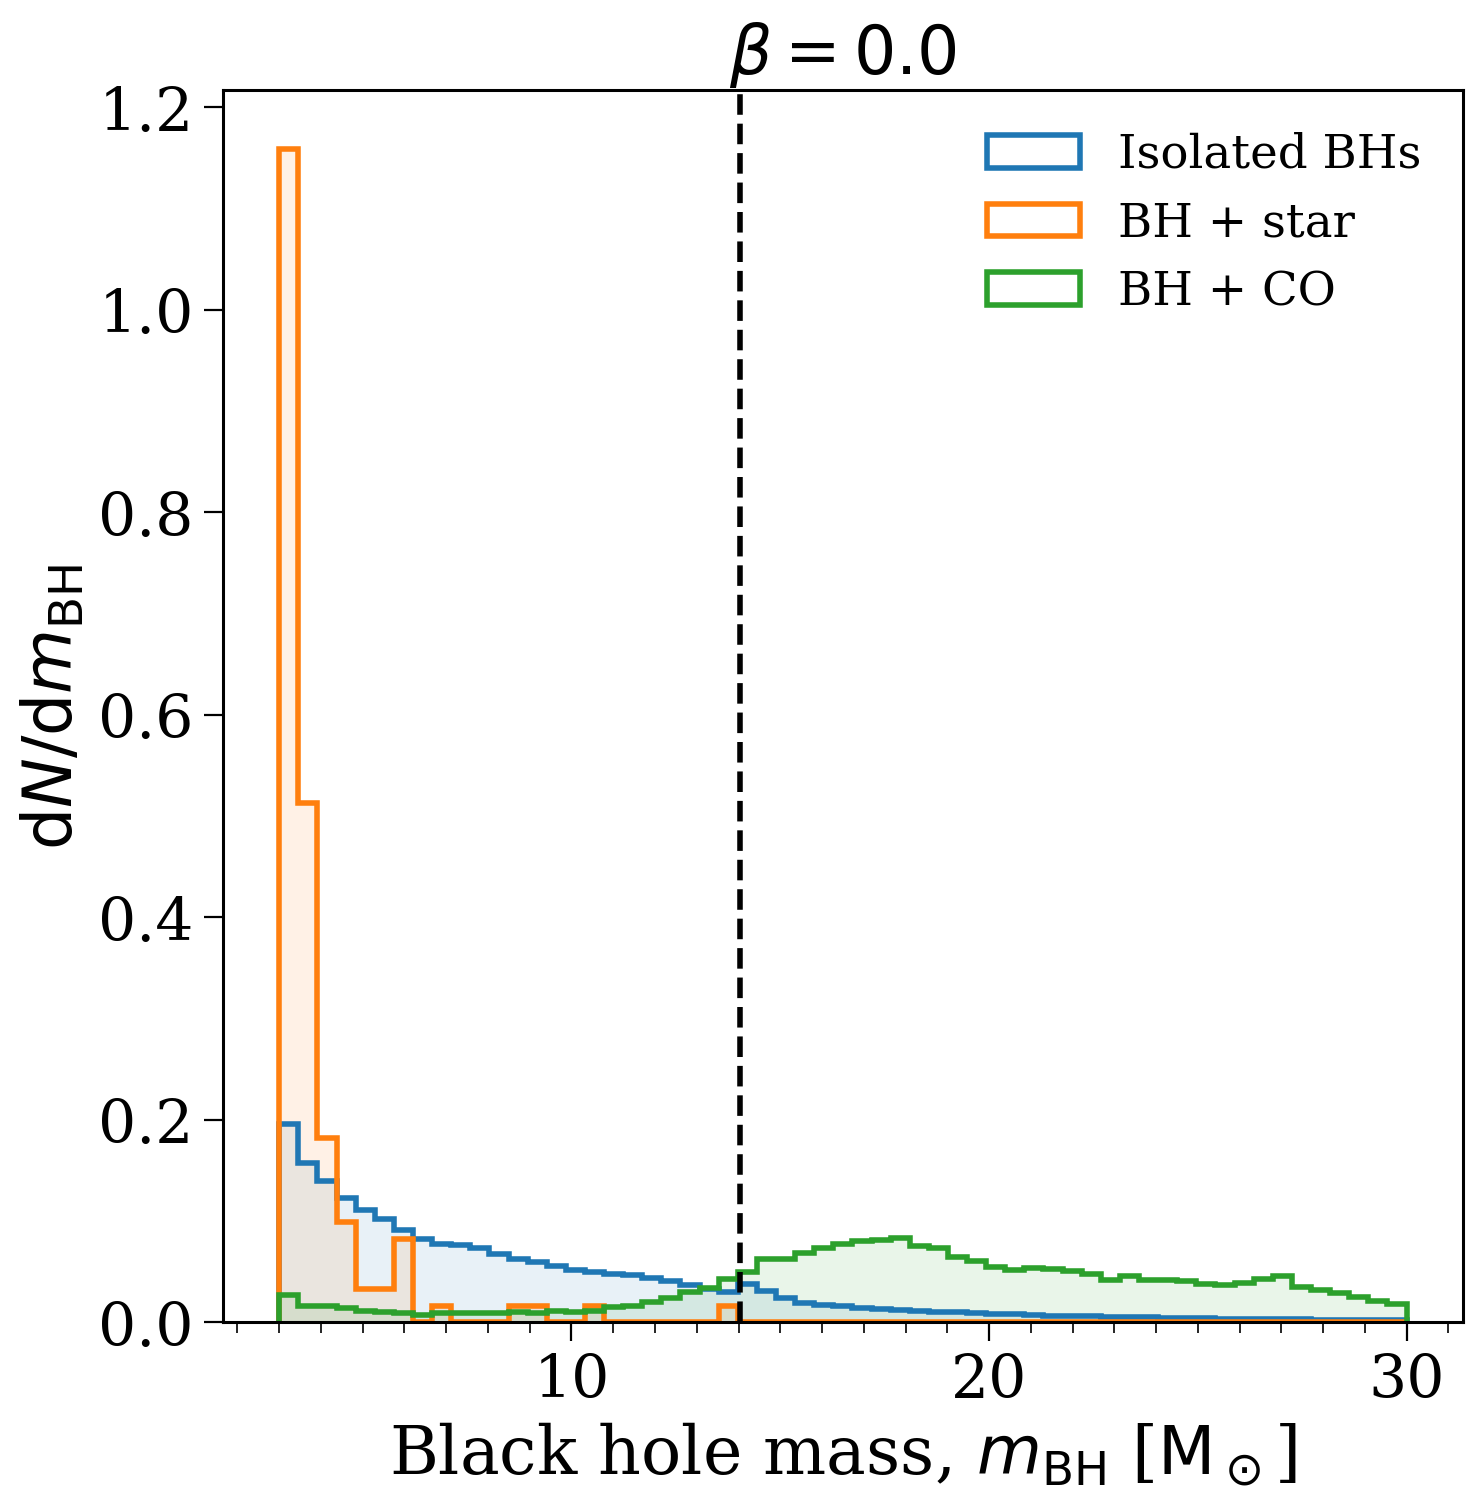

$\beta = 0.5$ 1714


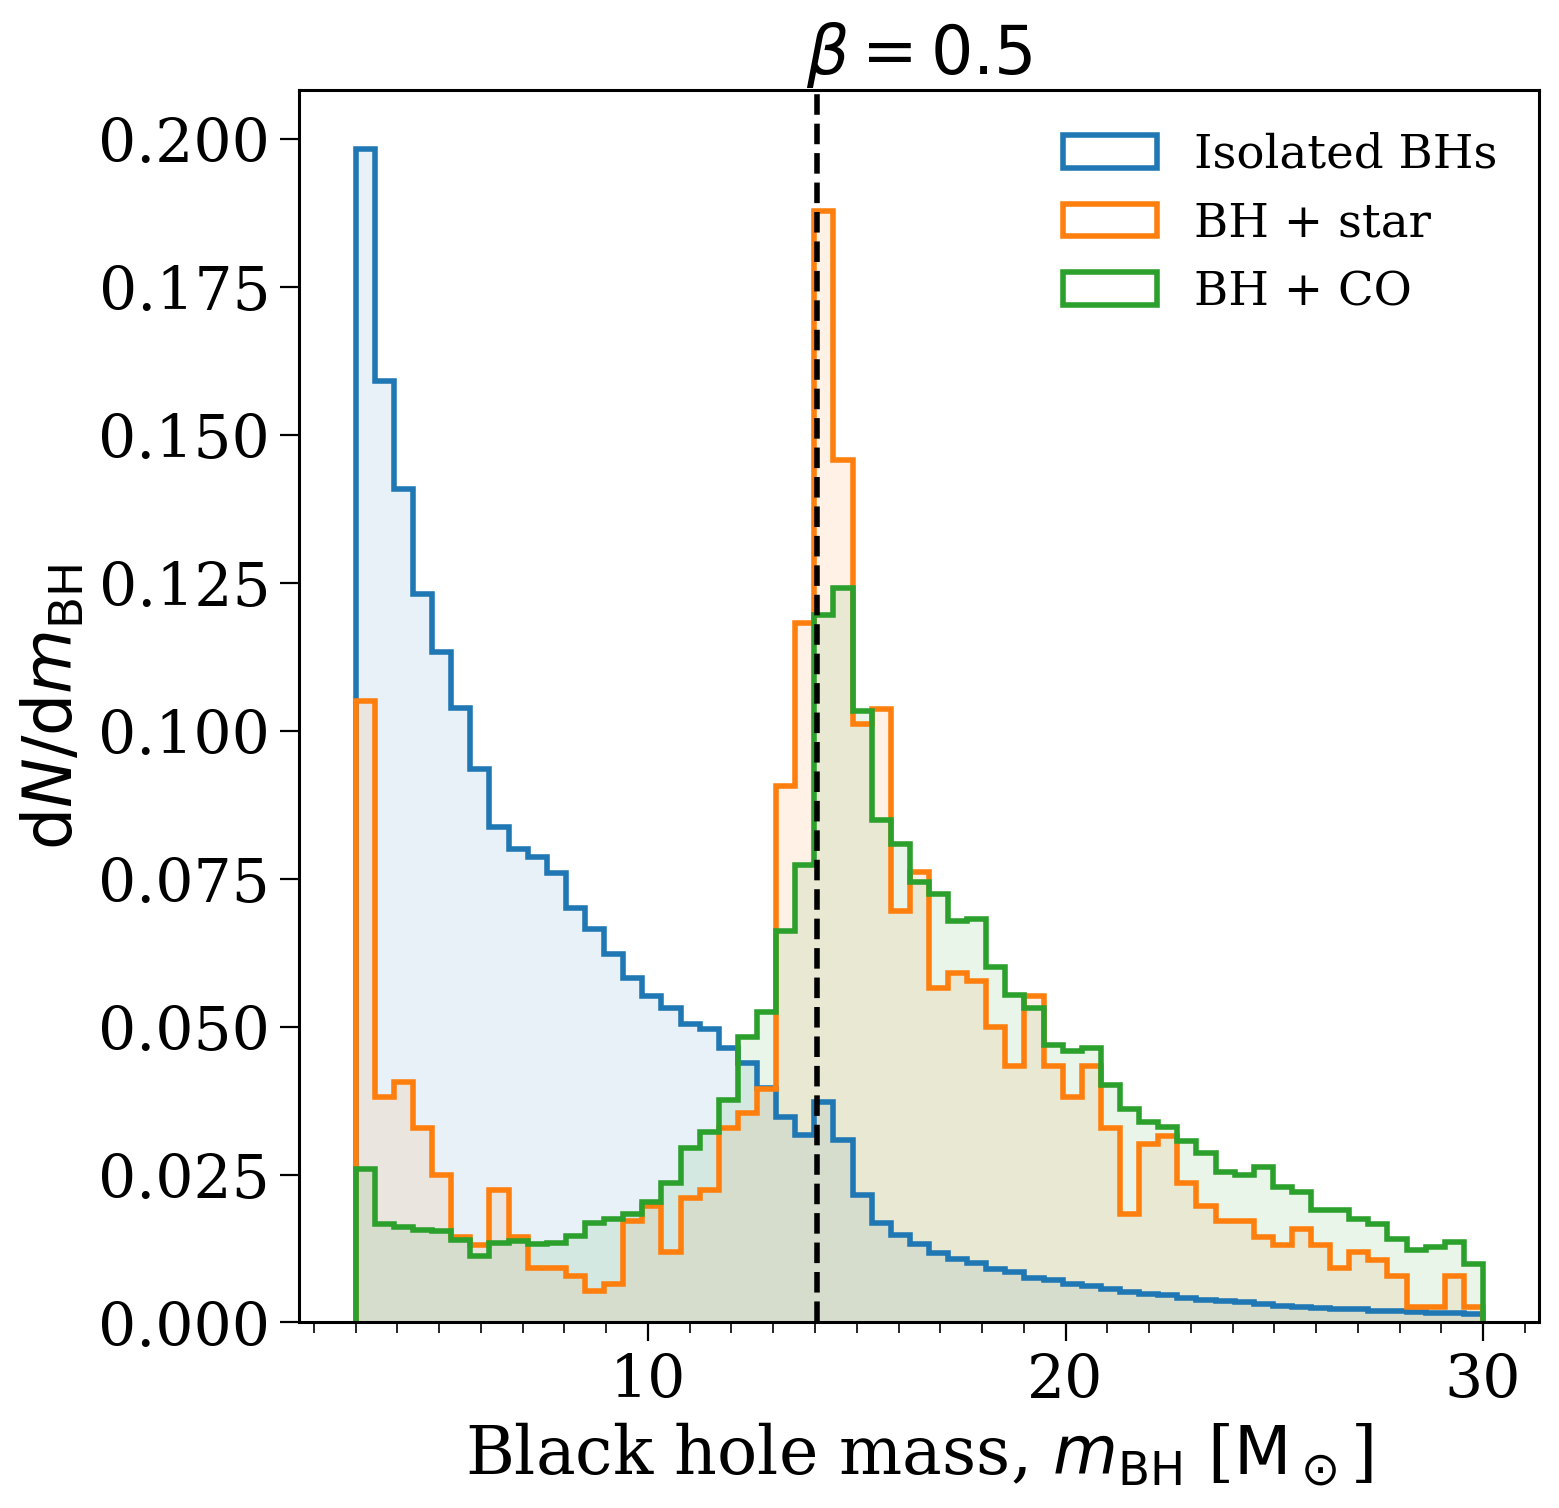

$\beta = 1.0$ 1702


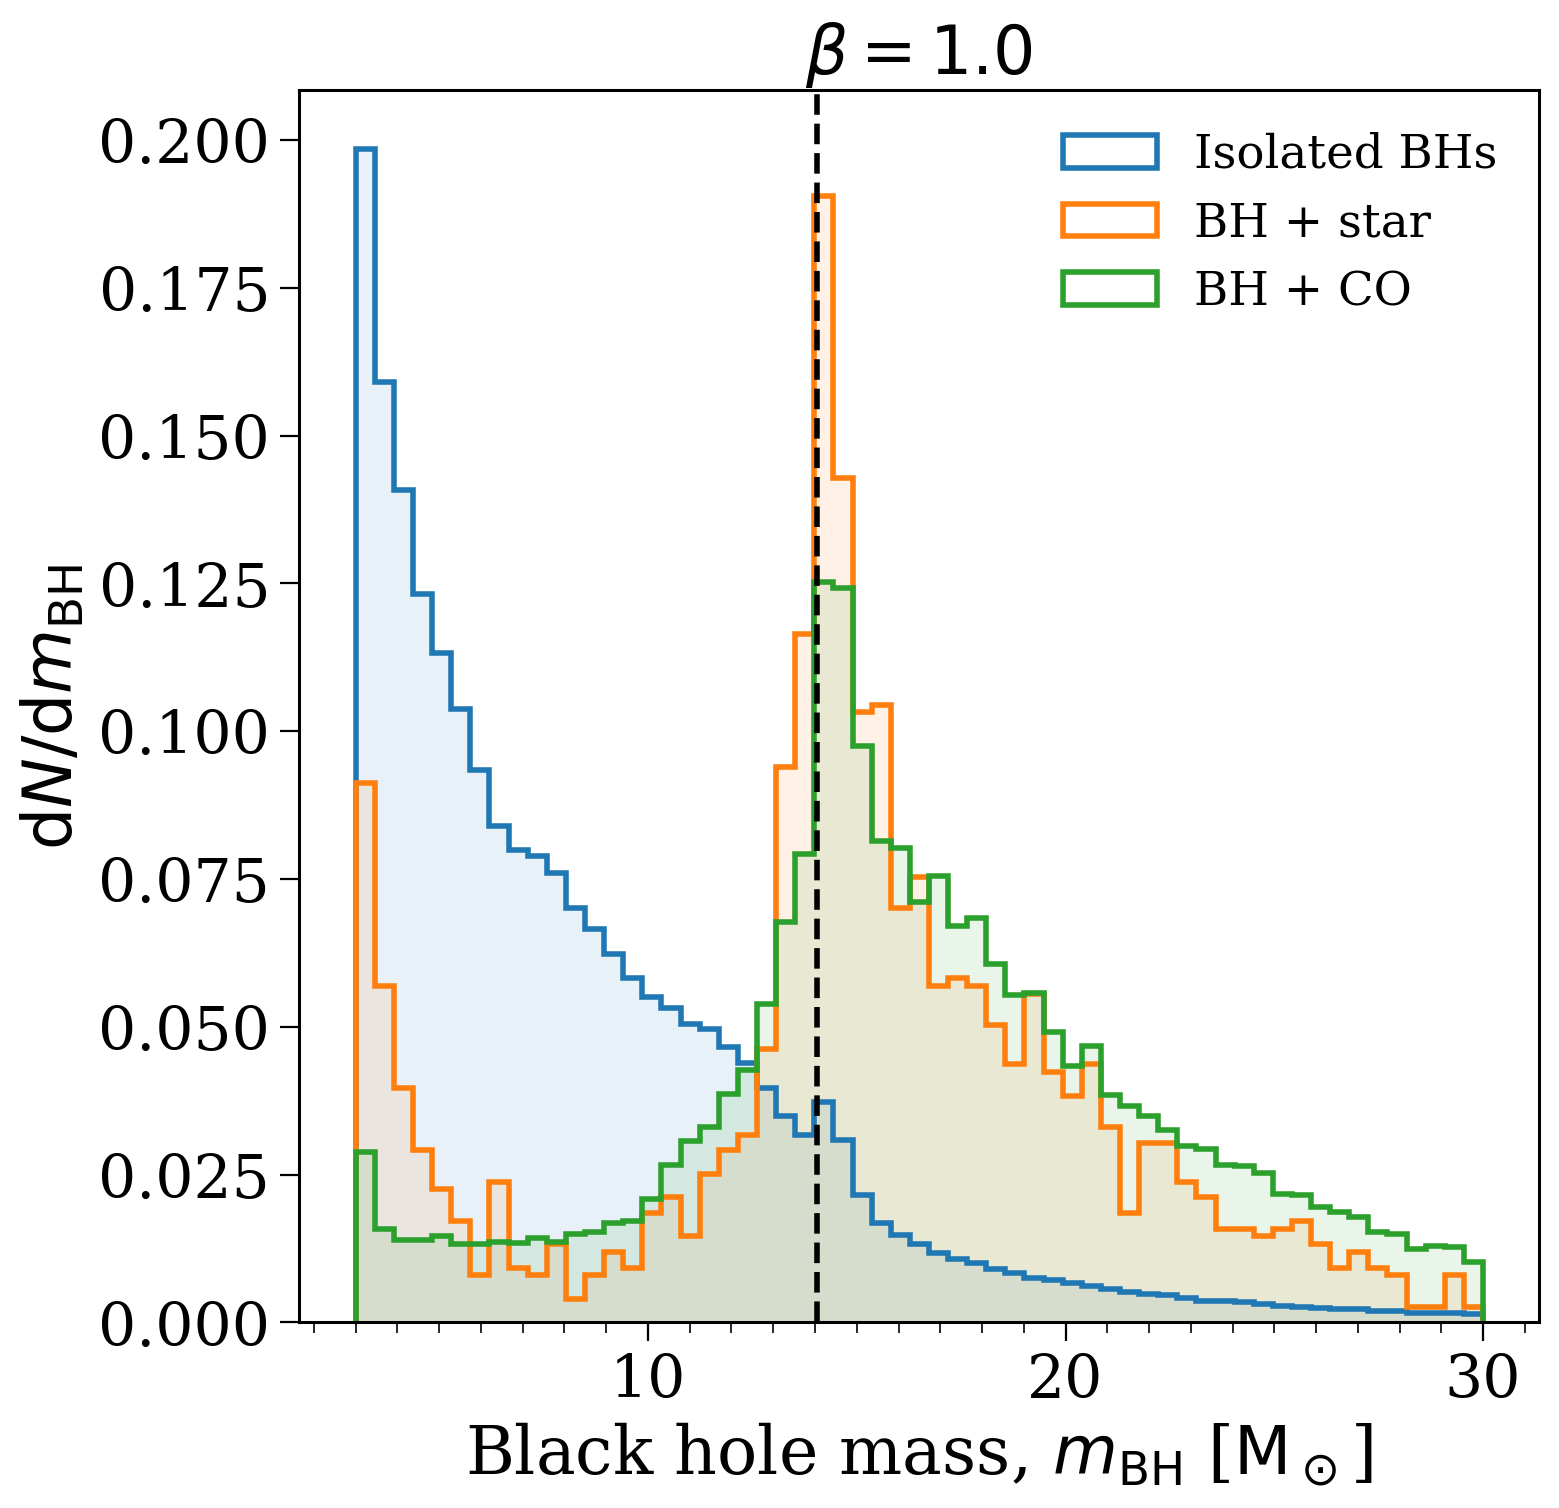

$\alpha_{\rm CE} = 0.1$ 1490


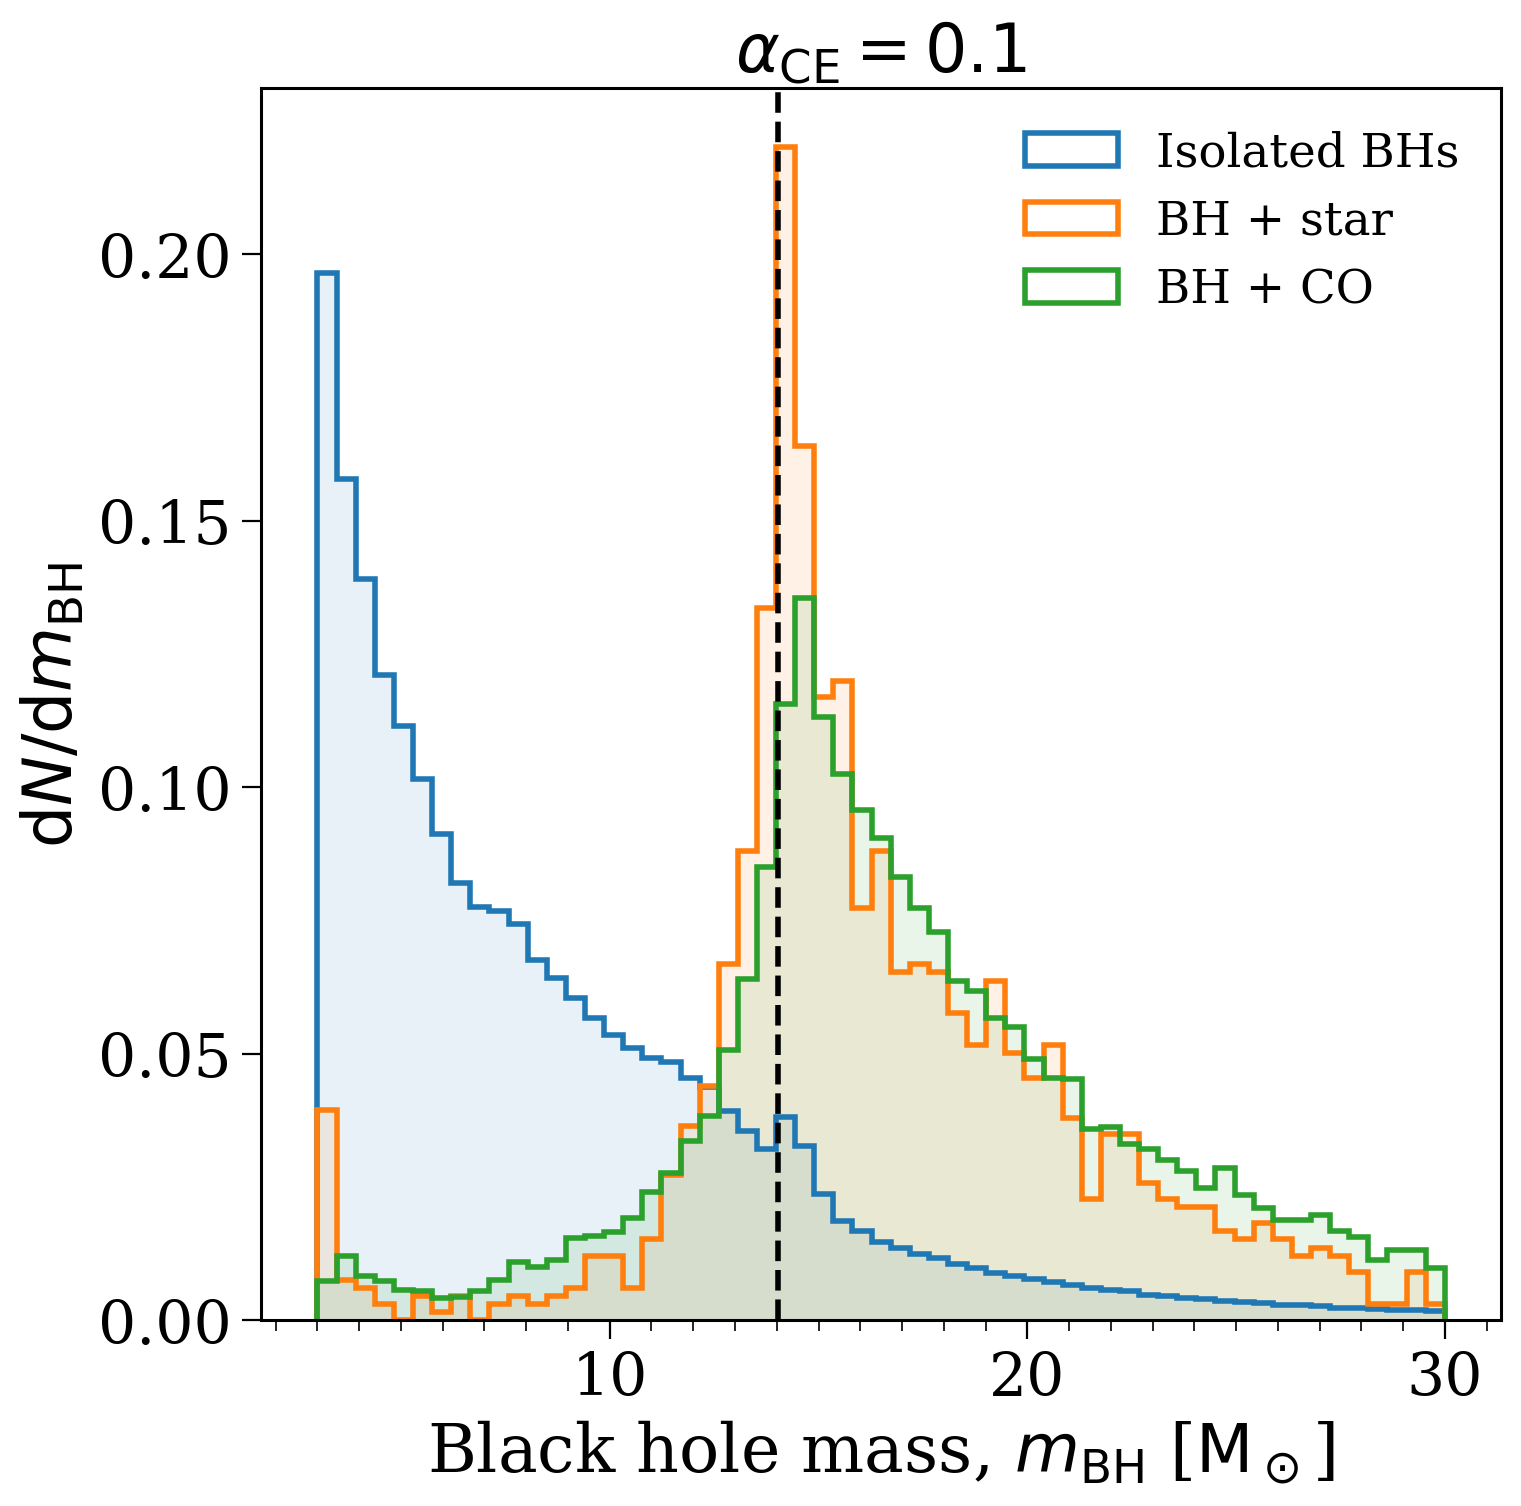

$\alpha_{\rm CE} = 0.5$ 1650


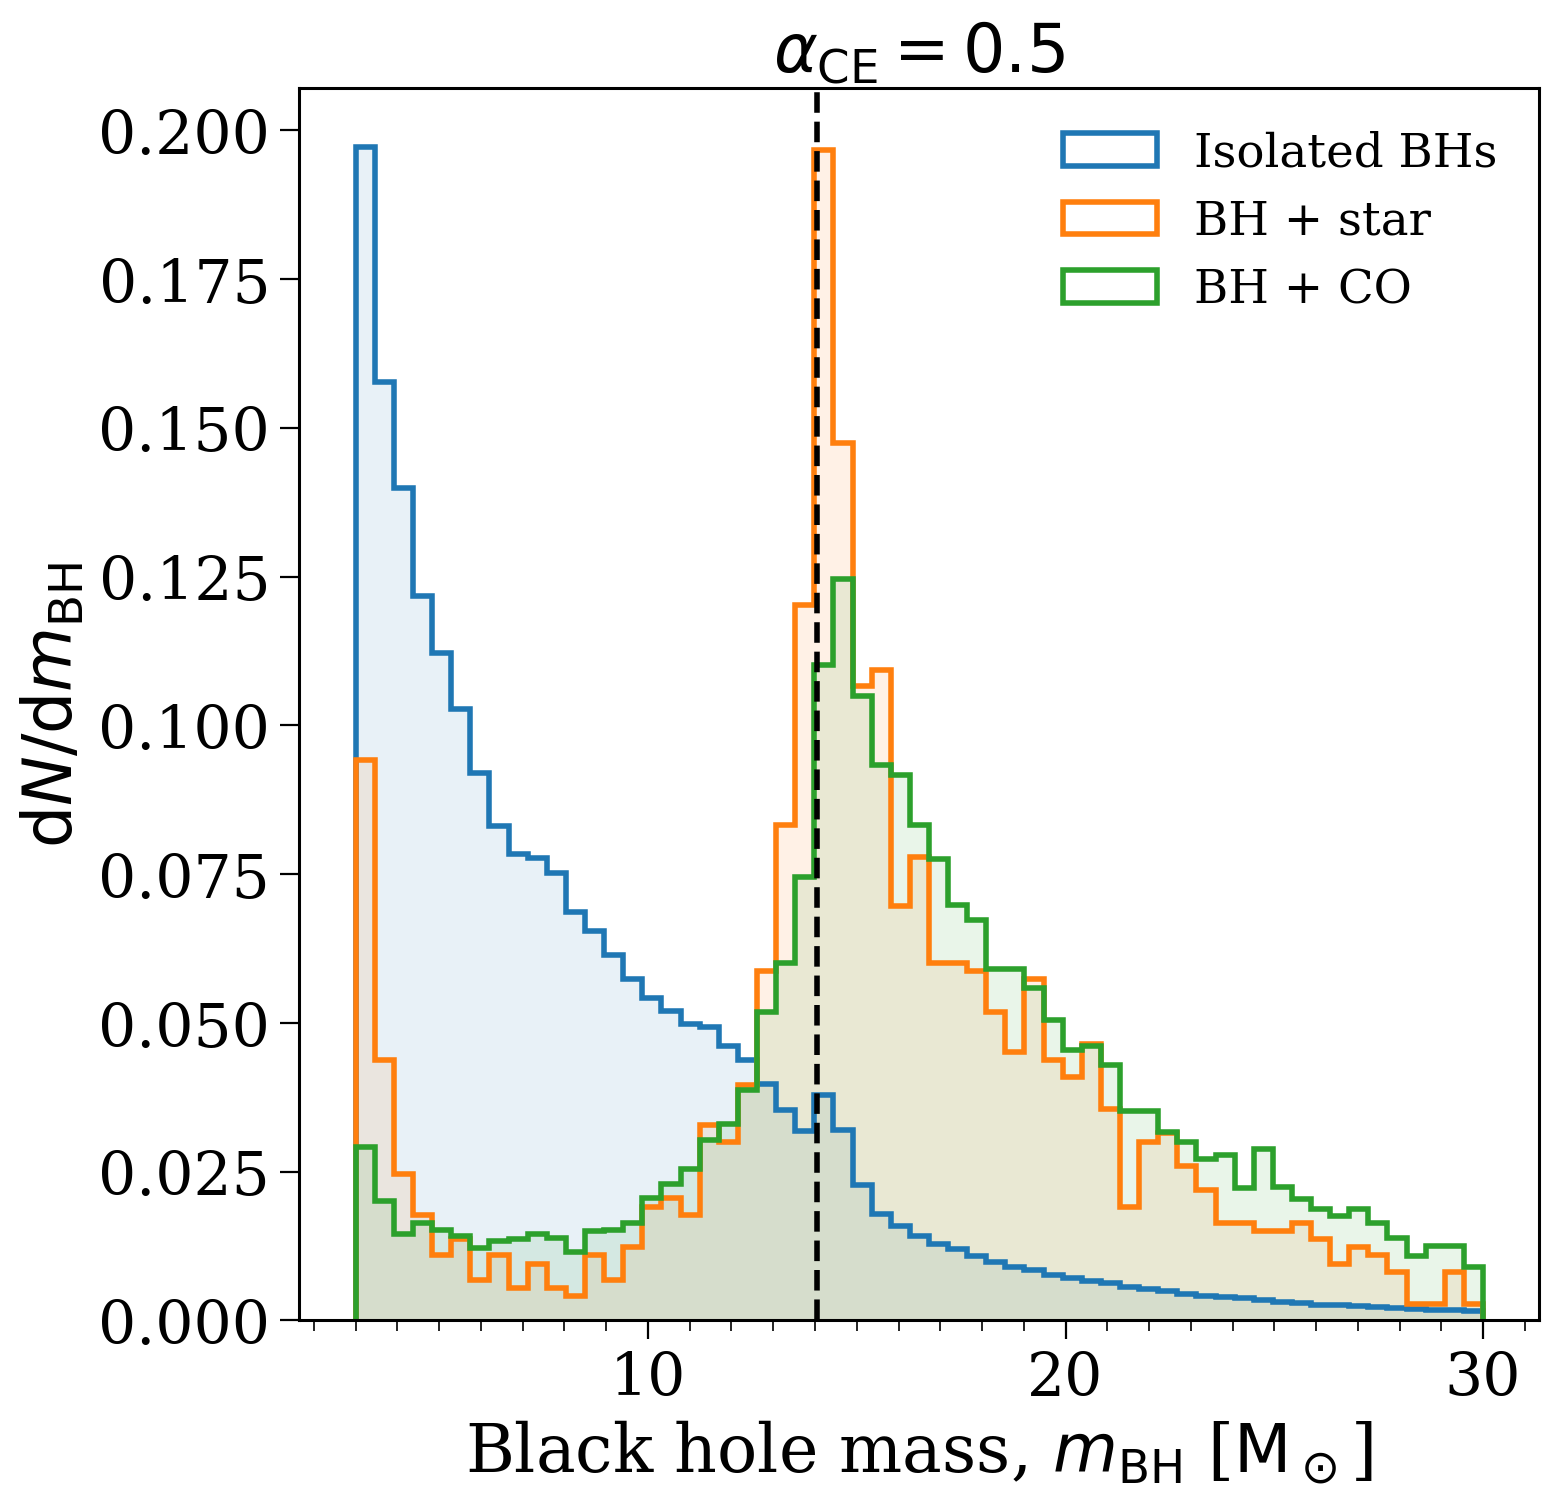

$\alpha_{\rm CE} = 2.0$ 1747


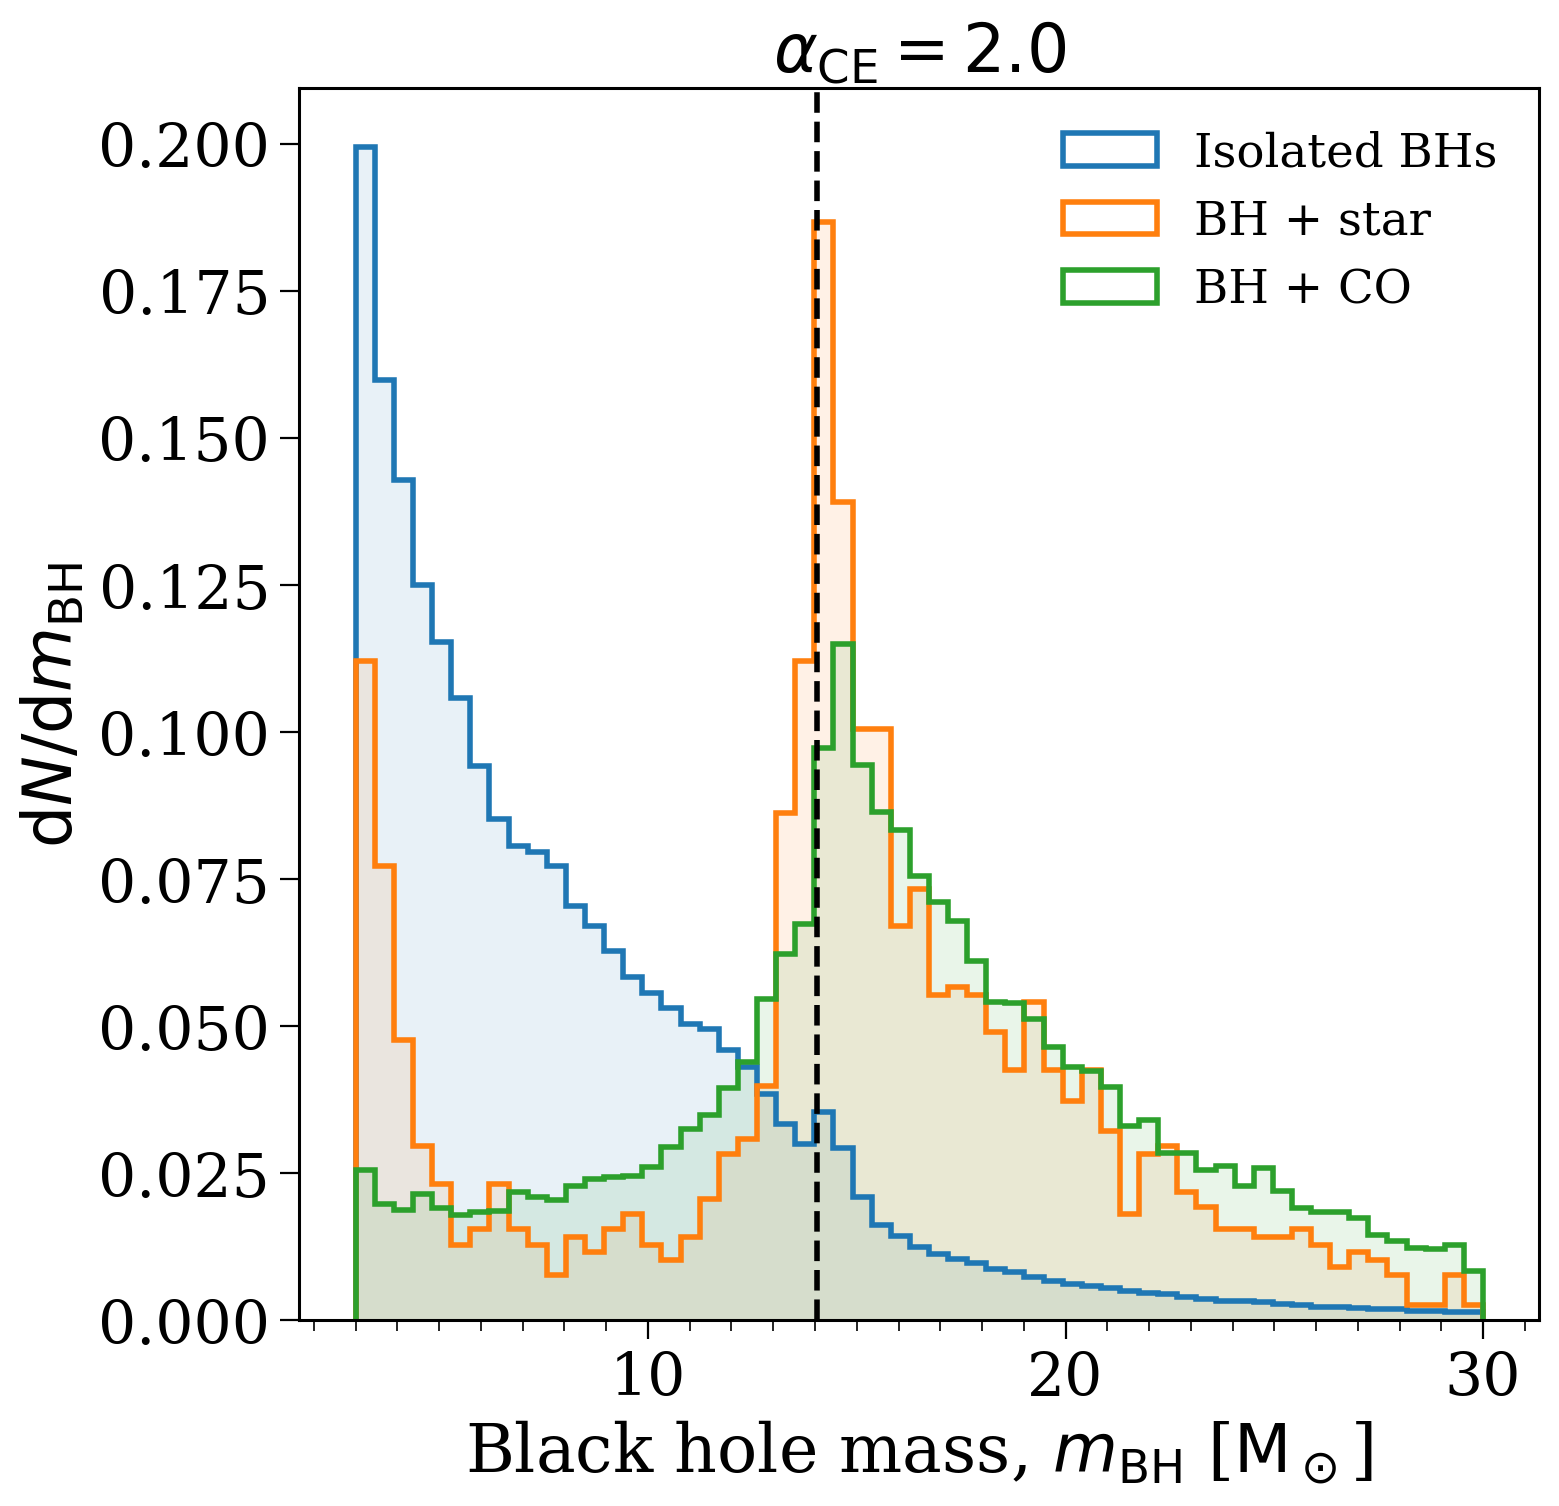

$\alpha_{\rm CE} = 10.0$ 2095


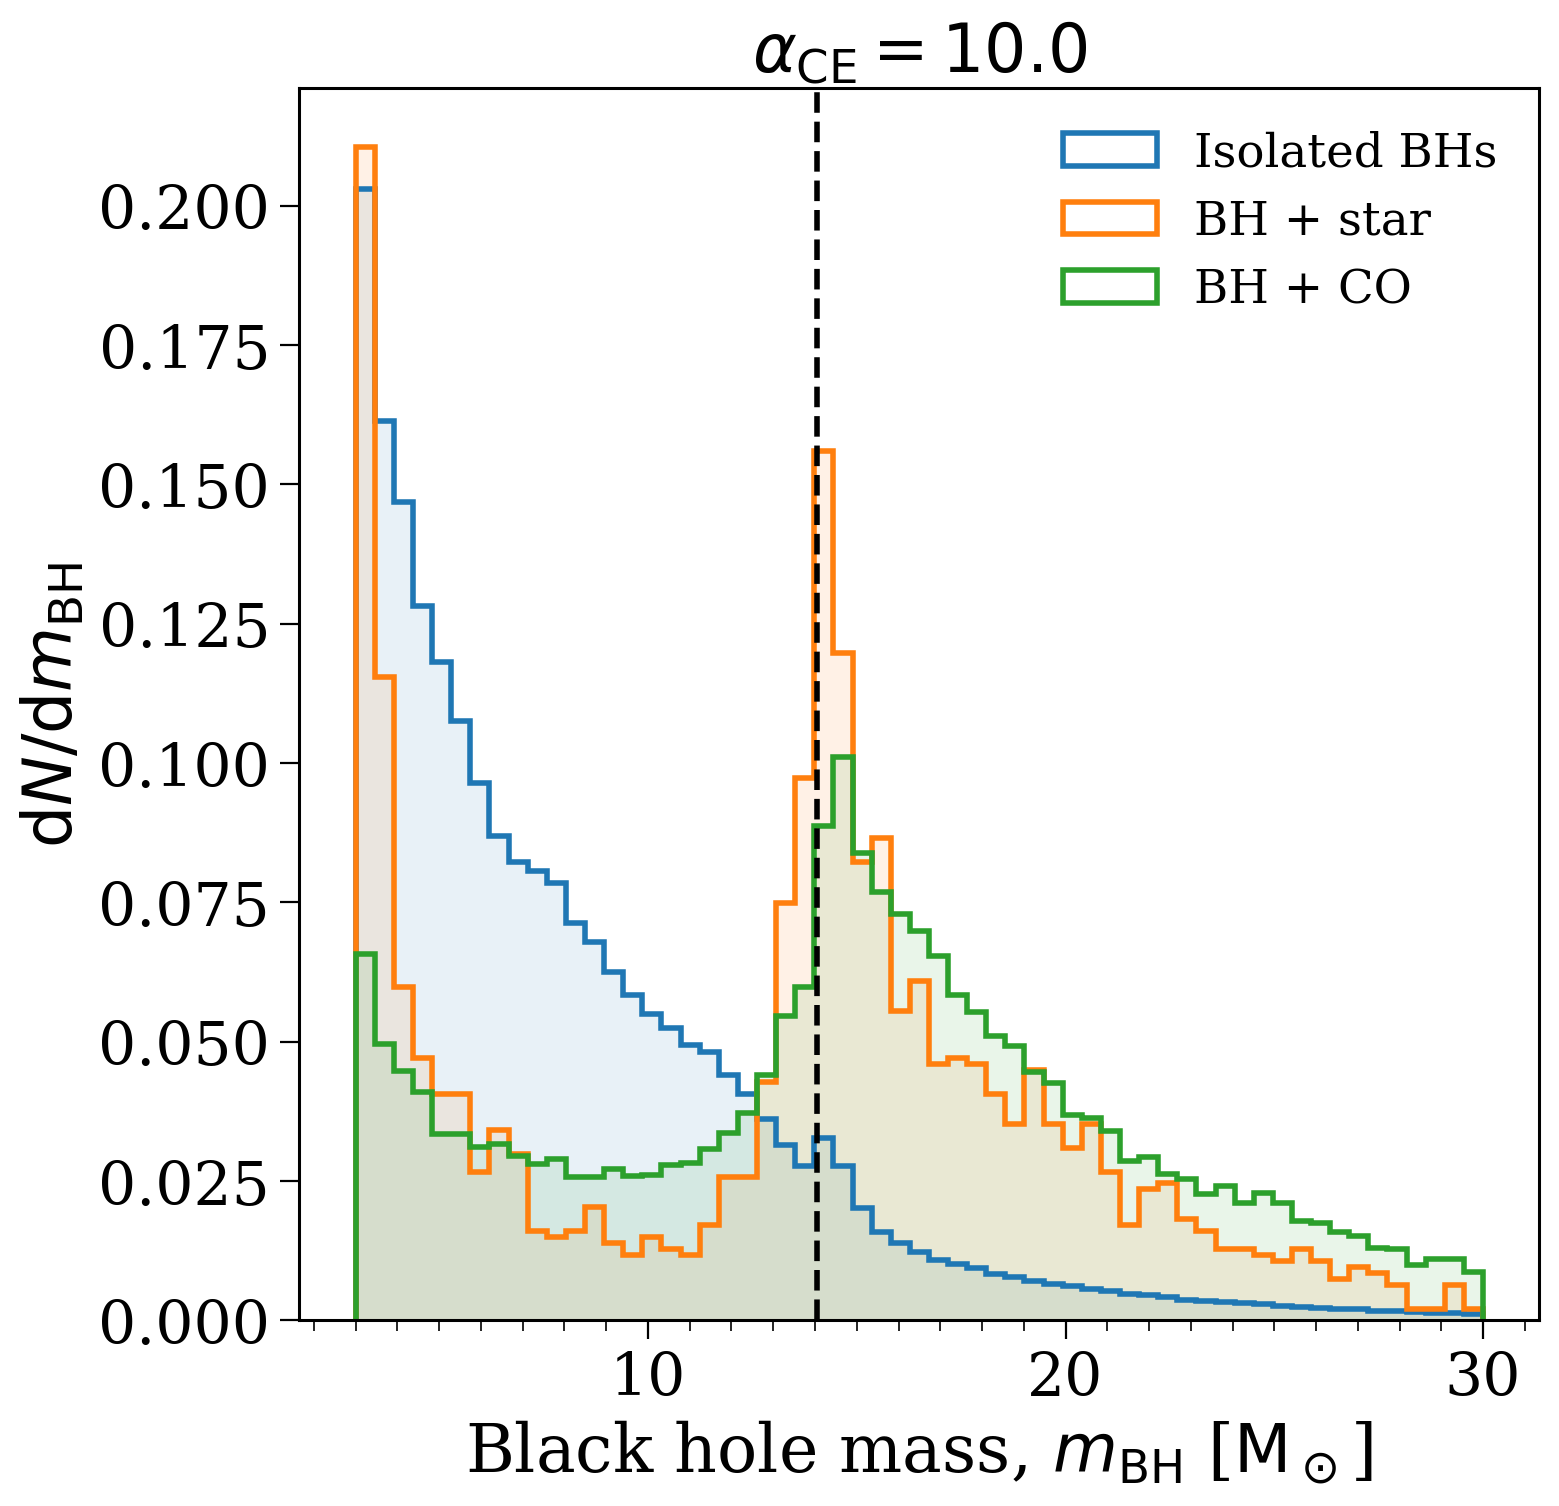

$q_{\rm crit, B} = 0$ 1694


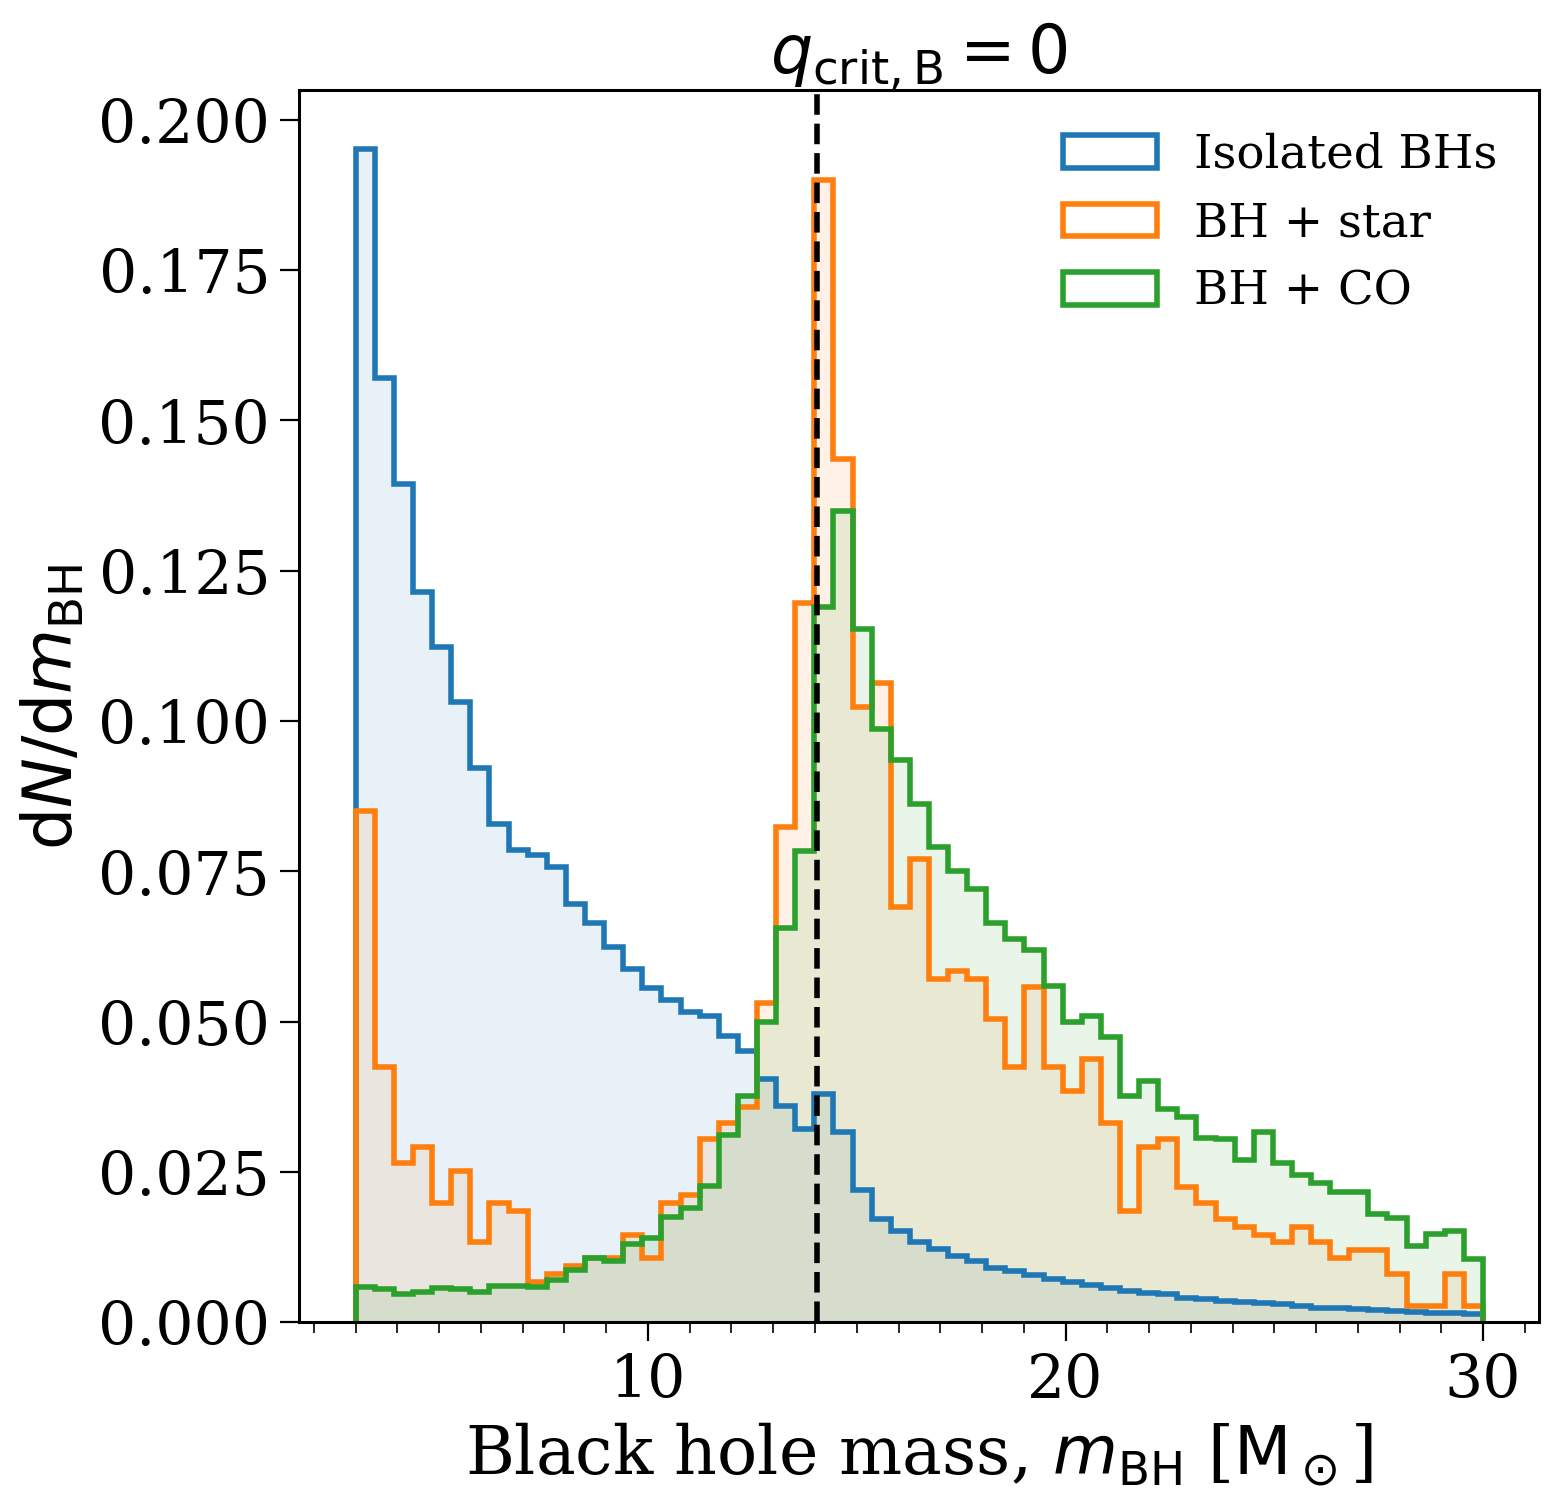

$q_{\rm crit, B} = \infty$ 1783


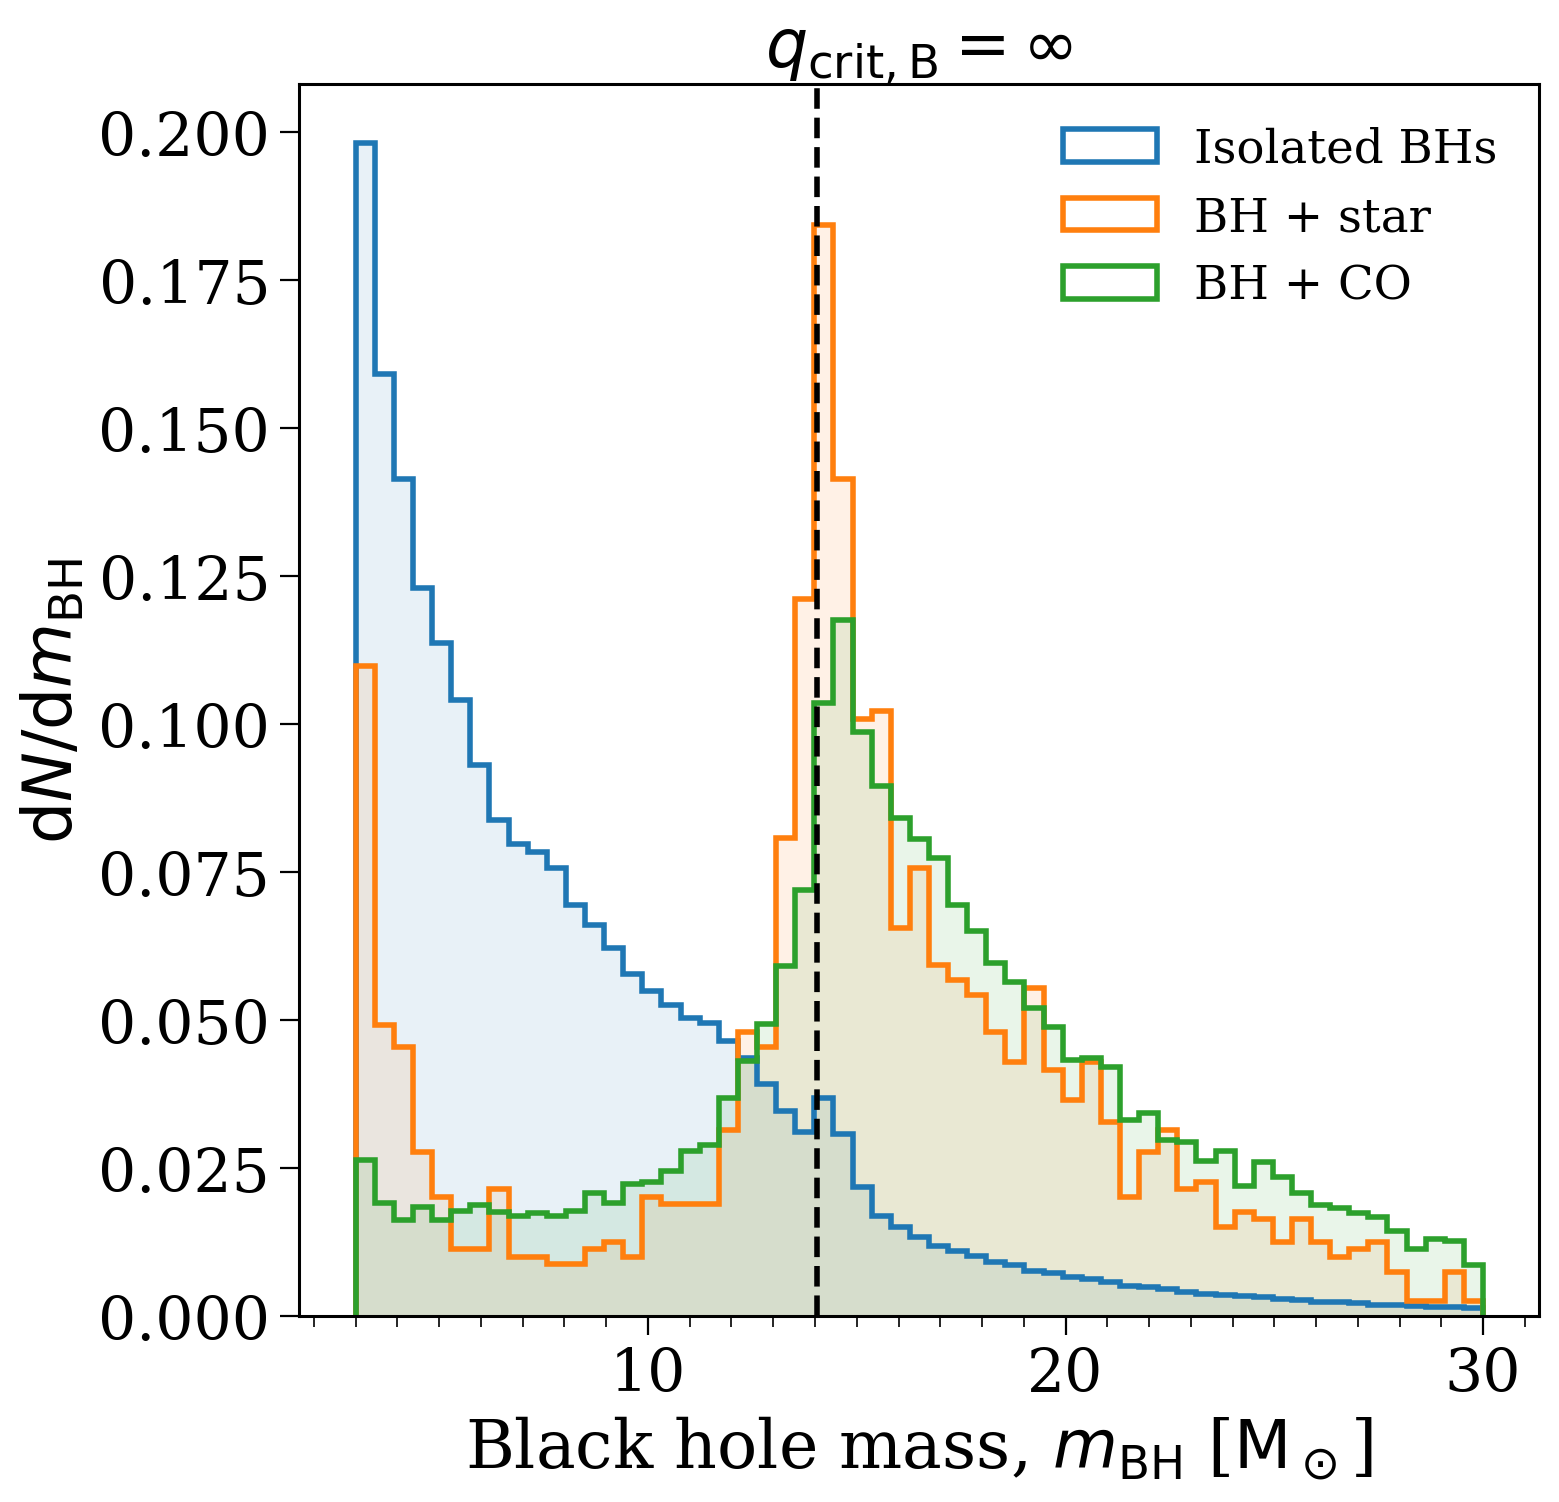

In [132]:
for pop_label in list(data.keys()):#['$f_{\\rm bin} = 1.0$', 'Fryer+2012 Rapid', 'Mandel\\&Muller2020', 'Maltsev+2025']:

    if pop_label == '$f_{\\rm bin} = 0.0$':
        continue

    fig, ax = plt.subplots(figsize=(8, 8))

    bins = np.linspace(3, 30, 60)
    density = True

    # pop_label = "Mandel\\&Muller2020"

    bh_bh = (data[pop_label]["sep"]["BH"] > 0) & (data[pop_label]["primary"]["BH"]) & (data[pop_label]["companion"]["BH"] == 14)
    bh_ns = (data[pop_label]["sep"]["BH"] > 0) & (data[pop_label]["companion"]["BH"] == 13)
    bh_wd = (data[pop_label]["sep"]["BH"] > 0) & (np.isin(data[pop_label]["companion"]["BH"], [10, 11, 12]))
    bh_star = (data[pop_label]["sep"]["BH"] > 0) & (data[pop_label]["companion"]["BH"] < 10)

    print(pop_label, bh_star.sum())

    for masses, colour, label in zip(
        [
            data[pop_label]["mass"]["BH"][data[pop_label]["sep"]["BH"] <= 0],
            data[pop_label]["mass"]["BH"][bh_star],
            data[pop_label]["mass"]["BH"][bh_bh | bh_ns | bh_wd],
        ],
        ['tab:blue', 'tab:orange', 'tab:green'],
        ["Isolated BHs","BH + star", "BH + CO"]
    ):
        plotting.nice_transparent_hist(
            ax, data=masses, bins=bins, colour=colour, alpha=0.1, label=label, density=density, lw=2
        )

        # ["Isolated BHs\n(Microlensing)","BH + star\n(Astrometry or XRBs)", "BH + compact object\n(Gravitational waves)"]

    ax.axvline(14.04, ls='--', c='k', lw=2)

    # ax.annotate("Minimum BH mass\nfor full fallback", xy=(12, 0.14), fontsize=0.6*fs, ha='center', va='center', rotation=90)

    ax.xaxis.set_major_locator(plt.MultipleLocator(10))
    ax.xaxis.set_minor_locator(plt.MultipleLocator(1))

    leg = ax.legend(fontsize=0.7*fs, frameon=False, loc='upper right')#, labelspacing=1.2)

    ax.set(
        xlabel=r"Black hole mass, $m_{\mathrm{BH}}$ [$\rm M_\odot$]",
        ylabel=r"${\rm d}N/{\rm d}m_{\mathrm{BH}}$",
    )

    ax.set_title(plot_labels[labels.index(pop_label)], fontsize=fs)

    # plt.savefig("../plots/bh_binary_masses.pdf", bbox_inches='tight', format='pdf')
    plt.show()

In [151]:
p = cogsworth.pop.load("/mnt/ceph/users/twagg/underworld/fiducial/fiducial_part5.h5")

cogsworth warning: file was saved with gala v1.11.1.dev61 but you are using v1.11.1.dev77


In [154]:
stats["scale_up"][0] * 64.4

np.float64(6184.670379105397)

In [ ]:
51 * p.

In [153]:
(51 + 75 + 65 + 65 + 66) / 5

64.4

In [152]:
p.bpp[((p.bpp["kstar_1"] == 14) & (p.bpp["kstar_2"] == 14) & (p.bpp["evol_type"] == 3))]

,tphys,mass_1,mass_2,kstar_1,kstar_2,sep,porb,ecc,evol_type,RRLO_1,RRLO_2,massc_he_layer_1,massc_co_layer_1,massc_he_layer_2,massc_co_layer_2,lum_1,lum_2,teff_1,teff_2,SN_1,SN_2,omega_spin_1,omega_spin_2,bin_num
545,8.284530,15.487169,8.637821,14,14,0.000153,4.446199e-08,0.0,3,1.000353,0.728218,0.0,0.0,0.000000,0.000000,1.000000e-10,1.000000e-10,2262.562899,3029.595027,1,1,1.464404e+11,200000000.0,545
14432,4909.823500,5.896607,5.350162,14,14,0.000064,1.762793e-08,0.0,3,1.010995,0.958984,0.0,0.0,0.000000,0.000000,1.000000e-10,1.000000e-10,3666.786211,3849.490045,1,1,5.154622e+08,200000000.0,14432
16962,223.089522,11.833398,4.075272,14,14,0.000106,3.170012e-08,0.0,3,1.000579,0.559403,0.0,0.0,0.000000,0.000000,1.000000e-10,1.000000e-10,2588.403336,4410.708952,1,1,8.386207e+10,200000000.0,16962
27077,6215.070669,11.389459,7.859080,14,14,0.000117,3.343073e-08,0.0,3,1.003266,0.820090,0.0,0.0,0.000000,0.000000,1.000000e-10,1.000000e-10,2638.366510,3176.148743,1,1,1.979735e+11,200000000.0,27077
32168,311.518232,12.598319,5.789966,14,14,0.000116,3.397840e-08,0.0,3,1.024725,0.671135,0.0,0.0,0.000000,0.000000,1.000000e-10,1.000000e-10,2508.594044,3700.400091,1,1,8.104788e+10,200000000.0,32168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295301,124.169724,24.665600,4.099591,14,14,0.000193,5.807963e-08,0.0,3,1.008335,0.376072,0.0,0.0,0.000000,0.000000,1.000000e-10,1.000000e-10,1792.837127,4397.607011,1,1,9.133015e+10,200000000.0,295301
299020,728.357057,24.679918,6.538806,14,14,0.000207,6.193044e-08,0.0,3,1.016856,0.491893,0.0,0.0,2.757324,7.847629,1.000000e-10,1.000000e-10,1792.317017,3482.069669,1,1,9.181985e+10,200000000.0,299020
304086,905.873370,11.794597,6.192660,14,14,0.000111,3.180528e-08,0.0,3,1.037451,0.730740,0.0,0.0,0.000000,0.000000,1.000000e-10,1.000000e-10,2592.657415,3578.063585,1,1,1.900566e+11,200000000.0,304086
309118,256.620950,11.529439,3.360169,14,14,0.000099,2.956332e-08,0.0,3,1.012507,0.516307,0.0,0.0,0.000000,0.000000,1.000000e-10,1.000000e-10,2622.301373,4857.425071,1,1,1.967099e+11,200000000.0,309118
